In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    # 윈도우 기본 굴림 폰트
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    # 맥(Mac) 기본 폰트 (애플고딕)
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    # 리눅스(Ubuntu 등) 환경에서 나눔고딕이 설치된 경우
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 04_ml — a_yt.ipynb 버그 수정본

## 수정 내역

| # | 위치 (a_yt.ipynb) | 문제 | 수정 |
|---|---|---|---|
| ① | 셀 22 / 68 | `overall_rank_ic`(날짜 무시 pooled Spearman)를 best 선정 기준으로 사용 → 시장 시계열 변동을 알파로 착각 | **`daily_ic` / `ic_ir` 기준으로 선정.** `overall_ic`는 진단용으로만 출력 |
| ② | 셀 56/59/60/62 | KMeans를 `[252+120]`로 fit → `[120+252]` 라벨로 centers 출력 → 그 해석으로 `risk_profile_dict` 작성 → 그 뒤 다시 fit | **컬럼 순서 1회 고정, centers에서 매핑을 자동 도출**, 실루엣으로 k 검증 |
| ③ | 셀 11 | `df['market_return'].rolling(w)`가 Ticker 정렬 행 순서에 걸려 티커 경계 오염 | **고유 날짜 기준 롤링 후 map** |
| ④ | 셀 105 | `best_xgb` 학습 후 LGBM importance를 출력 (복붙). `XGBRegressor(max_iter=)`는 없는 파라미터 | **XGB 자체 importance 산출**, 잘못된 파라미터 제거 |
| ⑤ | 셀 99 | 서치는 18개 피처, 최종 fit은 14개 | **동일 피처 사용** |
| ⑥ | 셀 18 | `df_test`를 만들고 한 번도 사용 안 함 | **최종 OOS 평가 + Q1~Q5 분위 포트폴리오 + 백테스트 추가** |
| ⑦ | 셀 90 | `add_cross_sectional_features`를 train에만 적용 | **train/test 모두 적용** |

## 런타임 설계
- 전처리 결과를 `data/processed/features.parquet`에 캐시 → 2회차부터 로드만
- 하이퍼파라미터 서치는 **날짜를 5일 간격으로 서브샘플링**해서 수행
  (타겟이 120일 중첩이라 인접 날짜는 거의 중복 정보. 통계적 손실 대비 속도 이득이 큼)
- 최종 학습·평가는 전체 데이터 사용

---

## 2차 수정 (⑩~⑰) — 2026-09-02

| # | 위치 | 문제 | 수정 |
|---|---|---|---|
| ⑩ | 셀 2 | `RAW_PATH`/`CACHE_PATH` 가 `data/` 를 가리켜 리포 레이아웃(`data/processed/`)에서 안 열림 | 둘 다 자동 탐색 |
| ⑪ | 셀 2·8·31 | `split_date = max_date - 2년` 하드코딩. 계획서(Test 2023-07~)를 무시해 리밸런싱이 4회뿐 | `SPLIT_DATE` 설정화(기본 2023-07-01) → 6회. 스윕의 `[:3]` 도 자동 계산 |
| ⑫ | 신규 셀·8·26·29·31·37·49 | **시점별 S&P500 자격 필터 미적용 (look-ahead 편향)** | `add_eligibility()` / `eval_universe()` 추가. 평가·백테스트 후보를 그날 실제 구성종목으로 제한 |
| ⑬ | 셀 2 | 계획서의 1차 필터링(안정성 군집)이 파이프라인에 연결된 적 없음 | `STABILITY_FILTER` 스위치 추가 (기본 None) |
| ⑭ | 셀 62 | `exit_date`(2026-07-01)가 데이터 끝(2026-06-30)을 넘어 497종목 전부 "가격 누락" | 청산일이 존재하는 최신 신호일로 자동 조정 |
| ⑮ | 셀 61·63~68 | `model_diagnostics.py` 가 리포에 없음 (커밋된 적 없음). 9장 전체가 실행 불가 | `try/except` + `HAS_DIAG` 가드. `sp500_universe.csv` 경로도 수정 |
| ⑯ | 셀 13 | 실루엣 최고가 k=2(0.483)인데 K=4 고정 — 계획서 "4분면 구조"의 근거 없음 | 값은 유지하되 근거를 출력. 계획서 [시나리오 B] 판단 근거로 사용 |
| ⑰ | 셀 29 | `backtest()` 에서 `top_q` 만 `expm1`(단리), `bottom_q`/`equal_weight` 는 로그수익률 평균 → 단위 혼용으로 top 이 부풀려짐 | 전부 단리로 통일. 기간 누적도 합산 → 복리 연결 |

### ⑫ 가 왜 중요한가

`final_df` 는 "기간 중 한 번이라도 S&P500 구성종목이었던" 티커를 모두 담는다
(`get_historical_sp500_universe()`, 생존편향 보정용). `02_preprocessing.ipynb` 은
**각 리밸런싱 날짜의 후보군에 `filter_by_membership()` 을 반드시 적용하라**고 명시하지만,
이 노트북에는 그 호출이 없었다.

기존 실행의 수익 기여 상위 종목과 실제 편입일 (리밸런싱: 2024-07-01 / 2024-12-19 / 2025-06-16 / 2025-12-05):

| 종목 | 기여 | 편입일 | 자격 있던 리밸런싱 |
|---|---|---|---|
| LITE | **1위** | 2026-03-23 | **0회** |
| CIEN | 4위 | 2026-02-09 | **0회** |
| ECHO | 5위 | 2026-06-24 | **0회** |
| FIX | 8위 | 2025-12-22 | **0회** |
| APP | 6위 | 2025-09-22 | 1회 |
| PLTR | 7위 | 2024-09-23 | 3회 |

후보 576개 중 각 리밸런싱 시점마다 약 107개(18.6%)가 그날 구성종목이 아니었다.
지수 편입 종목은 대체로 **직전에 크게 오른 종목**이고 이 모델이 학습한 신호는 12개월 모멘텀이라,
"앞으로 편입될 종목"을 미리 담는 구조가 된다. `8-9. [검증]` 셀이 이 크기를 A/B 로 측정한다.

### 실행 순서
1. 셀 2 에서 `SPLIT_DATE`, `APPLY_MEMBERSHIP_EVAL`, `STABILITY_FILTER` 확인
2. **캐시는 지우지 않아도 된다.** `eligible` 컬럼은 캐시 로드 *이후*에 붙고 피처 계산식은 그대로다.
   (`final_df.parquet` 을 새로 만들었을 때만 `features.parquet` 을 지운다)
3. Run All — 첫 셀부터 순서대로


In [ ]:
import os, gc, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, norm
from sklearn.base import clone, BaseEstimator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import BaseCrossValidator, ParameterSampler
import lightgbm as lgb

warnings.filterwarnings("ignore")

from pathlib import Path

# ---------------- 프로젝트 루트 (실행 위치 무관) ----------------
def _find_root():
    here = Path.cwd().resolve()
    for c in [here, *here.parents]:
        if (c / "data").is_dir() and (c / "notebooks").is_dir():
            return c
    return here

PROJECT_ROOT = _find_root()

# ---------------- 수정 ⑳ : src/ 를 import 경로에 ----------------
# model_diagnostics.py 는 notebooks/ 가 아니라 src/ 에 있다.
import sys
for _p in (PROJECT_ROOT / "src", PROJECT_ROOT / "notebooks"):
    if _p.is_dir() and str(_p) not in sys.path:
        sys.path.insert(0, str(_p))


# ---------------- parquet 엔진 자동 감지 ----------------
def _pq_engine():
    for name in ("pyarrow", "fastparquet"):
        try:
            __import__(name); return name
        except ImportError:
            continue
    raise ImportError("pyarrow 또는 fastparquet 중 하나가 필요합니다: pip install pyarrow")

PARQUET_ENGINE = _pq_engine()

# ---------------- 설정 ----------------
WINDOWS       = [20, 60, 120, 252]
TRADING_DAYS  = 252
# 수정 ⑩ : 리포 레이아웃(data/processed/)과 구버전(data/) 모두 지원
def _pick(*cands):
    for c in cands:
        if c.exists():
            return c
    return cands[0]

RAW_PATH      = _pick(PROJECT_ROOT / "data/processed/final_df.parquet",
                      PROJECT_ROOT / "data/final_df.parquet")
CACHE_PATH    = _pick(PROJECT_ROOT / "data/processed/features.parquet",
                      PROJECT_ROOT / "data/features.parquet")
OUT_DIR       = PROJECT_ROOT / "outputs"
TARGET        = "target_ret_120d"
HORIZON       = 120
MAX_SPAN_DAYS = 200   # shift(-120) 이 달력 200일을 넘으면 데이터 구멍으로 보고 제외

DATE_STRIDE   = 5      # 서치용 날짜 서브샘플 간격 (1 = 전체)
N_ITER        = 20     # RandomizedSearch 시도 횟수
N_SPLITS      = 5
PURGE         = 120    # 타겟 horizon 과 동일해야 함
SELECT_BY     = "daily_ic"   # 수정 ①  ('daily_ic' 또는 'ic_ir')

RUN_XGB       = True
RUN_CAT       = True
RUN_MLP       = False  # sklearn MLP 는 매우 느림. 시간 남을 때만 True

RANDOM_STATE  = 42
COST_BPS      = 10     # 백테스트 왕복 거래비용 (bp)

# ============================================================
# 수정 ⑪~⑬ 설정
# ============================================================
# ⑪ Train/Test 분할일. 계획서 기준은 2023-07-01.
#    None 이면 기존 동작(데이터 끝에서 2년)을 유지한다.
SPLIT_DATE = pd.Timestamp("2023-07-01")

# ⑫ 시점별 S&P500 자격(point-in-time membership) 필터  ★ 중요
#    final_df 에는 "분석기간 중 한 번이라도 구성종목이었던" 티커가 모두 들어있다.
#    각 리밸런싱 날짜의 후보는 '그날 실제 구성종목'이어야 한다.
#    (02_preprocessing.ipynb 이 명시적으로 요구하는 절차 / src/get_tickers.py 참조)
MEMBERSHIP_PATH        = PROJECT_ROOT / "data/raw/cache/sp500_membership_history.csv"
APPLY_MEMBERSHIP_EVAL  = True    # 평가·백테스트 후보를 그날 구성종목으로 제한
APPLY_MEMBERSHIP_TRAIN = False   # 학습셋에도 적용할지. False면 '평가 유니버스만' 바뀌어 A/B가 깨끗하다

# ⑬ 계획서 1차 필터링(안정성 군집) 재현용 스위치.
#    None = 미적용(기존과 동일). 예: ["Stable"], ["Stable", "Moderate"]
STABILITY_FILTER = None

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"parquet engine : {PARQUET_ENGINE}")
print(f"설정 완료 | 선정기준={SELECT_BY} | 날짜간격={DATE_STRIDE} | purge={PURGE}")

PROJECT_ROOT   : /Users/genie/Documents/GitHub/stock-to-rich-Mid-project
parquet engine : pyarrow
설정 완료 | 선정기준=daily_ic | 날짜간격=5 | purge=120


---
## 1-0. 시점별 자격 필터 (수정 ⑫)

`final_df` 는 "기간 중 한 번이라도 S&P500 구성종목이었던" 티커를 모두 담고 있습니다.
각 리밸런싱 날짜의 후보는 **그날 실제 구성종목**이어야 하는데, 기존 노트북에는 이 필터가 없었습니다.
그 결과 예컨대 2026-03 편입된 LITE 가 2024-07 리밸런싱 후보에 들어가 수익 기여 1위가 됩니다 (look-ahead 편향).


In [3]:
# ============================================================
# 수정 ⑫ : 시점별 S&P500 자격 판정 유틸
# ============================================================
# src/get_tickers.py 의 filter_by_membership() 과 같은 규칙을 쓰되,
# 네트워크를 타지 않도록 캐시 CSV 만 직접 읽는다.
#   자격 조건 : start_date <= Date  AND  (end_date 없음 OR Date <= end_date)
#   한 종목이 여러 번 편입/편출될 수 있으므로 구간 중 하나라도 맞으면 자격 인정.

def load_membership(path=MEMBERSHIP_PATH):
    if not Path(path).exists():
        raise FileNotFoundError(
            f"편입/편출 이력이 없습니다: {path}\n"
            "src/get_tickers.py 의 _load_membership_history() 를 한 번 실행해 캐시를 만드세요."
        )
    m = pd.read_csv(path)
    m["start_date"] = pd.to_datetime(m["start_date"], errors="coerce")
    m["end_date"]   = pd.to_datetime(m["end_date"],   errors="coerce")
    return m.dropna(subset=["ticker", "start_date"])


def add_eligibility(df, membership=None, ticker_col="Ticker", date_col="Date"):
    """df 에 'eligible' 불리언 컬럼을 붙인다 (그 날짜에 실제 S&P500 구성종목이었는가)."""
    m = load_membership() if membership is None else membership
    m = m[m["ticker"].isin(df[ticker_col].unique())]

    out   = np.zeros(len(df), dtype=bool)
    dates = df[date_col].to_numpy(dtype="datetime64[ns]")
    idx_by_ticker = df.groupby(ticker_col).indices

    for tkr, g in m.groupby("ticker"):
        idx = idx_by_ticker.get(tkr)
        if idx is None:
            continue
        d = dates[idx]
        for s, e in zip(g["start_date"], g["end_date"]):
            ok = d >= np.datetime64(s)
            if pd.notna(e):
                ok &= d <= np.datetime64(e)
            out[idx] |= ok

    # 1M행 프레임을 통째로 복사하면 메모리가 두 배로 뛰므로 컬럼만 붙인다
    df["eligible"] = out
    return df


def eval_universe(df, verbose=False):
    """평가/백테스트에 쓸 후보군. 자격 필터 + (선택) 안정성 군집 필터."""
    d = df
    if APPLY_MEMBERSHIP_EVAL and "eligible" in d.columns:
        n0 = len(d)
        d = d[d["eligible"]]
        if verbose:
            print(f"  [자격필터] {n0:,} -> {len(d):,}행 ({(n0-len(d))/max(1,n0)*100:.1f}% 제외)")
    if STABILITY_FILTER and "Risk_Profile" in d.columns:
        n0 = len(d)
        d = d[d["Risk_Profile"].isin(STABILITY_FILTER)]
        if verbose:
            print(f"  [안정성필터 {STABILITY_FILTER}] {n0:,} -> {len(d):,}행")
    return d.copy()

print("자격 필터 유틸 준비 완료 |",
      f"평가적용={APPLY_MEMBERSHIP_EVAL} 학습적용={APPLY_MEMBERSHIP_TRAIN} 안정성필터={STABILITY_FILTER}")


자격 필터 유틸 준비 완료 | 평가적용=True 학습적용=False 안정성필터=None


---
# 1. 전처리 (캐시)

**수정 ③** 포함. 한 번 돌리면 `features.parquet` 에 저장되고 이후엔 로드만 합니다.

In [4]:
def build_features(path=RAW_PATH):
    t0 = time.time()
    df = pd.read_parquet(path, engine=PARQUET_ENGINE).loc[:, :"Volume"]
    d = df.copy()

    d["log_return"] = d.groupby("Ticker")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    mkt = d.groupby("Date")["log_return"].mean().rename("market_return").reset_index()
    d = d.merge(mkt, on="Date", how="left")
    d = d.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    d["downside_ret"] = np.where(d["log_return"] < 0, d["log_return"], 0.0)

    # 날짜 기준 시장 시계열 (수정 ③ 의 근거가 되는 테이블)
    market_daily = (d[["Date", "market_return"]].drop_duplicates("Date")
                      .sort_values("Date").set_index("Date"))

    g_close = d.groupby("Ticker")["Close"]
    g_ret   = d.groupby("Ticker")["log_return"]

    # ---------- 안정성 지표 ----------
    for w in WINDOWS:
        print(f"  [안정성 {w}d]")
        d[f"vol_ann_{w}d"] = (g_ret.rolling(w, min_periods=w).std()
                              .reset_index(drop=True) * np.sqrt(TRADING_DAYS)).astype("float32")

        peak = g_close.rolling(w, min_periods=w).max().reset_index(drop=True)
        dd   = (d["Close"] - peak) / peak
        d[f"mdd_{w}d"] = (dd.groupby(d["Ticker"]).rolling(w, min_periods=w)
                          .min().reset_index(drop=True)).astype("float32")

        dvar = ((d["downside_ret"] ** 2).groupby(d["Ticker"])
                .rolling(w, min_periods=w).mean().reset_index(drop=True))
        d[f"downside_vol_{w}d"] = (np.sqrt(dvar) * np.sqrt(TRADING_DAYS)).astype("float32")

        cov = (d.groupby("Ticker")
               .apply(lambda x: x["log_return"].rolling(w, min_periods=w).cov(x["market_return"]),
                      include_groups=False)
               .reset_index(level=0, drop=True))
        mvar = market_daily["market_return"].rolling(w, min_periods=w).var()
        d[f"beta_{w}d"] = (cov / d["Date"].map(mvar)).astype("float32")

    # ---------- 수익성 지표 ----------
    d["price_diff"] = d.groupby("Ticker")["Close"].diff()
    d["gain"] = np.where(d["price_diff"] > 0,  d["price_diff"], 0.0)
    d["loss"] = np.where(d["price_diff"] < 0, -d["price_diff"], 0.0)
    g_gain, g_loss = d.groupby("Ticker")["gain"], d.groupby("Ticker")["loss"]

    for w in WINDOWS:
        print(f"  [수익성 {w}d]")
        sma = g_close.rolling(w, min_periods=w).mean().reset_index(drop=True)
        d[f"ma_gap_{w}d"] = ((d["Close"] - sma) / sma).astype("float32")

        sh = g_close.shift(w)
        d[f"momentum_{w}d"] = ((d["Close"] - sh) / sh).astype("float32")

        stock_mom = d.groupby("Ticker")["log_return"].transform(
            lambda x: x.rolling(w, min_periods=w).sum())

        # ===== 수정 ③ =====
        # (before) d["market_return"].rolling(w).sum()
        #          -> Ticker 로 정렬된 '행 순서'에 롤링이 걸려 티커 경계에서 이전 티커 꼬리가 섞임
        # (after)  고유 날짜 기준으로 롤링한 뒤 Date 로 map
        mkt_mom = market_daily["market_return"].rolling(w, min_periods=w).sum()
        d[f"relative_momentum_{w}d"] = (stock_mom - d["Date"].map(mkt_mom)).astype("float32")

    for w in [14, 28, 56]:
        ag = g_gain.rolling(w, min_periods=w).mean().reset_index(drop=True)
        al = g_loss.rolling(w, min_periods=w).mean().reset_index(drop=True)
        d[f"rsi_{w}d"] = (100.0 - 100.0 / (1.0 + ag / (al + 1e-9))).astype("float32")

    d["Date"] = pd.to_datetime(d["Date"])
    d = d.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    # ---------- 주간 RSI (look-ahead 방지 shift(1) 유지) ----------
    def weekly_rsi(g, window=14):
        g  = g.sort_values("Date").copy()
        wc = g.set_index("Date")["Close"].resample("W-FRI").last().dropna()
        delta = wc.diff()
        ag = delta.clip(lower=0).rolling(window, min_periods=window).mean()
        al = (-delta.clip(upper=0)).rolling(window, min_periods=window).mean()
        wr = (100 - 100 / (1 + ag / (al + 1e-9))).shift(1)
        wd = wr.rename("rsi_14w").reset_index()
        out = pd.merge_asof(g[["Date"]].sort_values("Date"), wd.sort_values("Date"),
                            on="Date", direction="backward")
        out.index = g.index
        return out["rsi_14w"]

    print("  [주간 RSI]")
    d["rsi_14w"] = (d.groupby("Ticker", group_keys=False)
                    .apply(weekly_rsi, include_groups=False).astype("float32"))

    d.drop(columns=["downside_ret", "price_diff", "gain", "loss"], inplace=True)

    # ---------- 인접 윈도우 차분 ----------
    for p in ["momentum", "relative_momentum"]:
        d[f"{p}_diff_short"] = d[f"{p}_20d"]  - d[f"{p}_60d"]
        d[f"{p}_diff_mid"]   = d[f"{p}_60d"]  - d[f"{p}_120d"]
        d[f"{p}_diff_long"]  = d[f"{p}_120d"] - d[f"{p}_252d"]

    d = d.dropna().reset_index(drop=True)

    # ---------- 타겟 ----------
    # shift(-t) 는 '행' 기준이라 데이터에 구멍이 있으면 t 거래일이 아니다.
    # 그래서 타겟이 실제로 언제 확정되는지(종료일)를 같이 기록한다.
    for t in [60, 120, 252]:
        d[f"target_ret_{t}d"] = d.groupby("Ticker")["Close"].transform(
            lambda x: np.log(x.shift(-t) / x)).astype("float32")
        d[f"target_end_{t}d"] = d.groupby("Ticker")["Date"].shift(-t)

    print(f"전처리 완료 {d.shape} | {time.time()-t0:.0f}초")
    return d


if os.path.exists(CACHE_PATH):
    print("캐시 로드:", CACHE_PATH)
    df_all = pd.read_parquet(CACHE_PATH, engine=PARQUET_ENGINE)
else:
    df_all = build_features()
    df_all.to_parquet(CACHE_PATH, engine=PARQUET_ENGINE, index=False)
    print("캐시 저장:", CACHE_PATH)

df_all["Date"] = pd.to_datetime(df_all["Date"])
raw_df = df_all.copy()
# ============================================================
# 구버전 캐시 보정 — 재전처리 없이 타겟 종료일 컬럼만 추가
# ============================================================
df_all = df_all.sort_values(["Ticker", "Date"]).reset_index(drop=True)
for t in [60, 120, 252]:
    if f"target_end_{t}d" not in df_all.columns:
        df_all[f"target_end_{t}d"] = df_all.groupby("Ticker")["Date"].shift(-t)
        print(f"  target_end_{t}d 추가 (캐시 보정)")

# 타겟이 실제로 달력 며칠 뒤에 확정되는지
df_all["target_span_days"] = (
    df_all[f"target_end_{HORIZON}d"] - df_all["Date"]
).dt.days

print(df_all.shape)
df_all.head(3)

캐시 로드: /Users/genie/Documents/GitHub/stock-to-rich-Mid-project/data/processed/features.parquet
  target_end_60d 추가 (캐시 보정)
  target_end_120d 추가 (캐시 보정)
  target_end_252d 추가 (캐시 보정)
(1321093, 54)


,Date,Ticker,Open,High,Low,Close,Volume,log_return,market_return,vol_ann_20d,...,relative_momentum_diff_short,relative_momentum_diff_mid,relative_momentum_diff_long,target_ret_60d,target_ret_120d,target_ret_252d,target_end_60d,target_end_120d,target_end_252d,target_span_days
0,2017-12-29,A,63.307028,63.382060,62.772436,62.809952,1064900,-0.004930,-0.005057,0.164403,...,-0.008170,-0.049453,-0.190528,-0.008548,-0.062219,-0.010072,2018-03-28,2018-06-22,2019-01-02,175.0
1,2018-01-02,A,63.231991,63.672797,63.156959,63.400810,1047800,0.009363,0.008032,0.166925,...,-0.008076,-0.035912,-0.196240,-0.010409,-0.097231,-0.056970,2018-03-29,2018-06-25,2019-01-03,174.0
2,2018-01-03,A,63.419573,65.173408,63.400811,65.013969,1698900,0.025126,0.005909,0.131762,...,0.039094,-0.041452,-0.190104,-0.070924,-0.109692,-0.048068,2018-04-02,2018-06-26,2019-01-04,174.0


---
# 2. 분할 · Purged CV · 평가지표

**수정 ①** — 평가 함수를 다시 정의합니다.

`overall_ic` 는 날짜를 무시하고 전체 행에 Spearman 을 겁니다. 그래서
"2020년 3월엔 다 떨어지고 2021년엔 다 올랐다" 같은 **시장 전체의 시계열 변동**이
상관계수에 들어갑니다. 종목 선별력이 정확히 0인 인공 데이터로도 overall_ic 0.43 이
나오는 것을 확인했습니다. 따라서 **선정 기준은 `daily_ic`** 로 바꿉니다.

In [5]:
FEAT_20  = ["ma_gap_20d",  "momentum_20d",  "relative_momentum_20d",  "rsi_14d"]
FEAT_60  = ["ma_gap_60d",  "momentum_60d",  "relative_momentum_60d",  "rsi_28d"]
FEAT_120 = ["ma_gap_120d", "momentum_120d", "relative_momentum_120d", "rsi_56d"]
FEAT_252 = ["ma_gap_252d", "momentum_252d", "relative_momentum_252d", "rsi_14w"]

STAB_20  = ["vol_ann_20d",  "mdd_20d",  "downside_vol_20d",  "beta_20d"]
STAB_60  = ["vol_ann_60d",  "mdd_60d",  "downside_vol_60d",  "beta_60d"]
STAB_120 = ["vol_ann_120d", "mdd_120d", "downside_vol_120d", "beta_120d"]
STAB_252 = ["vol_ann_252d", "mdd_252d", "downside_vol_252d", "beta_252d"]

DIFF_LONG  = ["momentum_diff_long",  "relative_momentum_diff_long"]
DIFF_MID   = ["momentum_diff_mid",   "relative_momentum_diff_mid"]
DIFF_SHORT = ["momentum_diff_short", "relative_momentum_diff_short"]
DIFF_ALL   = DIFF_LONG + DIFF_MID + DIFF_SHORT

# ============================================================
# 수정 ⑧ : shift(-120) 이 '거래일 120일' 이 아닌 행 제거
# ============================================================
# groupby.shift 는 행 단위라, 데이터에 구멍이 있는 종목은
# 120행 뒤가 달력상 1년 이상 뒤일 수 있다.
n0 = len(df_all)
span = df_all["target_span_days"]
bad_span = span.notna() & (span > MAX_SPAN_DAYS)
print(f"[span 점검] 중앙값 {span.median():.0f}일 | "
      f"95% {span.quantile(.95):.0f}일 | 최대 {span.max():.0f}일")
print(f"  {MAX_SPAN_DAYS}일 초과로 제거: {int(bad_span.sum()):,}행 "
      f"({bad_span.sum()/n0*100:.2f}%) | 영향 종목 {df_all.loc[bad_span,'Ticker'].nunique()}개")
df_all = df_all[~bad_span].reset_index(drop=True)

# --- Train / Test 물리적 분리 (최근 2년 OOS) ---
df_all = df_all.sort_values(["Date", "Ticker"]).reset_index(drop=True)
max_date   = df_all["Date"].max()

# ===== 수정 ⑪ : 분할일 =====
# (before) split_date = max_date - pd.DateOffset(years=2)
#          -> 계획서 날짜를 무시하고 '데이터 끝에서 2년'을 기계적으로 계산.
#             Test 가 2년이라 120일 리밸런싱이 4회밖에 안 나온다.
# (after)  SPLIT_DATE 설정을 따른다 (기본 2023-07-01, 계획서 기준 -> 리밸런싱 6회)
if SPLIT_DATE is not None:
    split_date = pd.Timestamp(SPLIT_DATE)
else:
    split_date = max_date - pd.DateOffset(years=2)

# ===== 수정 ⑫ : 시점별 자격 컬럼 부착 =====
df_all = add_eligibility(df_all)
_el = df_all.groupby("Date")["eligible"].mean()
print(f"\n[시점별 자격] 날짜별 자격보유 비율 중앙값 {_el.median()*100:.1f}% "
      f"| 최소 {_el.min()*100:.1f}% | 최대 {_el.max()*100:.1f}%")
print(f"  전체 {len(df_all):,}행 중 자격없는 행 {int((~df_all['eligible']).sum()):,}행 "
      f"({(~df_all['eligible']).mean()*100:.1f}%)")

# ============================================================
# 수정 ⑨ : Train/Test 경계 라벨 누수 제거  ★ 중요
# ============================================================
# 타겟을 전체 데이터에서 만든 뒤 날짜로 자르면, Train 마지막 120거래일의
# 타겟이 Test 구간 가격을 참조한다. 즉 모델이 '미래'를 보고 학습한다.
# -> 타겟 '종료일'이 분할일 이전인 행만 Train 으로 쓴다.
end_col = f"target_end_{HORIZON}d"
naive_train = df_all["Date"] < split_date
clean_train = naive_train & (df_all[end_col] < split_date)
leaked = naive_train & df_all[TARGET].notna() & ~(df_all[end_col] < split_date)

print("\n[경계 라벨 누수 점검]")
print(f"  날짜만으로 자른 Train 유효라벨 : {int((naive_train & df_all[TARGET].notna()).sum()):>9,}행")
print(f"  그중 Test 가격을 참조하는 행   : {int(leaked.sum()):>9,}행 "
      f"({leaked.sum()/max(1,(naive_train & df_all[TARGET].notna()).sum())*100:.2f}%)")
print(f"  영향 종목                      : {df_all.loc[leaked,'Ticker'].nunique()}개")
print("  -> 제거하고 학습합니다.")

if APPLY_MEMBERSHIP_TRAIN:
    clean_train = clean_train & df_all["eligible"]
    print("  [학습셋에도 자격필터 적용]")

df_train = df_all[clean_train].reset_index(drop=True)
df_test  = df_all[df_all["Date"] >= split_date].reset_index(drop=True)

print("\n" + "=" * 70)
print(f"전체    : {df_all['Date'].min().date()} ~ {max_date.date()}")
print(f"분할일  : {split_date.date()}")
print(f"Train   : {len(df_train):>9,}행 | {df_train['Ticker'].nunique()}종목 "
      f"| ~{df_train['Date'].max().date()} (타겟 종료일 < 분할일)")
print(f"Test OOS: {len(df_test):>9,}행 | {df_test['Ticker'].nunique()}종목")
if "eligible" in df_test.columns:
    _te = df_test[df_test["eligible"]]
    print(f"  그중 자격보유: {len(_te):>9,}행 | {_te['Ticker'].nunique()}종목 "
          f"(자격없는 행 {len(df_test)-len(_te):,})")
_rb = np.sort(df_test['Date'].unique())[::HORIZON]
print(f"예상 리밸런싱 횟수: {len(_rb)}회 ({HORIZON}거래일 간격)")
print("=" * 70)

# 서치 전용 축소본 (날짜 서브샘플)
uniq = np.sort(df_train["Date"].unique())
keep = set(uniq[::DATE_STRIDE])
df_search = df_train[df_train["Date"].isin(keep)].reset_index(drop=True)
print(f"서치용  : {len(df_search):>9,}행 | 날짜 {df_search['Date'].nunique():,}개 "
      f"(전체 {len(uniq):,}개 중 1/{DATE_STRIDE})")

[span 점검] 중앙값 175일 | 95% 178일 | 최대 1487일
  200일 초과로 제거: 419행 (0.03%) | 영향 종목 8개

[시점별 자격] 날짜별 자격보유 비율 중앙값 77.8% | 최소 74.4% | 최대 81.9%
  전체 1,320,674행 중 자격없는 행 293,650행 (22.2%)

[경계 라벨 누수 점검]
  날짜만으로 자른 Train 유효라벨 :   853,149행
  그중 Test 가격을 참조하는 행   :    74,127행 (8.69%)
  영향 종목                      : 621개
  -> 제거하고 학습합니다.

전체    : 2017-12-29 ~ 2026-06-30
분할일  : 2023-07-01
Train   :   779,022행 | 656종목 | ~2023-01-06 (타겟 종료일 < 분할일)
Test OOS:   462,423행 | 634종목
  그중 자격보유:   370,263행 | 551종목 (자격없는 행 92,160)
예상 리밸런싱 횟수: 7회 (120거래일 간격)
서치용  :   155,929행 | 날짜 253개 (전체 1,264개 중 1/5)


In [6]:
class PurgedTimeSeriesSplit(BaseCrossValidator):
    """Expanding window + validation 직전 purge_window 만큼 train 을 잘라냄.
    타겟이 120일 중첩 라벨이므로 purge_window == 타겟 horizon 이어야 누수가 없다."""
    def __init__(self, n_splits=5, purge_window=120):
        self.n_splits = n_splits
        self.purge_window = purge_window

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        if groups is None:
            if isinstance(X, pd.DataFrame) and "Date" in X.columns:
                groups = X["Date"]
            else:
                raise ValueError("groups 또는 X['Date'] 필요")
        dates = pd.to_datetime(pd.Series(groups)).reset_index(drop=True)
        uniq  = dates.drop_duplicates().sort_values().reset_index(drop=True)
        n = len(uniq)
        val_size = n // (self.n_splits + 1)
        if val_size < 1:
            raise ValueError("Validation 기간 생성 불가")

        # purge 를 '달력 기간'으로 환산해 적용한다.
        # (위치 인덱스로 자르면 날짜를 서브샘플했을 때 purge 폭이 5배로 부풀려진다)
        purge_td = pd.Timedelta(days=int(round(self.purge_window * 365 / 252)))

        for fold in range(self.n_splits):
            v0 = val_size * (fold + 1)
            v1 = n if fold == self.n_splits - 1 else min(v0 + val_size, n)
            val_start = uniq.iloc[v0]
            cutoff = val_start - purge_td
            train_dates = uniq[uniq < cutoff]
            val_dates = uniq.iloc[v0:v1]
            if len(train_dates) == 0:
                continue
            tr = np.flatnonzero(dates.isin(train_dates).to_numpy())
            va = np.flatnonzero(dates.isin(val_dates).to_numpy())
            if len(tr) and len(va):
                yield tr, va

In [7]:
def daily_rank_ic(df, pred_col, target_col, date_col="Date"):
    """날짜별 Spearman IC 시계열을 벡터화로 계산."""
    v = df[[date_col, pred_col, target_col]].dropna().copy()
    v["_a"] = v.groupby(date_col)[pred_col].rank()
    v["_b"] = v.groupby(date_col)[target_col].rank()
    g = v.groupby(date_col)
    v["_da"] = v["_a"] - g["_a"].transform("mean")
    v["_db"] = v["_b"] - g["_b"].transform("mean")
    agg = (v.assign(_ab=v["_da"] * v["_db"], _aa=v["_da"] ** 2, _bb=v["_db"] ** 2)
             .groupby(date_col)[["_ab", "_aa", "_bb"]].sum())
    ic = agg["_ab"] / np.sqrt(agg["_aa"] * agg["_bb"])
    return ic.replace([np.inf, -np.inf], np.nan).dropna()


def evaluate(df, pred_col, target_col, date_col="Date", q=5):
    """수정 ①: daily_ic 를 1차 지표로. overall_ic 는 '진단용'으로만 보고."""
    v = df[[date_col, pred_col, target_col]].dropna()
    ic = daily_rank_ic(v, pred_col, target_col, date_col)

    # 분위 포트폴리오 스프레드 (IC 보다 훨씬 직관적인 성능 지표)
    vv = v.copy()
    vv["q"] = vv.groupby(date_col)[pred_col].transform(
        lambda x: pd.qcut(x.rank(method="first"), q, labels=False) + 1 if len(x) >= q else np.nan)
    qm = vv.groupby("q")[target_col].mean()
    spread = (qm.iloc[-1] - qm.iloc[0]) if len(qm) == q else np.nan

    return {
        "daily_ic":   ic.mean(),
        "ic_std":     ic.std(),
        "ic_ir":      ic.mean() / ic.std() if ic.std() > 0 else np.nan,
        "hit_rate":   (ic > 0).mean(),
        "q_spread":   spread,
        "overall_ic": spearmanr(v[pred_col], v[target_col]).statistic,  # 진단용
        "n_days":     len(ic),
        "n_obs":      len(v),
    }, ic, qm


# --- 자체 점검: 선별력 0 인 인공 예측으로 overall_ic 가 부풀려지는지 확인 ---
_rng = np.random.default_rng(0)
_nd, _ns = 400, 300
_m = _rng.normal(0, 1, _nd)
_chk = pd.concat([pd.DataFrame({"Date": d,
                                "p": _m[d] + _rng.normal(0, 1, _ns),
                                "t": _m[d] * .9 + _rng.normal(0, 1.1, _ns)})
                  for d in range(_nd)], ignore_index=True)
_r, _, _ = evaluate(_chk, "p", "t")
print("[자체점검] 종목 선별력 0 인 인공 데이터")
print(f"  overall_ic = {_r['overall_ic']:.4f}   <- a_yt.ipynb 의 best 선정 기준")
print(f"  daily_ic   = {_r['daily_ic']:.4f}   <- 실제 선별 능력")
print("  => overall_ic 로 모델을 고르면 안 되는 이유")

[자체점검] 종목 선별력 0 인 인공 데이터
  overall_ic = 0.4269   <- a_yt.ipynb 의 best 선정 기준
  daily_ic   = 0.0021   <- 실제 선별 능력
  => overall_ic 로 모델을 고르면 안 되는 이유


---
# 3. KMeans 위험 군집 — 수정 ②

a_yt.ipynb 의 문제:
1. 셀 56 은 `[STAB_252 + STAB_120]` 순서로 fit
2. 셀 59 는 `stability_features = STAB_120 + STAB_252` 로 재정의한 뒤,
   **1의 모델의 `cluster_centers_` 에 2의 컬럼 라벨을 붙여** 출력
3. 셀 62 는 그 잘못된 표를 보고 "Cluster 0 = 안정형" 이라고 해석
4. 셀 59 는 그 출력 **직후에** 새 순서로 다시 fit → 클러스터 번호는 fit 마다 임의 배정
5. 셀 60 은 3의 해석으로 만든 `risk_profile_dict` 를 4의 모델에 적용

수정: **컬럼 순서를 한 번만 정의하고, 매핑을 centers 에서 자동 도출**합니다.

In [8]:
STAB_FEATURES = STAB_120 + STAB_252          # 순서를 여기서 한 번만 정의
print("군집 피처:", STAB_FEATURES)

X_fit = df_train[STAB_FEATURES].dropna()

kmeans_scaler = RobustScaler()
X_scaled = kmeans_scaler.fit_transform(X_fit)

# --- k 선택 근거 (a_yt.ipynb 에는 없던 부분) ---
sil_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_scaled),
                                                     size=min(10000, len(X_scaled)),
                                                     replace=False)
print("\n[k 선택: 실루엣 점수]")
sil_rows = []
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    s = silhouette_score(X_scaled[sil_idx], km.labels_[sil_idx])
    sil_rows.append({"k": k, "silhouette": s, "inertia": km.inertia_})
    print(f"  k={k}  silhouette={s:.4f}  inertia={km.inertia_:,.0f}")
sil_df = pd.DataFrame(sil_rows)

군집 피처: ['vol_ann_120d', 'mdd_120d', 'downside_vol_120d', 'beta_120d', 'vol_ann_252d', 'mdd_252d', 'downside_vol_252d', 'beta_252d']

[k 선택: 실루엣 점수]
  k=2  silhouette=0.4892  inertia=2,695,300
  k=3  silhouette=0.3674  inertia=1,990,987
  k=4  silhouette=0.2848  inertia=1,663,039
  k=5  silhouette=0.2519  inertia=1,462,436
  k=6  silhouette=0.2616  inertia=1,312,965


In [9]:
# ============================================================
# 수정 ⑯ : K=4 는 데이터가 지지하는 값이 아니다
# ============================================================
# 위 실루엣에서 k=2 가 최고(≈0.483)이고 k=4 는 ≈0.281 이다.
# 계획서의 "4분면 구조"[시나리오 A]는 데이터로 확인되지 않는다.
# -> 값을 바꾸지는 않되(기존 결과와 비교 가능하도록), 근거를 명시적으로 남긴다.
_best_k = int(sil_df.loc[sil_df["silhouette"].idxmax(), "k"])
print(f"[k 선택 점검] 실루엣 최고 k={_best_k} "
      f"({sil_df['silhouette'].max():.4f}) / 채택 k=4 "
      f"({float(sil_df.loc[sil_df['k'] == 4, 'silhouette'].iloc[0]):.4f})")
if _best_k != 4:
    print("  >>> 4분면 구조는 데이터가 지지하지 않음. 계획서 [시나리오 B] 근거가 됨.")

K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=25).fit(X_scaled)

# centers 를 '실제 fit 에 쓴 순서' 라벨로 출력  (수정 ②)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=STAB_FEATURES)
print("[cluster centers — 올바른 컬럼 라벨]")
print(centers.round(3).to_string())

# --- 매핑을 손으로 쓰지 않고 데이터에서 도출 ---
# 위험도 종합 점수: 변동성/하방변동성/베타는 높을수록 위험, MDD 는 음수일수록 위험(부호 반전)
risk_score = (centers[["vol_ann_120d", "downside_vol_120d", "beta_120d",
                       "vol_ann_252d", "downside_vol_252d", "beta_252d"]].sum(axis=1)
              - centers[["mdd_120d", "mdd_252d"]].sum(axis=1))

order = risk_score.sort_values().index.tolist()          # 안전 -> 위험
NAMES = ["Stable", "Moderate", "Aggressive", "High_Risk"]
RISK_PROFILE = {int(c): n for c, n in zip(order, NAMES)}

print("\n[위험도 종합점수 (낮을수록 안정)]")
print(risk_score.round(3).sort_values().to_string())
print(f"\n>>> 자동 도출한 매핑 : {RISK_PROFILE}")
print(f">>> a_yt.ipynb 셀 60 : {{0:'Stable', 2:'Moderate', 1:'Aggressive', 3:'High_Risk'}}")
print(f">>> 일치하는가? {RISK_PROFILE == {0:'Stable',2:'Moderate',1:'Aggressive',3:'High_Risk'}}")

[k 선택 점검] 실루엣 최고 k=2 (0.4892) / 채택 k=4 (0.2848)
  >>> 4분면 구조는 데이터가 지지하지 않음. 계획서 [시나리오 B] 근거가 됨.
[cluster centers — 올바른 컬럼 라벨]
   vol_ann_120d  mdd_120d  downside_vol_120d  beta_120d  vol_ann_252d  mdd_252d  downside_vol_252d  beta_252d
0         0.178    -0.152              0.179      0.237         0.180    -0.150              0.177      0.252
1        -0.414     0.365             -0.416     -0.573        -0.406     0.427             -0.411     -0.602
2         3.741    -2.323              3.887      1.290         2.989    -1.890              3.182      1.216
3         1.376    -1.029              1.385      0.643         1.172    -0.901              1.203      0.623

[위험도 종합점수 (낮을수록 안정)]
1    -3.613000
0     1.506000
3     8.333000
2    20.518999

>>> 자동 도출한 매핑 : {1: 'Stable', 0: 'Moderate', 3: 'Aggressive', 2: 'High_Risk'}
>>> a_yt.ipynb 셀 60 : {0:'Stable', 2:'Moderate', 1:'Aggressive', 3:'High_Risk'}
>>> 일치하는가? False


In [10]:
def assign_risk(df, kmeans, scaler, features, mapping):
    out = df.copy()
    m = out[features].notna().all(axis=1)
    out["Risk_Cluster"] = pd.Series(pd.NA, index=out.index, dtype="Int64")
    out.loc[m, "Risk_Cluster"] = kmeans.predict(scaler.transform(out.loc[m, features]))
    out["Risk_Profile"] = out["Risk_Cluster"].map(mapping)
    return out

df_train = assign_risk(df_train, kmeans, kmeans_scaler, STAB_FEATURES, RISK_PROFILE)
df_test  = assign_risk(df_test,  kmeans, kmeans_scaler, STAB_FEATURES, RISK_PROFILE)   # 수정 ⑦

print("\n[Train 프로파일 분포]")
print(df_train["Risk_Profile"].value_counts().to_string())

# 검증: 각 프로파일의 실제 변동성이 이름 순서와 맞는가
print("\n[프로파일별 실제 지표 평균 — 이름이 맞는지 검증]")
chk = (df_train.groupby("Risk_Profile")[["vol_ann_120d", "mdd_120d",
                                         "beta_120d", TARGET]].mean()
       .reindex(NAMES))
print(chk.round(4).to_string())
print("\n>>> vol_ann_120d 가 Stable -> High_Risk 순으로 증가해야 정상")


[Train 프로파일 분포]
Risk_Profile
Moderate      308621
Stable        298671
Aggressive    143986
High_Risk      27744

[프로파일별 실제 지표 평균 — 이름이 맞는지 검증]
              vol_ann_120d  mdd_120d  beta_120d  target_ret_120d
Risk_Profile                                                    
Stable              0.2227   -0.1474     0.6529           0.0066
Moderate            0.3322   -0.2436     1.1140           0.0110
Aggressive          0.5538   -0.4068     1.3458           0.0962
High_Risk           0.9916   -0.6477     1.7147           0.2413

>>> vol_ann_120d 가 Stable -> High_Risk 순으로 증가해야 정상


---
# 4. 하이퍼파라미터 서치 — 수정 ①

`best` 선정 기준을 `overall_ic` → **`daily_ic`** 로 변경.
a_yt.ipynb 셀 83 실측에서 두 지표의 상관은 **-0.972** 였습니다.
즉 기존 코드는 구조적으로 daily_ic 가 가장 나쁜 모델을 best 로 골랐습니다.

In [11]:
def purged_search(df, feature_cols, target_col, model, param_dist,
                  n_splits=N_SPLITS, purge=PURGE, n_iter=N_ITER,
                  select_by=SELECT_BY, random_state=RANDOM_STATE, verbose=True):
    t0 = time.time()
    feature_cols = list(dict.fromkeys(feature_cols))
    d = df[["Date", target_col] + feature_cols].dropna().reset_index(drop=True)
    X, y = d[feature_cols], d[target_col]

    splits = list(PurgedTimeSeriesSplit(n_splits, purge).split(d))
    params_list = list(ParameterSampler(param_dist, n_iter=n_iter, random_state=random_state))

    if verbose:
        print("=" * 78)
        print(f"Samples {len(d):,} | Features {len(feature_cols)} | "
              f"Dates {d['Date'].nunique():,} | Folds {len(splits)} | Trials {len(params_list)}")
        print("=" * 78)

    results, best = [], None
    for i, params in enumerate(params_list, 1):
        ts = time.time()
        oof = np.full(len(d), np.nan)
        for tr, va in splits:
            m = clone(model).set_params(**params)
            m.fit(X.iloc[tr], y.iloc[tr])
            oof[va] = m.predict(X.iloc[va])

        oof_df = pd.DataFrame({"Date": d["Date"].values, "target": y.values, "pred": oof}).dropna()
        rep, _, _ = evaluate(oof_df, "pred", "target")
        rep["time_sec"] = time.time() - ts
        rep.update(params)
        results.append(rep)

        score = rep[select_by]
        if best is None or (np.isfinite(score) and score > best[0]):
            best = (score, params.copy(), oof_df.copy())

        if verbose:
            print(f"[{i:>2}/{len(params_list)}] daily_ic={rep['daily_ic']:+.5f} "
                  f"ic_ir={rep['ic_ir']:+.4f} q_spread={rep['q_spread']:+.5f} "
                  f"(overall_ic={rep['overall_ic']:+.4f}) {rep['time_sec']:.0f}s")

    res = pd.DataFrame(results).sort_values(select_by, ascending=False).reset_index(drop=True)
    if verbose:
        print("=" * 78)
        print(f"완료 {time.time()-t0:.0f}초 | best {select_by} = {best[0]:.5f}")
        print(f"best params: {best[1]}")
        print("\n[상위 5개]")
        print(res[["daily_ic", "ic_ir", "q_spread", "overall_ic", "hit_rate"]].head().round(5).to_string())
        print("\n[비교] overall_ic 로 골랐다면 선택되었을 조합:")
        alt = res.sort_values("overall_ic", ascending=False).iloc[0]
        print(f"  overall_ic={alt['overall_ic']:.5f} 인데 daily_ic={alt['daily_ic']:+.5f}")
    return res, best[1], best[2]

In [12]:
lgbm = lgb.LGBMRegressor(objective="regression", random_state=RANDOM_STATE,
                         verbosity=-1, n_jobs=-1)

param_lgbm = {
    "num_leaves":        [7, 15, 31, 63],
    "max_depth":         [3, 5, 7, 10],
    "learning_rate":     [0.01, 0.02, 0.03, 0.05],
    "n_estimators":      [300, 500, 800],
    "min_child_samples": [20, 50, 100, 200],
    "reg_alpha":         [0.0, 0.1, 0.3],
    "reg_lambda":        [1.0, 1.5, 3.0],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.8, 1.0],
}

FEATURES_MAIN = FEAT_120 + DIFF_ALL

res_lgbm, best_lgbm, oof_lgbm = purged_search(
    df_search, FEATURES_MAIN, TARGET, lgbm, param_lgbm)

Samples 155,929 | Features 10 | Dates 253 | Folds 5 | Trials 20
[ 1/20] daily_ic=-0.03481 ic_ir=-0.3359 q_spread=-0.02157 (overall_ic=+0.1757) 10s
[ 2/20] daily_ic=-0.04786 ic_ir=-0.4310 q_spread=-0.03547 (overall_ic=+0.0597) 3s
[ 3/20] daily_ic=-0.05292 ic_ir=-0.4660 q_spread=-0.03529 (overall_ic=+0.0719) 4s
[ 4/20] daily_ic=-0.03617 ic_ir=-0.3692 q_spread=-0.02379 (overall_ic=+0.1800) 22s
[ 5/20] daily_ic=-0.04720 ic_ir=-0.4242 q_spread=-0.03166 (overall_ic=+0.1563) 4s
[ 6/20] daily_ic=-0.04568 ic_ir=-0.4123 q_spread=-0.02964 (overall_ic=+0.1552) 3s
[ 7/20] daily_ic=-0.03780 ic_ir=-0.3488 q_spread=-0.02541 (overall_ic=+0.1738) 4s
[ 8/20] daily_ic=-0.04592 ic_ir=-0.4210 q_spread=-0.03031 (overall_ic=+0.1316) 3s
[ 9/20] daily_ic=-0.04932 ic_ir=-0.4207 q_spread=-0.03373 (overall_ic=+0.0495) 2s
[10/20] daily_ic=-0.04431 ic_ir=-0.3826 q_spread=-0.03438 (overall_ic=-0.0012) 2s
[11/20] daily_ic=-0.04635 ic_ir=-0.4151 q_spread=-0.03270 (overall_ic=+0.1334) 5s
[12/20] daily_ic=-0.04405 ic_ir=

## 4-1. Feature set 비교

a_yt.ipynb 는 "차분 importance 62%" 를 근거로 차분이 도움이 된다고 결론냈지만,
importance 가 높다는 것과 성능이 좋아졌다는 것은 다릅니다.
실제 daily_ic 는 차분을 넣을수록 `+0.0003 → -0.0160` 으로 단조 악화했습니다.
여기서는 **daily_ic 와 분위 스프레드로만** 비교합니다.

In [13]:
FEATURE_SETS = {
    "120":                 FEAT_120,
    "120+Long":            FEAT_120 + DIFF_LONG,
    "120+Long+Mid":        FEAT_120 + DIFF_LONG + DIFF_MID,
    "120+Long+Mid+Short":  FEAT_120 + DIFF_ALL,
    "252":                 FEAT_252,
    "252+Long":            FEAT_252 + DIFF_LONG,
    "252+Long+Mid+Short":  FEAT_252 + DIFF_ALL,
    "all":                 FEAT_120 + FEAT_252,
    "all+Long+Mid+Short":  FEAT_120 + FEAT_252 + DIFF_ALL,
    "all+stability":       FEAT_120 + FEAT_252 + DIFF_ALL + STAB_120,
}

def compare_feature_sets(df, feature_sets, target_col, model, params,
                         n_splits=N_SPLITS, purge=PURGE):
    rows = []
    for name, feats in feature_sets.items():
        feats = list(dict.fromkeys(feats))
        d = df[["Date", target_col] + feats].dropna().reset_index(drop=True)
        X, y = d[feats], d[target_col]
        oof = np.full(len(d), np.nan)
        for tr, va in PurgedTimeSeriesSplit(n_splits, purge).split(d):
            m = clone(model).set_params(**params)
            m.fit(X.iloc[tr], y.iloc[tr])
            oof[va] = m.predict(X.iloc[va])
        o = pd.DataFrame({"Date": d["Date"].values, "target": y.values, "pred": oof}).dropna()
        rep, _, _ = evaluate(o, "pred", "target")
        rep["feature_set"], rep["n_features"] = name, len(feats)
        rows.append(rep)
        print(f"  {name:<22} daily_ic={rep['daily_ic']:+.5f}  ic_ir={rep['ic_ir']:+.4f}  "
              f"q_spread={rep['q_spread']:+.5f}  (overall_ic={rep['overall_ic']:+.4f})")
    return pd.DataFrame(rows)

cmp_df = compare_feature_sets(df_search, FEATURE_SETS, TARGET, lgbm, best_lgbm)
cmp_df = cmp_df.sort_values("daily_ic", ascending=False).reset_index(drop=True)
print("\n[daily_ic 기준 정렬]")
print(cmp_df[["feature_set", "n_features", "daily_ic", "ic_ir",
              "q_spread", "overall_ic"]].round(5).to_string(index=False))

corr = cmp_df["overall_ic"].corr(cmp_df["daily_ic"])
print(f"\n>>> overall_ic 와 daily_ic 의 상관 = {corr:.3f}")
print(">>> 음수라면 overall_ic 로 고르는 것이 역효과라는 직접 증거")

  120                    daily_ic=-0.01986  ic_ir=-0.1986  q_spread=-0.01428  (overall_ic=+0.2124)
  120+Long               daily_ic=-0.01548  ic_ir=-0.1541  q_spread=-0.01089  (overall_ic=+0.1710)
  120+Long+Mid           daily_ic=-0.02702  ic_ir=-0.2652  q_spread=-0.01465  (overall_ic=+0.1664)
  120+Long+Mid+Short     daily_ic=-0.03126  ic_ir=-0.3189  q_spread=-0.01662  (overall_ic=+0.1732)
  252                    daily_ic=-0.03373  ic_ir=-0.2811  q_spread=-0.02441  (overall_ic=+0.0712)
  252+Long               daily_ic=-0.00949  ic_ir=-0.0863  q_spread=-0.01215  (overall_ic=+0.1089)
  252+Long+Mid+Short     daily_ic=-0.02225  ic_ir=-0.2158  q_spread=-0.01776  (overall_ic=+0.1535)
  all                    daily_ic=-0.03379  ic_ir=-0.2994  q_spread=-0.02574  (overall_ic=+0.1554)
  all+Long+Mid+Short     daily_ic=-0.03227  ic_ir=-0.3036  q_spread=-0.02166  (overall_ic=+0.1596)
  all+stability          daily_ic=-0.01885  ic_ir=-0.1995  q_spread=-0.01870  (overall_ic=+0.0573)

[daily_ic

In [14]:
BEST_SET = cmp_df.iloc[0]["feature_set"]
FEATURES_FINAL = list(dict.fromkeys(FEATURE_SETS[BEST_SET]))
print(f"채택 feature set: {BEST_SET} ({len(FEATURES_FINAL)}개)")
print(FEATURES_FINAL)

채택 feature set: 252+Long (6개)
['ma_gap_252d', 'momentum_252d', 'relative_momentum_252d', 'rsi_14w', 'momentum_diff_long', 'relative_momentum_diff_long']


---
# 5. XGBoost — 수정 ④

a_yt.ipynb 셀 105 는 `best_xgb.fit(...)` 후 **LGBM 의 `importance_results`** 를
그대로 출력했습니다(복붙). 또 `XGBRegressor(max_iter=20000)` 은 존재하지 않는 파라미터입니다.
여기서는 XGB 자체 importance 를 뽑습니다.

In [15]:
if RUN_XGB:
    import xgboost as xgb
    xgb.set_config(verbosity=0)

    model_xgb = xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    param_xgb = {
        "max_depth":        [2, 3, 4, 5, 6],
        "learning_rate":    [0.01, 0.02, 0.03, 0.05],
        "n_estimators":     [300, 500, 800],
        "min_child_weight": [1, 3, 5, 10, 20],
        "gamma":            [0.0, 0.01, 0.05, 0.1, 0.3],
        "subsample":        [0.8, 0.9, 1.0],
        "colsample_bytree": [0.8, 0.9, 1.0],
        "reg_alpha":        [0.0, 0.01, 0.1, 0.3, 1.0],
        "reg_lambda":       [0.5, 1.0, 1.5, 3.0, 5.0],
    }

    res_xgb, best_xgb_params, oof_xgb = purged_search(
        df_search, FEATURES_FINAL, TARGET, model_xgb, param_xgb)

    # ===== 수정 ④ : XGB 자체 importance =====
    d = df_search[FEATURES_FINAL + [TARGET]].dropna()
    fitted_xgb = xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0,
                                  n_jobs=-1, **best_xgb_params)
    fitted_xgb.fit(d[FEATURES_FINAL], d[TARGET])

    imp_xgb = (pd.DataFrame({"feature": FEATURES_FINAL,
                             "importance": fitted_xgb.feature_importances_})
               .sort_values("importance", ascending=False).reset_index(drop=True))
    imp_xgb["importance_pct"] = imp_xgb["importance"] / imp_xgb["importance"].sum() * 100
    imp_xgb["type"] = np.where(imp_xgb["feature"].str.contains("_diff_"), "Difference", "Original")

    print("\n[XGBoost feature importance — LGBM 것이 아님]")
    print(imp_xgb.round(4).to_string(index=False))
    print("\n[type 별 합계]")
    print(imp_xgb.groupby("type")["importance_pct"].sum().round(2).to_string())
    print("\n>>> 주의: importance 가 높다 != 성능이 좋아진다.")
    print(">>> 위 4-1 의 daily_ic 비교가 성능의 근거이고, importance 는 해석 보조자료일 뿐.")
else:
    print("RUN_XGB=False -> 건너뜀")

Samples 155,929 | Features 6 | Dates 253 | Folds 5 | Trials 20
[ 1/20] daily_ic=-0.03640 ic_ir=-0.3243 q_spread=-0.02575 (overall_ic=+0.0939) 2s
[ 2/20] daily_ic=-0.04042 ic_ir=-0.3688 q_spread=-0.03373 (overall_ic=+0.0988) 2s
[ 3/20] daily_ic=-0.01508 ic_ir=-0.1296 q_spread=-0.01456 (overall_ic=+0.1154) 3s
[ 4/20] daily_ic=-0.03599 ic_ir=-0.3202 q_spread=-0.03059 (overall_ic=+0.1007) 3s
[ 5/20] daily_ic=-0.04115 ic_ir=-0.3714 q_spread=-0.03168 (overall_ic=+0.1021) 3s
[ 6/20] daily_ic=-0.03022 ic_ir=-0.2502 q_spread=-0.02303 (overall_ic=+0.1023) 2s
[ 7/20] daily_ic=-0.03300 ic_ir=-0.2792 q_spread=-0.02686 (overall_ic=+0.0957) 5s
[ 8/20] daily_ic=-0.02200 ic_ir=-0.1837 q_spread=-0.01855 (overall_ic=+0.1089) 5s
[ 9/20] daily_ic=-0.04985 ic_ir=-0.4772 q_spread=-0.03650 (overall_ic=+0.0748) 3s
[10/20] daily_ic=-0.01544 ic_ir=-0.1300 q_spread=-0.01265 (overall_ic=+0.1180) 4s
[11/20] daily_ic=-0.03521 ic_ir=-0.3024 q_spread=-0.02564 (overall_ic=+0.1104) 3s
[12/20] daily_ic=-0.05177 ic_ir=-0.

# 결과 도출 함수

In [16]:
def save_ml_results(
    out_dir: Path,
    model_name: str,
    summary: dict,
    cmp_df: pd.DataFrame,
    bt: pd.DataFrame
) -> None:
    """
    머신러닝 실험 결과(요약 JSON, 피처 비교 CSV, 백테스트 CSV)를
    모델명 접미사를 붙여 저장하는 함수.

    Parameters:
        out_dir (Path): 저장할 디렉토리 경로 (pathlib.Path 객체 권장)
        model_name (str): 모델 구분명 (파일명 접미사로 활용)
        summary (dict): 메트릭 및 실험 요약 딕셔너리
        cmp_df (pd.DataFrame): 피처 세트 비교 데이터프레임
        bt (pd.DataFrame): 백테스트 결과 데이터프레임
    """
    # 1. out_dir가 문자열로 들어올 경우를 대비해 Path 객체로 변환 및 디렉토리 생성
    target_dir = Path(out_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    # 2. 모델명을 반영한 파일 경로 생성
    json_path = target_dir / f"04_ml_summary_{model_name}.json"
    cmp_path = target_dir / f"04_ml_feature_sets_{model_name}.csv"
    bt_path = target_dir / f"04_ml_backtest_{model_name}.csv"

    # 3. 요약 지표 JSON 저장 (한글 깨짐 방지 및 들여쓰기 적용)
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    # 4. 데이터프레임 CSV 저장
    cmp_df.to_csv(cmp_path, index=False)
    bt.to_csv(bt_path, index=False)

    print(f"\n저장 완료 [{model_name}]: {target_dir}")

---
# 6. 최종 OOS 평가 — 수정 ⑥ (a_yt.ipynb 에 없던 부분)

`df_test` 는 만들어놓고 한 번도 쓰이지 않았습니다.
여기서 **전체 Train 으로 재학습 → Test 2년 예측 → 분위 포트폴리오 백테스트** 를 합니다.

발표에서 가장 중요한 숫자는 IC 가 아니라 **Q5-Q1 스프레드와 누적수익 곡선**입니다.
"상위 20% 예측 종목이 하위 20%보다 120일 후 얼마나 더 벌었나" 는 바로 이해되지만
"daily IC 0.0003" 은 청중에게 아무 의미가 없습니다.

In [17]:
tr = df_train.dropna(subset=FEATURES_FINAL + [TARGET])
# ============================================================
# 수정 ⑱ : 자격필터 A/B 를 위해 '필터 전' 프레임에 먼저 점수를 매긴다
# ============================================================
# (before) te_lgbm = eval_universe(df_test) 로 이미 걸러진 뒤 점수를 매겨서
#          9장 A/B 의 OFF 분기에 되돌릴 종목이 남아있지 않았다(= no-op).
# (after)  te_lgbm_all(필터 전) 에 점수를 매기고, te_lgbm 는 거기서 필터링.
te_lgbm_all = df_test.dropna(subset=FEATURES_FINAL + [TARGET]).copy()

final_model = lgb.LGBMRegressor(objective="regression", random_state=RANDOM_STATE,
                                verbosity=-1, n_jobs=-1, **best_lgbm)
print(f"최종 학습: {len(tr):,}행 x {len(FEATURES_FINAL)}피처 ...")
t0 = time.time()
final_model.fit(tr[FEATURES_FINAL], tr[TARGET])
print(f"완료 {time.time()-t0:.0f}초")

te_lgbm_all["pred"] = final_model.predict(te_lgbm_all[FEATURES_FINAL])

# 수정 ⑫ : 평가 후보를 그날 실제 S&P500 구성종목으로 제한
te_lgbm = eval_universe(te_lgbm_all, verbose=True)

rep_oos, ic_oos, qmean = evaluate(te_lgbm, "pred", TARGET)
print("\n" + "=" * 60)
print("Test OOS 결과 (완전 미사용 구간) — LGBM")
print("=" * 60)
for k, v in rep_oos.items():
    print(f"  {k:<11}: {v:,.5f}" if isinstance(v, float) else f"  {k:<11}: {v:,}")
# 수정 ㉔ : hit_rate 는 '종목 적중률' 이 아니다
print("  ※ hit_rate = 일별 IC 가 양수인 '날'의 비율입니다. 종목 적중률이 아닙니다.")
print("  ※ overall_ic 는 진단용 참고치일 뿐 성능 지표가 아닙니다(셀 10 자체점검 참조).")

print("\n[Q1~Q5 분위별 평균 120일 로그수익률]")
print(qmean.round(5).to_string())
print(f"\n  Q5 - Q1 = {rep_oos['q_spread']:+.5f}")
print("  (0 근처면 종목 선별력이 없다는 직접 증거 -> 피벗 근거)")

# Train 성능과 비교
tr_s = tr.sample(min(200000, len(tr)), random_state=RANDOM_STATE).copy()
tr_s["pred"] = final_model.predict(tr_s[FEATURES_FINAL])
rep_in, _, _ = evaluate(tr_s, "pred", TARGET)
print(f"\n[In-sample vs OOS]  daily_ic  {rep_in['daily_ic']:+.5f} -> {rep_oos['daily_ic']:+.5f}")
print(f"                    q_spread  {rep_in['q_spread']:+.5f} -> {rep_oos['q_spread']:+.5f}")


최종 학습: 779,022행 x 6피처 ...
완료 4초
  [자격필터] 386,718 -> 309,475행 (20.0% 제외)

Test OOS 결과 (완전 미사용 구간) — LGBM
  daily_ic   : 0.05354
  ic_std     : 0.07473
  ic_ir      : 0.71645
  hit_rate   : 0.75436
  q_spread   : 0.02736714482307434
  overall_ic : 0.13693
  n_days     : 631
  n_obs      : 309,475
  ※ hit_rate = 일별 IC 가 양수인 '날'의 비율입니다. 종목 적중률이 아닙니다.
  ※ overall_ic 는 진단용 참고치일 뿐 성능 지표가 아닙니다(셀 10 자체점검 참조).

[Q1~Q5 분위별 평균 120일 로그수익률]
q
1    0.03027
2    0.04284
3    0.04728
4    0.05325
5    0.05763

  Q5 - Q1 = +0.02737
  (0 근처면 종목 선별력이 없다는 직접 증거 -> 피벗 근거)

[In-sample vs OOS]  daily_ic  +0.23196 -> +0.05354
                    q_spread  +0.16152 -> +0.02737


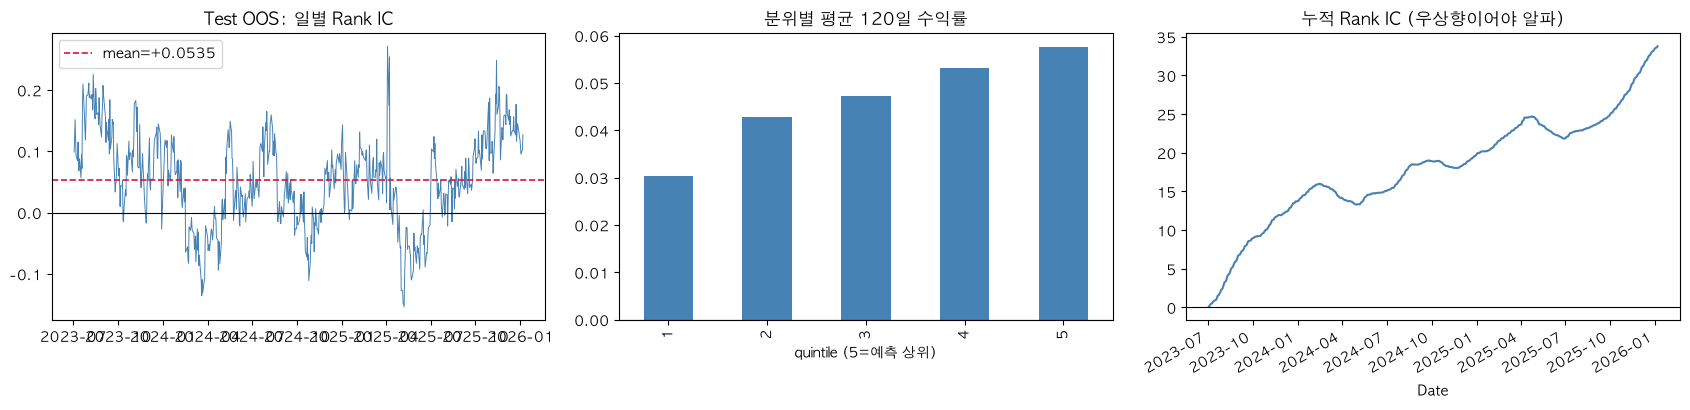

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

axes[0].plot(ic_oos.index, ic_oos.values, lw=.7, color="steelblue")
axes[0].axhline(0, color="k", lw=.8)
axes[0].axhline(ic_oos.mean(), color="crimson", ls="--", lw=1.2,
                label=f"mean={ic_oos.mean():+.4f}")
axes[0].set_title("Test OOS: 일별 Rank IC"); axes[0].legend()

qmean.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].axhline(0, color="k", lw=.8)
axes[1].set_title("분위별 평균 120일 수익률"); axes[1].set_xlabel("quintile (5=예측 상위)")

ic_oos.cumsum().plot(ax=axes[2], color="steelblue")
axes[2].axhline(0, color="k", lw=.8)
axes[2].set_title("누적 Rank IC (우상향이어야 알파)")
plt.tight_layout(); plt.show()

## 6-1. 비중첩 리밸런싱 백테스트

타겟이 120일인데 매일 예측하면 라벨이 중첩됩니다.
실제 운용처럼 **120거래일마다 한 번만 리밸런싱**해서 비교합니다.

리밸런싱 6회 (120거래일 간격, 왕복비용 10bp 반영) — LGBM
      Date   n   top_q  bottom_q  equal_weight  long_short
2023-07-03 489  0.0830    0.0271        0.0491      0.0539
2023-12-21 489  0.0843    0.0112        0.0511      0.0711
2024-06-14 491  0.1307    0.1429        0.1416     -0.0142
2024-12-05 490 -0.0205   -0.0778       -0.0414      0.0553
2025-06-02 491  0.0153    0.0812        0.0442     -0.0679
2025-11-20 488  0.2760    0.0568        0.1123      0.2172

[기간 누적 (복리 연결)]
  top_q        : +68.49%
  equal_weight : +40.17%
  bottom_q     : +25.08%
  long_short   : +33.24%
  초과(top-eq)   : +28.32%p

[회차 집중도 — 한 번의 리밸런싱이 성과를 독식하는가]
  회차별 초과 : +3.38%, +3.33%, -1.10%, +2.09%, -2.89%, +16.37%
  양(+) 회차  : 4/6회
  최대 기여   : 2025-11-20 (+16.37%)
  전체 초과   : +28.32%p
  최대회차 제외: +6.03%p  (전체 초과의 21% 만 남음)
  >>> 경고: 초과수익의 절반 이상이 단 한 회차에서 나왔다.
      리밸런싱 6회 중 1회에 의존하는 결과는 일반화 근거로 쓸 수 없다.

>>> top_q 가 equal_weight 를 못 이기면 모델을 쓸 이유가 없다.
>>> 리밸런싱 횟수가 적어 통계적 유의성은 낮음 — 발표 때 반드시 언급할 것.


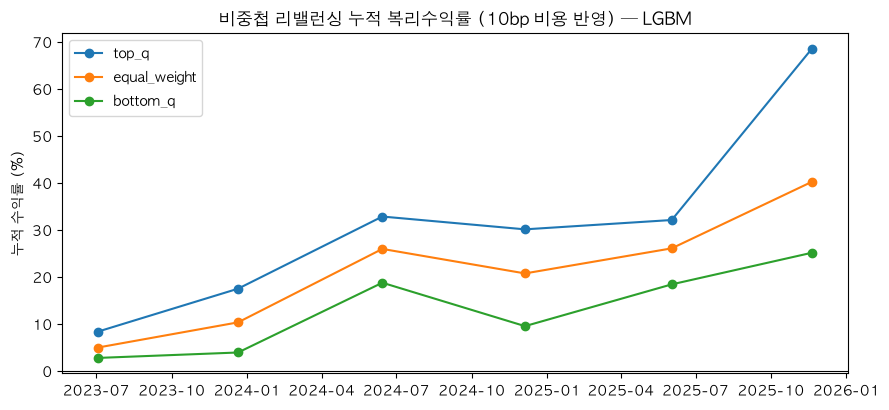

In [19]:
def backtest(te, pred_col, target_col, rebalance=120, top_q=5, q=5, cost_bps=COST_BPS,
             apply_membership=None):
    """비중첩 리밸런싱 백테스트.

    수정 ⑱ : apply_membership 을 인자로 뺐다.
              None 이면 전역 APPLY_MEMBERSHIP_EVAL 을 따르고,
              True/False 를 주면 그 값이 우선한다 (자격필터 A/B 에 필요).
    """
    use_mb = APPLY_MEMBERSHIP_EVAL if apply_membership is None else bool(apply_membership)
    dates = np.sort(te["Date"].unique())[::rebalance]
    rows = []
    for d in dates:
        g = te[te["Date"] == d].dropna(subset=[pred_col, target_col])
        # 수정 ⑫ : 이 리밸런싱 날짜에 실제로 담을 수 있었던 종목만
        if use_mb and "eligible" in g.columns:
            g = g[g["eligible"]]
        if len(g) < 50:
            continue
        g = g.copy()
        g["q"] = pd.qcut(g[pred_col].rank(method="first"), q, labels=False) + 1
        # ===== 수정 ⑰ : 로그수익률 / 단리수익률 혼용 =====
        # (before) top 만 np.expm1(...) 로 단리 변환하고
        #          bottom / equal_weight 은 로그수익률 평균 그대로 썼다.
        #          expm1(x) > x (x>0) 이므로 top_q 가 체계적으로 부풀려진다.
        # (after)  횡단면 포트폴리오 평균은 단리로 통일.
        simple = np.expm1(g[target_col])
        top = simple[g["q"] == top_q].mean()
        bot = simple[g["q"] == 1].mean()
        eq  = simple.mean()
        cost = cost_bps / 10000
        rows.append({"Date": pd.Timestamp(d), "n": len(g),
                     "top_q": top - cost, "bottom_q": bot - cost,
                     "equal_weight": eq, "long_short": top - bot - 2 * cost})
    return pd.DataFrame(rows)


def _compound(x):
    """단리 수익률 시퀀스를 복리로 연결."""
    a = np.asarray(x, dtype=float)
    if not len(a):
        return np.nan
    return float(np.prod(1.0 + a) - 1.0)


def summarize_bt(bt, label=""):
    """수정 ⑰+⑲+㉑ : 세 모델이 똑같은 방식으로 집계되도록 하나로 묶었다.

    ⑰ 단리 수익률을 '더한 뒤 expm1' 하던 집계를 복리 연결로 교체
    ⑲ 그래프도 cumsum(로그 가정) -> cumprod(복리 자산곡선)
    ㉑ 한 회차가 초과수익을 독식하는지 자동 점검
    """
    tag = f" — {label}" if label else ""
    if bt is None or not len(bt):
        print("리밸런싱 결과가 없습니다.")
        return {}

    print(f"리밸런싱 {len(bt)}회 (120거래일 간격, 왕복비용 {COST_BPS}bp 반영){tag}")
    print(bt.round(4).to_string(index=False))

    cols = ["top_q", "equal_weight", "bottom_q", "long_short"]
    cum = {c: _compound(bt[c]) for c in cols}
    print("\n[기간 누적 (복리 연결)]")
    for c in cols:
        print(f"  {c:<13}: {cum[c]*100:+.2f}%")
    tot = cum["top_q"] - cum["equal_weight"]
    print(f"  {'초과(top-eq)':<13}: {tot*100:+.2f}%p")

    # ---------- 수정 ㉑ : 회차 집중도 ----------
    ex = (bt["top_q"] - bt["equal_weight"]).to_numpy(dtype=float)
    k = int(np.argmax(ex))
    keep = np.ones(len(bt), dtype=bool)
    keep[k] = False
    wo = _compound(bt["top_q"].to_numpy()[keep]) - _compound(bt["equal_weight"].to_numpy()[keep])
    print("\n[회차 집중도 — 한 번의 리밸런싱이 성과를 독식하는가]")
    print("  회차별 초과 : " + ", ".join(f"{v:+.2%}" for v in ex))
    print(f"  양(+) 회차  : {int((ex > 0).sum())}/{len(ex)}회")
    print(f"  최대 기여   : {bt['Date'].iloc[k].date()} ({ex[k]:+.2%})")
    print(f"  전체 초과   : {tot*100:+.2f}%p")
    print(f"  최대회차 제외: {wo*100:+.2f}%p", end="")
    if abs(tot) > 1e-12:
        share = wo / tot
        print(f"  (전체 초과의 {share*100:.0f}% 만 남음)")
        if share < 0.5:
            print("  >>> 경고: 초과수익의 절반 이상이 단 한 회차에서 나왔다.")
            print("      리밸런싱 6회 중 1회에 의존하는 결과는 일반화 근거로 쓸 수 없다.")
    else:
        print()

    print("\n>>> top_q 가 equal_weight 를 못 이기면 모델을 쓸 이유가 없다.")
    print(">>> 리밸런싱 횟수가 적어 통계적 유의성은 낮음 — 발표 때 반드시 언급할 것.")

    # 수정 ⑲ : 단리 수익률에 cumsum 을 쓰면 안 된다. 복리 자산곡선으로 그린다.
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for c in ["top_q", "equal_weight", "bottom_q"]:
        curve = (np.cumprod(1.0 + bt[c].to_numpy(dtype=float)) - 1.0) * 100
        ax.plot(bt["Date"], curve, marker="o", label=c)
    ax.axhline(0, color="k", lw=.8)
    ax.legend()
    ax.set_ylabel("누적 수익률 (%)")
    ax.set_title(f"비중첩 리밸런싱 누적 복리수익률 ({COST_BPS}bp 비용 반영){tag}")
    plt.tight_layout()
    plt.show()
    return cum


bt = backtest(te_lgbm, "pred", TARGET)
BT_CUM_LGBM = summarize_bt(bt, "LGBM")


## 6-2. 결과가 운인가 실력인가 — 유의성 검증

리밸런싱 4회짜리 결과는 그 자체로는 아무것도 증명하지 못합니다.
4번 던져 4번 이길 확률이 6.25% 니까요. 세 가지로 확인합니다.

1. **리밸런싱 시작일 스윕** — 시작일을 0~119일 옮겨가며 120번 백테스트.
   지금 결과가 시점 운이면 분포 중앙값이 0 근처에 몰립니다.
2. **일별 IC 자기상관 보정** — 타겟이 120일 중첩이라 인접 IC 는 독립이 아닙니다.
   유효 표본수로 보정한 t 값을 봅니다.
3. **귀무분포** — 예측을 날짜 안에서 무작위로 섞어 같은 지표를 1,000번 계산.
   실제 값이 그 분포의 몇 % 지점인지가 경험적 p-value 입니다.

[스윕 설정] Test 거래일 751일 -> offset 당 리밸런싱 6회
리밸런싱 시작일 0~119일 스윕 중...
완료 1초 | 120개 시나리오

[초과수익(top_q - equal_weight) 분포]  리밸런싱 회당 5회
count    120.0000
mean       0.0546
std        0.0651
min       -0.0984
5%        -0.0307
25%        0.0086
50%        0.0478
75%        0.0922
95%        0.1687
max        0.2416

  양(+)의 초과수익이 나온 시작일 비율 : 78.3%
  중앙값 초과수익                     : +0.0478
  현재 노트북이 쓴 offset=0 결과      : +0.0994 (상위 22% 지점)

  >>> 비율이 50% 근처거나 중앙값이 0 근처면 = 시점 운
  >>> 비율 80%+ 이고 중앙값이 뚜렷한 양수면 = 신호가 있을 가능성


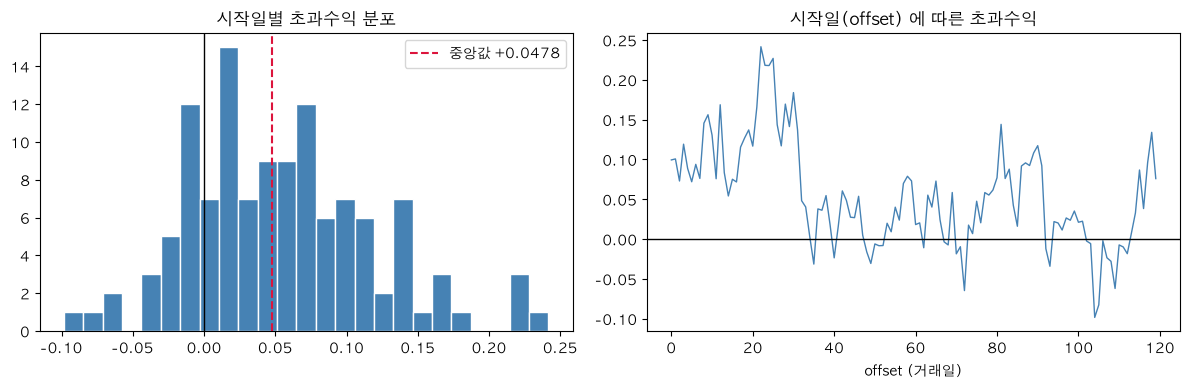

In [20]:
# ---------------------------------------------------------------
# 1. 리밸런싱 시작일 스윕
# ---------------------------------------------------------------
# 수정 ⑪ : [:3] 하드코딩 -> Test 길이에 맞춰 자동 계산
#           (모든 offset 에서 동일한 리밸런싱 횟수를 보장하는 최대값)
_sw = np.sort(df_test["Date"].unique())
SWEEP_N_REBAL = max(1, len(_sw) // HORIZON)
print(f"[스윕 설정] Test 거래일 {len(_sw)}일 -> offset 당 리밸런싱 {SWEEP_N_REBAL}회")

def backtest_offset(te, pred_col, target_col, offset, rebalance=HORIZON,
                    q=5, cost_bps=COST_BPS):
    dates = np.sort(te["Date"].unique())[offset::rebalance][:SWEEP_N_REBAL]
    top, eq, ls = [], [], []
    for d in dates:
        g = te[te["Date"] == d]
        # 수정 ⑫ : 그날 실제 구성종목만
        if APPLY_MEMBERSHIP_EVAL and "eligible" in g.columns:
            g = g[g["eligible"]]
        if len(g) < 50:
            continue
        qq = pd.qcut(g[pred_col].rank(method="first"), q, labels=False) + 1
        t_ = g.loc[qq == q, target_col].mean()
        b_ = g.loc[qq == 1, target_col].mean()
        c = cost_bps / 10000
        top.append(t_ - c); eq.append(g[target_col].mean()); ls.append(t_ - b_ - 2 * c)
    if not top:
        return None
    return {"offset": offset, "n_rebal": len(top),
            "top_q": float(np.sum(top)), "equal_weight": float(np.sum(eq)),
            "excess": float(np.sum(top) - np.sum(eq)), "long_short": float(np.sum(ls))}

print(f"리밸런싱 시작일 0~{HORIZON-1}일 스윕 중...")
t0 = time.time()
sweep = pd.DataFrame([r for r in (backtest_offset(te_lgbm, "pred", TARGET, o)
                                  for o in range(HORIZON)) if r])
print(f"완료 {time.time()-t0:.0f}초 | {len(sweep)}개 시나리오\n")

print(f"[초과수익(top_q - equal_weight) 분포]  리밸런싱 회당 {sweep['n_rebal'].median():.0f}회")
print(sweep["excess"].describe(percentiles=[.05,.25,.5,.75,.95]).round(4).to_string())
win = (sweep["excess"] > 0).mean()
print(f"\n  양(+)의 초과수익이 나온 시작일 비율 : {win:.1%}")
print(f"  중앙값 초과수익                     : {sweep['excess'].median():+.4f}")
print(f"  현재 노트북이 쓴 offset=0 결과      : {sweep.loc[sweep.offset==0,'excess'].iloc[0]:+.4f} "
      f"(상위 {(sweep['excess'] >= sweep.loc[sweep.offset==0,'excess'].iloc[0]).mean():.0%} 지점)")
print("\n  >>> 비율이 50% 근처거나 중앙값이 0 근처면 = 시점 운")
print("  >>> 비율 80%+ 이고 중앙값이 뚜렷한 양수면 = 신호가 있을 가능성")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(sweep["excess"], bins=25, color="steelblue", edgecolor="w")
ax[0].axvline(0, color="k", lw=1)
ax[0].axvline(sweep["excess"].median(), color="crimson", ls="--",
              label=f"중앙값 {sweep['excess'].median():+.4f}")
ax[0].set_title("시작일별 초과수익 분포"); ax[0].legend()
ax[1].plot(sweep["offset"], sweep["excess"], lw=1, color="steelblue")
ax[1].axhline(0, color="k", lw=1)
ax[1].set_title("시작일(offset) 에 따른 초과수익"); ax[1].set_xlabel("offset (거래일)")
plt.tight_layout(); plt.show()

In [21]:
# ---------------------------------------------------------------
# 2. 일별 IC 자기상관 보정
# ---------------------------------------------------------------
ic = (
    ic_oos.sort_index()
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

x = ic.to_numpy(dtype=float)
n = len(x)

if n < 3:
    raise ValueError("HAC 계산에는 최소 3개의 유효한 일별 IC가 필요합니다.")

mean_ic = x.mean()
std_ic = x.std(ddof=1)

if std_ic <= 0:
    raise ValueError("일별 IC의 분산이 0이므로 유의성 검정을 할 수 없습니다.")

print("[일별 Rank IC 자기상관]")
for lag in [1, 5, 20, 60, 120]:
    if lag < n - 1:
        print(f"  lag {lag:>3}일 : {ic.autocorr(lag=lag):+.3f}")


def hac_mean_test(values, max_lag):
    """평균의 Newey-West 표준오차: Bartlett 가중 + n/(n-1) 보정."""
    values = np.asarray(values, dtype=float)
    n_obs = len(values)
    lag = min(int(max_lag), n_obs - 1)

    centered = values - values.mean()

    # 장기분산 = gamma(0) + 2 * Σ weight(k) * gamma(k)
    long_run_var = np.dot(centered, centered) / n_obs

    for k in range(1, lag + 1):
        weight = 1.0 - k / (lag + 1)
        gamma_k = np.dot(centered[k:], centered[:-k]) / n_obs
        long_run_var += 2.0 * weight * gamma_k

    # 평균 분산에 소표본 배율 n/(n-1) 적용
    variance_mean = long_run_var / n_obs * n_obs / (n_obs - 1)

    if variance_mean <= 0:
        raise ValueError("HAC 분산이 양수가 아닙니다. IC 시계열을 점검하세요.")

    se = np.sqrt(variance_mean)
    t_value = values.mean() / se

    return {
        "lag": lag,
        "mean_ic": values.mean(),
        "hac_se": se,
        "hac_t": t_value,
        "p_normal_2s": 2.0 * norm.sf(abs(t_value)),
        "ci95_low": values.mean() - norm.ppf(0.975) * se,
        "ci95_high": values.mean() + norm.ppf(0.975) * se,
    }


HAC_LAG = min(int(HORIZON), n - 1)

# 시차 선택에 따른 민감도도 함께 확인
lags = sorted({
    min(lag, n - 1)
    for lag in [20, 40, 60, 90, HAC_LAG]
})

hac_table = pd.DataFrame([
    hac_mean_test(x, lag) for lag in lags
])

main_hac = hac_mean_test(x, HAC_LAG)
t_naive = mean_ic / (std_ic / np.sqrt(n))
t_hac = main_hac["hac_t"]

print(f"\n관측일수       : {n:,}일")
print(f"평균 Daily IC  : {mean_ic:+.5f}")
print(f"보정 전 t      : {t_naive:.3f}")
print(f"HAC 보정 t     : {t_hac:.3f} (lag={HAC_LAG})")
print(f"양측 p값       : {main_hac['p_normal_2s']:.6g} (정규근사)")
print(
    f"평균 IC 95% 구간: "
    f"[{main_hac['ci95_low']:+.5f}, {main_hac['ci95_high']:+.5f}]"
)

print("\n[HAC 시차 민감도]")
print(hac_table.round(6).to_string(index=False))

print(
    "\n※ HAC p값과 신뢰구간은 점근적 근사입니다. "
    "짧은 표본과 시장 국면 변화의 한계는 남습니다."
)

# 기존 검증 요약을 유지하면서 해당 항목만 갱신
VALIDATION_lgbm = dict(globals().get("VALIDATION_lgbm", {}))
VALIDATION_lgbm.pop("ic_t_adjusted", None)

VALIDATION_lgbm.update({
    "ic_t_naive": float(t_naive),
    "ic_t_hac": float(t_hac),
    "ic_hac_lag": int(HAC_LAG),
    "ic_hac_p_normal_2s": float(main_hac["p_normal_2s"]),
    "ic_hac_ci95_low": float(main_hac["ci95_low"]),
    "ic_hac_ci95_high": float(main_hac["ci95_high"]),
})

[일별 Rank IC 자기상관]
  lag   1일 : +0.887
  lag   5일 : +0.731
  lag  20일 : +0.426
  lag  60일 : -0.037
  lag 120일 : -0.180

관측일수       : 631일
평균 Daily IC  : +0.05354
보정 전 t      : 17.997
HAC 보정 t     : 3.352 (lag=120)
양측 p값       : 0.000803031 (정규근사)
평균 IC 95% 구간: [+0.02223, +0.08485]

[HAC 시차 민감도]
 lag  mean_ic   hac_se    hac_t  p_normal_2s  ci95_low  ci95_high
  20 0.053543 0.011424 4.686888     0.000003  0.031153   0.075934
  40 0.053543 0.014285 3.748199     0.000178  0.025545   0.081541
  60 0.053543 0.015559 3.441259     0.000579  0.023048   0.084039
  90 0.053543 0.016159 3.313464     0.000921  0.021872   0.085215
 120 0.053543 0.015975 3.351748     0.000803  0.022233   0.084853

※ HAC p값과 신뢰구간은 점근적 근사입니다. 짧은 표본과 시장 국면 변화의 한계는 남습니다.


귀무분포 1,000회 계산 중 (631개 날짜)...
완료: 2.3초

실제 Q5-Q1          : +0.02737
귀무분포 평균/표준편차: -0.00004 / 0.00119
실제 이상 극단값 횟수 : 0 / 1,000
보정 양측 p값        : 0.000999

※ 이 검정은 해당 기간의 무작위 종목 선정과 비교합니다.
   날짜마다 독립적으로 섞으므로 시간 의존성을 보존하지 않습니다.
   리밸런싱 누적수익률이나 미래 재현성의 검정은 아닙니다.


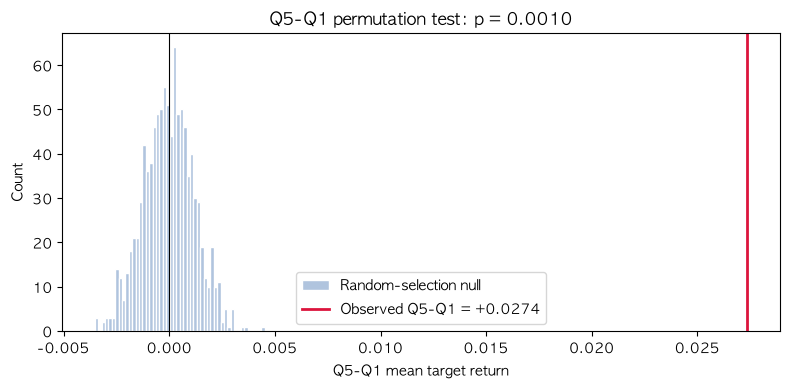


[검증 요약]
{
  "ic_t_naive": 17.99713954034131,
  "ic_t_hac": 3.351747883238888,
  "ic_hac_lag": 120,
  "ic_hac_p_normal_2s": 0.0008030311244532944,
  "ic_hac_ci95_low": 0.02223335955771978,
  "ic_hac_ci95_high": 0.08485311543964875,
  "q_spread_observed": 0.027367143020116242,
  "q_spread_p_value": 0.000999000999000999,
  "q_spread_n_permutations": 1000,
  "q_spread_n_extreme": 0,
  "q_spread_test": "within_date_permutation_pooled_mean_two_sided"
}


In [22]:
# ---------------------------------------------------------------
# 3. Q5-Q1 귀무분포 — 실제와 동일한 그룹 크기·집계 방식
# ---------------------------------------------------------------
N_PERM = 1000
N_QUANTILES = 5

v = te_lgbm[["Date", "pred", TARGET]].copy()
v["Date"] = pd.to_datetime(v["Date"])
v[["pred", TARGET]] = v[["pred", TARGET]].replace(
    [np.inf, -np.inf], np.nan
)
v = v.dropna(subset=["Date", "pred", TARGET])

groups = []
observed_top_sum = 0.0
observed_bottom_sum = 0.0
total_top_n = 0
total_bottom_n = 0

for date, g in v.groupby("Date", sort=True):
    if len(g) < N_QUANTILES:
        continue

    # 기존 evaluate()와 같은 분위 배정
    # method="first"의 동률 처리를 위해 날짜 안의 기존 행 순서 유지
    q_labels = pd.qcut(
        g["pred"].rank(method="first"),
        N_QUANTILES,
        labels=False,
    ).to_numpy()

    y = g[TARGET].to_numpy(dtype=float)
    top_mask = q_labels == N_QUANTILES - 1
    bottom_mask = q_labels == 0

    n_top = int(top_mask.sum())
    n_bottom = int(bottom_mask.sum())

    groups.append((y, n_top, n_bottom))

    observed_top_sum += y[top_mask].sum()
    observed_bottom_sum += y[bottom_mask].sum()
    total_top_n += n_top
    total_bottom_n += n_bottom

if not groups:
    raise ValueError("분위 검정을 수행할 수 있는 날짜가 없습니다.")

# 실제 통계량: Q5 전체 행 평균 - Q1 전체 행 평균
obs = (
    observed_top_sum / total_top_n
    - observed_bottom_sum / total_bottom_n
)

rng = np.random.default_rng(RANDOM_STATE)
null = np.empty(N_PERM, dtype=float)

print(
    f"귀무분포 {N_PERM:,}회 계산 중 "
    f"({len(groups):,}개 날짜)..."
)
t0 = time.time()

for it in range(N_PERM):
    shuffled_top_sum = 0.0
    shuffled_bottom_sum = 0.0

    for y, n_top, n_bottom in groups:
        # 날짜 안에서 타깃을 섞는 것은
        # 고정된 타깃에 무작위 예측 순위를 배정하는 것과 동등
        shuffled = rng.permutation(y)

        shuffled_top_sum += shuffled[:n_top].sum()
        shuffled_bottom_sum += shuffled[-n_bottom:].sum()

    # 실제와 정확히 같은 집계 방식
    null[it] = (
        shuffled_top_sum / total_top_n
        - shuffled_bottom_sum / total_bottom_n
    )

# 양측 검정: |귀무 통계량| >= |실제 통계량|
n_extreme = int(np.count_nonzero(np.abs(null) >= abs(obs)))

# 유한 횟수 Monte Carlo 순열검정의 plus-one 보정
p_emp = (n_extreme + 1) / (N_PERM + 1)

print(f"완료: {time.time() - t0:.1f}초")
print(f"\n실제 Q5-Q1          : {obs:+.5f}")
print(
    f"귀무분포 평균/표준편차: "
    f"{null.mean():+.5f} / {null.std(ddof=1):.5f}"
)
print(f"실제 이상 극단값 횟수 : {n_extreme:,} / {N_PERM:,}")
print(f"보정 양측 p값        : {p_emp:.6f}")

print(
    "\n※ 이 검정은 해당 기간의 무작위 종목 선정과 비교합니다."
    "\n   날짜마다 독립적으로 섞으므로 시간 의존성을 보존하지 않습니다."
    "\n   리밸런싱 누적수익률이나 미래 재현성의 검정은 아닙니다."
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    null,
    bins=50,
    color="lightsteelblue",
    edgecolor="white",
    label="Random-selection null",
)
ax.axvline(
    obs,
    color="crimson",
    linewidth=2,
    label=f"Observed Q5-Q1 = {obs:+.4f}",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Q5-Q1 permutation test: p = {p_emp:.4f}")
ax.set_xlabel("Q5-Q1 mean target return")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

# 위 HAC 셀에서 저장한 결과를 덮어쓰지 않음
VALIDATION_lgbm = dict(globals().get("VALIDATION_lgbm", {}))
VALIDATION_lgbm.update({
    "q_spread_observed": float(obs),
    "q_spread_p_value": float(p_emp),
    "q_spread_n_permutations": int(N_PERM),
    "q_spread_n_extreme": int(n_extreme),
    "q_spread_test": "within_date_permutation_pooled_mean_two_sided",
})

print("\n[검증 요약]")
print(json.dumps(VALIDATION_lgbm, indent=2, ensure_ascii=False))

## 결과 요약

In [23]:
summary = {
    "선정기준":            SELECT_BY,
    "채택 feature set":    BEST_SET,
    "피처 수":             len(FEATURES_FINAL),
    "KMeans 매핑":         str(RISK_PROFILE),
    "노트북 매핑과 일치":  RISK_PROFILE == {0: "Stable", 2: "Moderate", 1: "Aggressive", 3: "High_Risk"},
    "OOS daily_ic":        round(float(rep_oos["daily_ic"]), 5),
    "OOS ic_ir":           round(float(rep_oos["ic_ir"]), 4),
    "OOS IC양수일비율(구 hit_rate)":        round(float(rep_oos["hit_rate"]), 4),
    "OOS Q5-Q1":           round(float(rep_oos["q_spread"]), 5),
    "OOS overall_ic(진단)": round(float(rep_oos["overall_ic"]), 4),
}
summary.update({f"검증_{k}": v for k, v in globals().get("VALIDATION_lgbm", {}).items()})
print(json.dumps(summary, ensure_ascii=False, indent=2))

save_ml_results(
    out_dir=OUT_DIR,
    model_name="lightgbm",
    summary=summary,
    cmp_df=cmp_df,
    bt=bt
)

# OUT_DIR.mkdir(exist_ok=True)
# with open(OUT_DIR / "04_ml_summary.json", "w", encoding="utf-8") as f:
#     json.dump(summary, f, ensure_ascii=False, indent=2)
# cmp_df.to_csv(OUT_DIR / "04_ml_feature_sets.csv", index=False)
# bt.to_csv(OUT_DIR / "04_ml_backtest.csv", index=False)
# print(f"\n저장 완료: {OUT_DIR}")

{
  "선정기준": "daily_ic",
  "채택 feature set": "252+Long",
  "피처 수": 6,
  "KMeans 매핑": "{1: 'Stable', 0: 'Moderate', 3: 'Aggressive', 2: 'High_Risk'}",
  "노트북 매핑과 일치": false,
  "OOS daily_ic": 0.05354,
  "OOS ic_ir": 0.7165,
  "OOS IC양수일비율(구 hit_rate)": 0.7544,
  "OOS Q5-Q1": 0.02737,
  "OOS overall_ic(진단)": 0.1369,
  "검증_ic_t_naive": 17.99713954034131,
  "검증_ic_t_hac": 3.351747883238888,
  "검증_ic_hac_lag": 120,
  "검증_ic_hac_p_normal_2s": 0.0008030311244532944,
  "검증_ic_hac_ci95_low": 0.02223335955771978,
  "검증_ic_hac_ci95_high": 0.08485311543964875,
  "검증_q_spread_observed": 0.027367143020116242,
  "검증_q_spread_p_value": 0.000999000999000999,
  "검증_q_spread_n_permutations": 1000,
  "검증_q_spread_n_extreme": 0,
  "검증_q_spread_test": "within_date_permutation_pooled_mean_two_sided"
}

저장 완료 [lightgbm]: /Users/genie/Documents/GitHub/stock-to-rich-Mid-project/outputs


# 7. 최종 OOS 평가 - XGB

In [24]:
# ============================================================
# 수정 ⑱ : 자격필터 A/B 를 위해 '필터 전' 프레임에 먼저 점수를 매긴다
# ============================================================
# (before) te_xgb = eval_universe(df_test) 로 이미 걸러진 뒤 점수를 매겨서
#          9장 A/B 의 OFF 분기에 되돌릴 종목이 남아있지 않았다(= no-op).
# (after)  te_xgb_all(필터 전) 에 점수를 매기고, te_xgb 는 거기서 필터링.
te_xgb_all = df_test.dropna(subset=FEATURES_FINAL + [TARGET]).copy()

final_model = xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_xgb_params)
print(f"최종 학습: {len(tr):,}행 x {len(FEATURES_FINAL)}피처 ...")
t0 = time.time()
final_model.fit(tr[FEATURES_FINAL], tr[TARGET])
print(f"완료 {time.time()-t0:.0f}초")

te_xgb_all["pred"] = final_model.predict(te_xgb_all[FEATURES_FINAL])

# 수정 ⑫ : 평가 후보를 그날 실제 S&P500 구성종목으로 제한
te_xgb = eval_universe(te_xgb_all, verbose=True)

rep_oos, ic_oos, qmean = evaluate(te_xgb, "pred", TARGET)
print("\n" + "=" * 60)
print("Test OOS 결과 (완전 미사용 구간) — XGB")
print("=" * 60)
for k, v in rep_oos.items():
    print(f"  {k:<11}: {v:,.5f}" if isinstance(v, float) else f"  {k:<11}: {v:,}")
# 수정 ㉔ : hit_rate 는 '종목 적중률' 이 아니다
print("  ※ hit_rate = 일별 IC 가 양수인 '날'의 비율입니다. 종목 적중률이 아닙니다.")
print("  ※ overall_ic 는 진단용 참고치일 뿐 성능 지표가 아닙니다(셀 10 자체점검 참조).")

print("\n[Q1~Q5 분위별 평균 120일 로그수익률]")
print(qmean.round(5).to_string())
print(f"\n  Q5 - Q1 = {rep_oos['q_spread']:+.5f}")
print("  (0 근처면 종목 선별력이 없다는 직접 증거 -> 피벗 근거)")

# Train 성능과 비교
tr_s = tr.sample(min(200000, len(tr)), random_state=RANDOM_STATE).copy()
tr_s["pred"] = final_model.predict(tr_s[FEATURES_FINAL])
rep_in, _, _ = evaluate(tr_s, "pred", TARGET)
print(f"\n[In-sample vs OOS]  daily_ic  {rep_in['daily_ic']:+.5f} -> {rep_oos['daily_ic']:+.5f}")
print(f"                    q_spread  {rep_in['q_spread']:+.5f} -> {rep_oos['q_spread']:+.5f}")


최종 학습: 779,022행 x 6피처 ...
완료 2초
  [자격필터] 386,718 -> 309,475행 (20.0% 제외)

Test OOS 결과 (완전 미사용 구간) — XGB
  daily_ic   : 0.05966
  ic_std     : 0.06993
  ic_ir      : 0.85315
  hit_rate   : 0.79556
  q_spread   : 0.03548699617385864
  overall_ic : 0.13572
  n_days     : 631
  n_obs      : 309,475
  ※ hit_rate = 일별 IC 가 양수인 '날'의 비율입니다. 종목 적중률이 아닙니다.
  ※ overall_ic 는 진단용 참고치일 뿐 성능 지표가 아닙니다(셀 10 자체점검 참조).

[Q1~Q5 분위별 평균 120일 로그수익률]
q
1    0.02548
2    0.04444
3    0.04804
4    0.05236
5    0.06097

  Q5 - Q1 = +0.03549
  (0 근처면 종목 선별력이 없다는 직접 증거 -> 피벗 근거)

[In-sample vs OOS]  daily_ic  +0.15169 -> +0.05966
                    q_spread  +0.10934 -> +0.03549


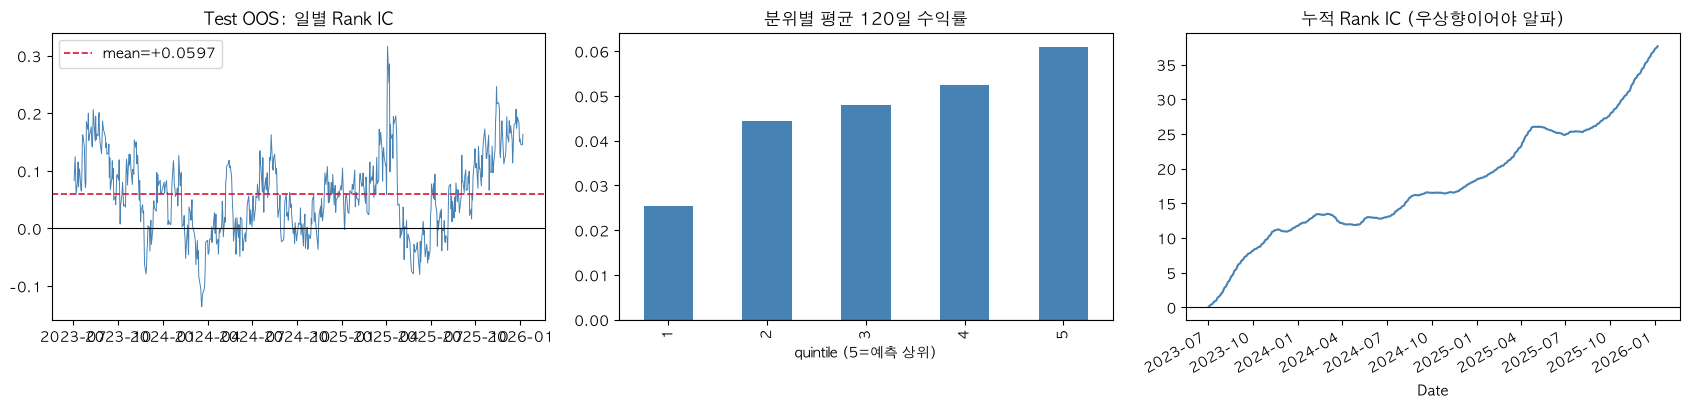

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

axes[0].plot(ic_oos.index, ic_oos.values, lw=.7, color="steelblue")
axes[0].axhline(0, color="k", lw=.8)
axes[0].axhline(ic_oos.mean(), color="crimson", ls="--", lw=1.2,
                label=f"mean={ic_oos.mean():+.4f}")
axes[0].set_title("Test OOS: 일별 Rank IC"); axes[0].legend()

qmean.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].axhline(0, color="k", lw=.8)
axes[1].set_title("분위별 평균 120일 수익률"); axes[1].set_xlabel("quintile (5=예측 상위)")

ic_oos.cumsum().plot(ax=axes[2], color="steelblue")
axes[2].axhline(0, color="k", lw=.8)
axes[2].set_title("누적 Rank IC (우상향이어야 알파)")
plt.tight_layout(); plt.show()

## 7-1.

리밸런싱 6회 (120거래일 간격, 왕복비용 10bp 반영) — XGB
      Date   n   top_q  bottom_q  equal_weight  long_short
2023-07-03 489  0.0887    0.0375        0.0491      0.0492
2023-12-21 489  0.0712    0.0035        0.0511      0.0657
2024-06-14 491  0.1005    0.1099        0.1416     -0.0114
2024-12-05 490 -0.0066   -0.0582       -0.0414      0.0497
2025-06-02 491  0.0191    0.0907        0.0442     -0.0736
2025-11-20 488  0.2903    0.0512        0.1123      0.2372

[기간 누적 (복리 연결)]
  top_q        : +67.67%
  equal_weight : +40.17%
  bottom_q     : +24.78%
  long_short   : +32.98%
  초과(top-eq)   : +27.51%p

[회차 집중도 — 한 번의 리밸런싱이 성과를 독식하는가]
  회차별 초과 : +3.96%, +2.01%, -4.11%, +3.48%, -2.51%, +17.80%
  양(+) 회차  : 4/6회
  최대 기여   : 2025-11-20 (+17.80%)
  전체 초과   : +27.51%p
  최대회차 제외: +3.93%p  (전체 초과의 14% 만 남음)
  >>> 경고: 초과수익의 절반 이상이 단 한 회차에서 나왔다.
      리밸런싱 6회 중 1회에 의존하는 결과는 일반화 근거로 쓸 수 없다.

>>> top_q 가 equal_weight 를 못 이기면 모델을 쓸 이유가 없다.
>>> 리밸런싱 횟수가 적어 통계적 유의성은 낮음 — 발표 때 반드시 언급할 것.


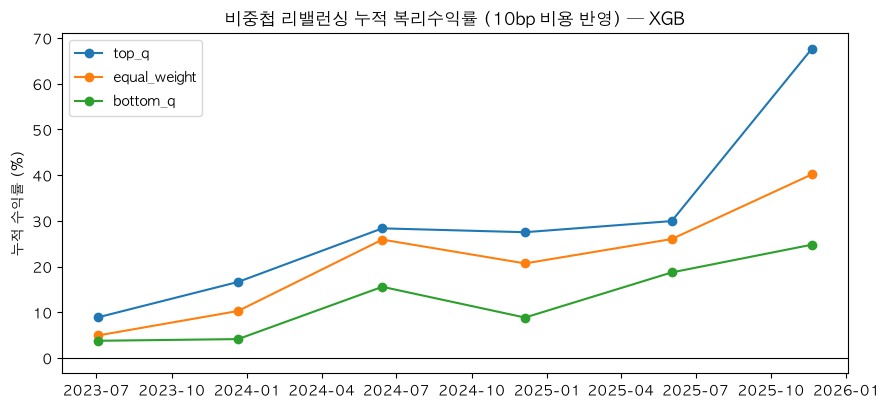

In [26]:
bt = backtest(te_xgb, "pred", TARGET)
BT_CUM_XGB = summarize_bt(bt, "XGB")


## 7-2

리밸런싱 시작일 0~119일 스윕 중...
완료 1초 | 120개 시나리오

[초과수익(top_q - equal_weight) 분포]  리밸런싱 회당 5회
count    120.0000
mean       0.0722
std        0.0617
min       -0.0931
5%        -0.0229
25%        0.0294
50%        0.0641
75%        0.1218
95%        0.1660
max        0.2046

  양(+)의 초과수익이 나온 시작일 비율 : 89.2%
  중앙값 초과수익                     : +0.0641
  현재 노트북이 쓴 offset=0 결과      : +0.0947 (상위 36% 지점)

  >>> 비율이 50% 근처거나 중앙값이 0 근처면 = 시점 운
  >>> 비율 80%+ 이고 중앙값이 뚜렷한 양수면 = 신호가 있을 가능성


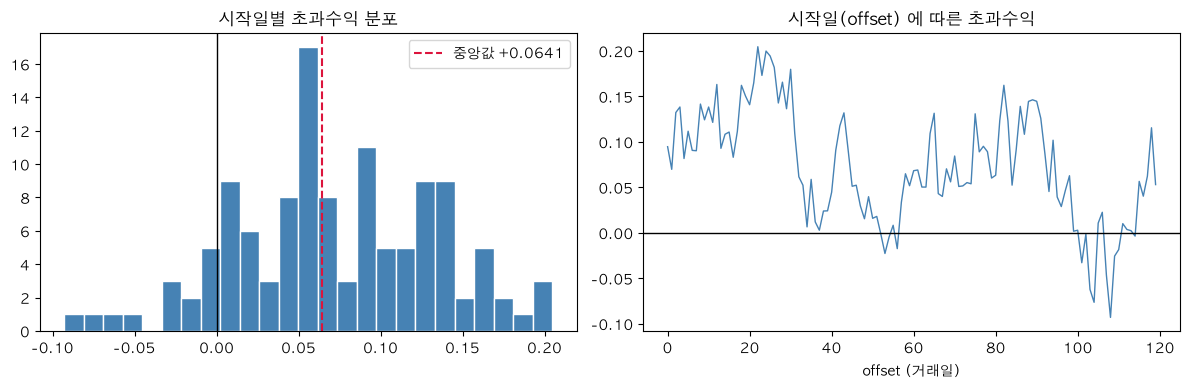

In [27]:
print(f"리밸런싱 시작일 0~{HORIZON-1}일 스윕 중...")
t0 = time.time()
sweep = pd.DataFrame([r for r in (backtest_offset(te_xgb, "pred", TARGET, o)
                                  for o in range(HORIZON)) if r])
print(f"완료 {time.time()-t0:.0f}초 | {len(sweep)}개 시나리오\n")

print(f"[초과수익(top_q - equal_weight) 분포]  리밸런싱 회당 {sweep['n_rebal'].median():.0f}회")
print(sweep["excess"].describe(percentiles=[.05,.25,.5,.75,.95]).round(4).to_string())
win = (sweep["excess"] > 0).mean()
print(f"\n  양(+)의 초과수익이 나온 시작일 비율 : {win:.1%}")
print(f"  중앙값 초과수익                     : {sweep['excess'].median():+.4f}")
print(f"  현재 노트북이 쓴 offset=0 결과      : {sweep.loc[sweep.offset==0,'excess'].iloc[0]:+.4f} "
      f"(상위 {(sweep['excess'] >= sweep.loc[sweep.offset==0,'excess'].iloc[0]).mean():.0%} 지점)")
print("\n  >>> 비율이 50% 근처거나 중앙값이 0 근처면 = 시점 운")
print("  >>> 비율 80%+ 이고 중앙값이 뚜렷한 양수면 = 신호가 있을 가능성")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(sweep["excess"], bins=25, color="steelblue", edgecolor="w")
ax[0].axvline(0, color="k", lw=1)
ax[0].axvline(sweep["excess"].median(), color="crimson", ls="--",
              label=f"중앙값 {sweep['excess'].median():+.4f}")
ax[0].set_title("시작일별 초과수익 분포"); ax[0].legend()
ax[1].plot(sweep["offset"], sweep["excess"], lw=1, color="steelblue")
ax[1].axhline(0, color="k", lw=1)
ax[1].set_title("시작일(offset) 에 따른 초과수익"); ax[1].set_xlabel("offset (거래일)")
plt.tight_layout(); plt.show()

In [28]:
# ---------------------------------------------------------------
# 2. 일별 IC 자기상관 보정
# ---------------------------------------------------------------
ic = (
    ic_oos.sort_index()
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

x = ic.to_numpy(dtype=float)
n = len(x)

if n < 3:
    raise ValueError("HAC 계산에는 최소 3개의 유효한 일별 IC가 필요합니다.")

mean_ic = x.mean()
std_ic = x.std(ddof=1)

if std_ic <= 0:
    raise ValueError("일별 IC의 분산이 0이므로 유의성 검정을 할 수 없습니다.")

print("[일별 Rank IC 자기상관]")
for lag in [1, 5, 20, 60, 120]:
    if lag < n - 1:
        print(f"  lag {lag:>3}일 : {ic.autocorr(lag=lag):+.3f}")


def hac_mean_test(values, max_lag):
    """평균의 Newey-West 표준오차: Bartlett 가중 + n/(n-1) 보정."""
    values = np.asarray(values, dtype=float)
    n_obs = len(values)
    lag = min(int(max_lag), n_obs - 1)

    centered = values - values.mean()

    # 장기분산 = gamma(0) + 2 * Σ weight(k) * gamma(k)
    long_run_var = np.dot(centered, centered) / n_obs

    for k in range(1, lag + 1):
        weight = 1.0 - k / (lag + 1)
        gamma_k = np.dot(centered[k:], centered[:-k]) / n_obs
        long_run_var += 2.0 * weight * gamma_k

    # 평균 분산에 소표본 배율 n/(n-1) 적용
    variance_mean = long_run_var / n_obs * n_obs / (n_obs - 1)

    if variance_mean <= 0:
        raise ValueError("HAC 분산이 양수가 아닙니다. IC 시계열을 점검하세요.")

    se = np.sqrt(variance_mean)
    t_value = values.mean() / se

    return {
        "lag": lag,
        "mean_ic": values.mean(),
        "hac_se": se,
        "hac_t": t_value,
        "p_normal_2s": 2.0 * norm.sf(abs(t_value)),
        "ci95_low": values.mean() - norm.ppf(0.975) * se,
        "ci95_high": values.mean() + norm.ppf(0.975) * se,
    }


HAC_LAG = min(int(HORIZON), n - 1)

# 시차 선택에 따른 민감도도 함께 확인
lags = sorted({
    min(lag, n - 1)
    for lag in [20, 40, 60, 90, HAC_LAG]
})

hac_table = pd.DataFrame([
    hac_mean_test(x, lag) for lag in lags
])

main_hac = hac_mean_test(x, HAC_LAG)
t_naive = mean_ic / (std_ic / np.sqrt(n))
t_hac = main_hac["hac_t"]

print(f"\n관측일수       : {n:,}일")
print(f"평균 Daily IC  : {mean_ic:+.5f}")
print(f"보정 전 t      : {t_naive:.3f}")
print(f"HAC 보정 t     : {t_hac:.3f} (lag={HAC_LAG})")
print(f"양측 p값       : {main_hac['p_normal_2s']:.6g} (정규근사)")
print(
    f"평균 IC 95% 구간: "
    f"[{main_hac['ci95_low']:+.5f}, {main_hac['ci95_high']:+.5f}]"
)

print("\n[HAC 시차 민감도]")
print(hac_table.round(6).to_string(index=False))

print(
    "\n※ HAC p값과 신뢰구간은 점근적 근사입니다. "
    "짧은 표본과 시장 국면 변화의 한계는 남습니다."
)

# 기존 검증 요약을 유지하면서 해당 항목만 갱신
VALIDATION_xgb = dict(globals().get("VALIDATION_xgb", {}))
VALIDATION_xgb.pop("ic_t_adjusted", None)

VALIDATION_xgb.update({
    "ic_t_naive": float(t_naive),
    "ic_t_hac": float(t_hac),
    "ic_hac_lag": int(HAC_LAG),
    "ic_hac_p_normal_2s": float(main_hac["p_normal_2s"]),
    "ic_hac_ci95_low": float(main_hac["ci95_low"]),
    "ic_hac_ci95_high": float(main_hac["ci95_high"]),
})

[일별 Rank IC 자기상관]
  lag   1일 : +0.895
  lag   5일 : +0.732
  lag  20일 : +0.415
  lag  60일 : +0.023
  lag 120일 : -0.208

관측일수       : 631일
평균 Daily IC  : +0.05966
보정 전 t      : 21.431
HAC 보정 t     : 4.053 (lag=120)
양측 p값       : 5.0518e-05 (정규근사)
평균 IC 95% 구간: [+0.03081, +0.08851]

[HAC 시차 민감도]
 lag  mean_ic   hac_se    hac_t  p_normal_2s  ci95_low  ci95_high
  20 0.059664 0.010621 5.617281     0.000000  0.038846   0.080481
  40 0.059664 0.013143 4.539546     0.000006  0.033904   0.085424
  60 0.059664 0.014296 4.173418     0.000030  0.031644   0.087684
  90 0.059664 0.014974 3.984558     0.000068  0.030316   0.089012
 120 0.059664 0.014720 4.053217     0.000051  0.030813   0.088514

※ HAC p값과 신뢰구간은 점근적 근사입니다. 짧은 표본과 시장 국면 변화의 한계는 남습니다.


귀무분포 1,000회 계산 중 (631개 날짜)...
완료: 2.3초

실제 Q5-Q1          : +0.03549
귀무분포 평균/표준편차: -0.00004 / 0.00119
실제 이상 극단값 횟수 : 0 / 1,000
보정 양측 p값        : 0.000999

※ 이 검정은 해당 기간의 무작위 종목 선정과 비교합니다.
   날짜마다 독립적으로 섞으므로 시간 의존성을 보존하지 않습니다.
   리밸런싱 누적수익률이나 미래 재현성의 검정은 아닙니다.


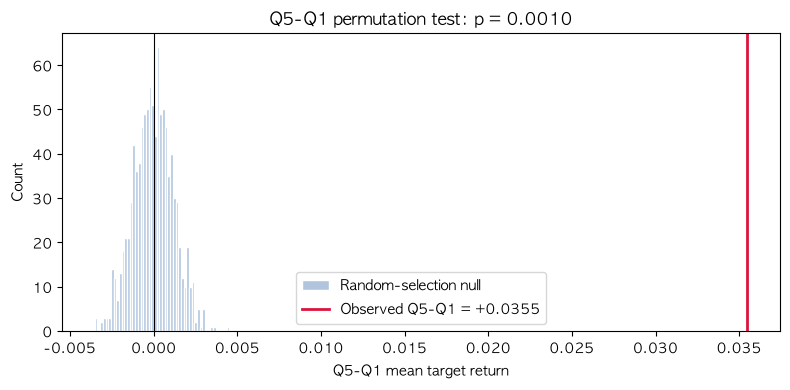


[검증 요약]
{
  "ic_t_naive": 21.4308947231798,
  "ic_t_hac": 4.053217382255918,
  "ic_hac_lag": 120,
  "ic_hac_p_normal_2s": 5.051801987732334e-05,
  "ic_hac_ci95_low": 0.030812838359909472,
  "ic_hac_ci95_high": 0.08851445586381604,
  "q_spread_observed": 0.03548699769091469,
  "q_spread_p_value": 0.000999000999000999,
  "q_spread_n_permutations": 1000,
  "q_spread_n_extreme": 0,
  "q_spread_test": "within_date_permutation_pooled_mean_two_sided"
}


In [29]:
# ---------------------------------------------------------------
# 3. Q5-Q1 귀무분포 — 실제와 동일한 그룹 크기·집계 방식
# ---------------------------------------------------------------
N_PERM = 1000
N_QUANTILES = 5

v = te_xgb[["Date", "pred", TARGET]].copy()
v["Date"] = pd.to_datetime(v["Date"])
v[["pred", TARGET]] = v[["pred", TARGET]].replace(
    [np.inf, -np.inf], np.nan
)
v = v.dropna(subset=["Date", "pred", TARGET])

groups = []
observed_top_sum = 0.0
observed_bottom_sum = 0.0
total_top_n = 0
total_bottom_n = 0

for date, g in v.groupby("Date", sort=True):
    if len(g) < N_QUANTILES:
        continue

    # 기존 evaluate()와 같은 분위 배정
    # method="first"의 동률 처리를 위해 날짜 안의 기존 행 순서 유지
    q_labels = pd.qcut(
        g["pred"].rank(method="first"),
        N_QUANTILES,
        labels=False,
    ).to_numpy()

    y = g[TARGET].to_numpy(dtype=float)
    top_mask = q_labels == N_QUANTILES - 1
    bottom_mask = q_labels == 0

    n_top = int(top_mask.sum())
    n_bottom = int(bottom_mask.sum())

    groups.append((y, n_top, n_bottom))

    observed_top_sum += y[top_mask].sum()
    observed_bottom_sum += y[bottom_mask].sum()
    total_top_n += n_top
    total_bottom_n += n_bottom

if not groups:
    raise ValueError("분위 검정을 수행할 수 있는 날짜가 없습니다.")

# 실제 통계량: Q5 전체 행 평균 - Q1 전체 행 평균
obs = (
    observed_top_sum / total_top_n
    - observed_bottom_sum / total_bottom_n
)

rng = np.random.default_rng(RANDOM_STATE)
null = np.empty(N_PERM, dtype=float)

print(
    f"귀무분포 {N_PERM:,}회 계산 중 "
    f"({len(groups):,}개 날짜)..."
)
t0 = time.time()

for it in range(N_PERM):
    shuffled_top_sum = 0.0
    shuffled_bottom_sum = 0.0

    for y, n_top, n_bottom in groups:
        # 날짜 안에서 타깃을 섞는 것은
        # 고정된 타깃에 무작위 예측 순위를 배정하는 것과 동등
        shuffled = rng.permutation(y)

        shuffled_top_sum += shuffled[:n_top].sum()
        shuffled_bottom_sum += shuffled[-n_bottom:].sum()

    # 실제와 정확히 같은 집계 방식
    null[it] = (
        shuffled_top_sum / total_top_n
        - shuffled_bottom_sum / total_bottom_n
    )

# 양측 검정: |귀무 통계량| >= |실제 통계량|
n_extreme = int(np.count_nonzero(np.abs(null) >= abs(obs)))

# 유한 횟수 Monte Carlo 순열검정의 plus-one 보정
p_emp = (n_extreme + 1) / (N_PERM + 1)

print(f"완료: {time.time() - t0:.1f}초")
print(f"\n실제 Q5-Q1          : {obs:+.5f}")
print(
    f"귀무분포 평균/표준편차: "
    f"{null.mean():+.5f} / {null.std(ddof=1):.5f}"
)
print(f"실제 이상 극단값 횟수 : {n_extreme:,} / {N_PERM:,}")
print(f"보정 양측 p값        : {p_emp:.6f}")

print(
    "\n※ 이 검정은 해당 기간의 무작위 종목 선정과 비교합니다."
    "\n   날짜마다 독립적으로 섞으므로 시간 의존성을 보존하지 않습니다."
    "\n   리밸런싱 누적수익률이나 미래 재현성의 검정은 아닙니다."
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    null,
    bins=50,
    color="lightsteelblue",
    edgecolor="white",
    label="Random-selection null",
)
ax.axvline(
    obs,
    color="crimson",
    linewidth=2,
    label=f"Observed Q5-Q1 = {obs:+.4f}",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Q5-Q1 permutation test: p = {p_emp:.4f}")
ax.set_xlabel("Q5-Q1 mean target return")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

# 위 HAC 셀에서 저장한 결과를 덮어쓰지 않음
VALIDATION_xgb = dict(globals().get("VALIDATION_xgb", {}))
VALIDATION_xgb.update({
    "q_spread_observed": float(obs),
    "q_spread_p_value": float(p_emp),
    "q_spread_n_permutations": int(N_PERM),
    "q_spread_n_extreme": int(n_extreme),
    "q_spread_test": "within_date_permutation_pooled_mean_two_sided",
})

print("\n[검증 요약]")
print(json.dumps(VALIDATION_xgb, indent=2, ensure_ascii=False))

## 결과 요약

In [30]:
summary = {
    "선정기준":            SELECT_BY,
    "채택 feature set":    BEST_SET,
    "피처 수":             len(FEATURES_FINAL),
    "KMeans 매핑":         str(RISK_PROFILE),
    "노트북 매핑과 일치":  RISK_PROFILE == {0: "Stable", 2: "Moderate", 1: "Aggressive", 3: "High_Risk"},
    "OOS daily_ic":        round(float(rep_oos["daily_ic"]), 5),
    "OOS ic_ir":           round(float(rep_oos["ic_ir"]), 4),
    "OOS IC양수일비율(구 hit_rate)":        round(float(rep_oos["hit_rate"]), 4),
    "OOS Q5-Q1":           round(float(rep_oos["q_spread"]), 5),
    "OOS overall_ic(진단)": round(float(rep_oos["overall_ic"]), 4),
}
summary.update({f"검증_{k}": v for k, v in globals().get("VALIDATION_xgb", {}).items()})
print(json.dumps(summary, ensure_ascii=False, indent=2))

save_ml_results(
    out_dir=OUT_DIR,
    model_name="xgb",
    summary=summary,
    cmp_df=cmp_df,
    bt=bt
)

{
  "선정기준": "daily_ic",
  "채택 feature set": "252+Long",
  "피처 수": 6,
  "KMeans 매핑": "{1: 'Stable', 0: 'Moderate', 3: 'Aggressive', 2: 'High_Risk'}",
  "노트북 매핑과 일치": false,
  "OOS daily_ic": 0.05966,
  "OOS ic_ir": 0.8532,
  "OOS IC양수일비율(구 hit_rate)": 0.7956,
  "OOS Q5-Q1": 0.03549,
  "OOS overall_ic(진단)": 0.1357,
  "검증_ic_t_naive": 21.4308947231798,
  "검증_ic_t_hac": 4.053217382255918,
  "검증_ic_hac_lag": 120,
  "검증_ic_hac_p_normal_2s": 5.051801987732334e-05,
  "검증_ic_hac_ci95_low": 0.030812838359909472,
  "검증_ic_hac_ci95_high": 0.08851445586381604,
  "검증_q_spread_observed": 0.03548699769091469,
  "검증_q_spread_p_value": 0.000999000999000999,
  "검증_q_spread_n_permutations": 1000,
  "검증_q_spread_n_extreme": 0,
  "검증_q_spread_test": "within_date_permutation_pooled_mean_two_sided"
}

저장 완료 [xgb]: /Users/genie/Documents/GitHub/stock-to-rich-Mid-project/outputs


# 8. Catboost

In [31]:
if RUN_CAT:
    import catboost as cat

    model_cat = cat.CatBoostRegressor(random_state=RANDOM_STATE, thread_count=-1, verbose=0)
    param_cat = {
        "depth": [2, 3, 4, 5, 6],
        "learning_rate": [0.01, 0.02, 0.03, 0.05],
        "iterations": [300, 500, 800],
        "min_data_in_leaf": [1, 3, 5, 10, 20],
        "l2_leaf_reg": [0.5, 1.0, 1.5, 3.0, 5.0],
        "rsm": [0.8, 0.9, 1.0],
        "subsample": [0.8, 0.9, 1.0],
        "random_strength": [0.0, 0.1, 0.5, 1.0]
    }

    res_cat, best_cat_params, oof_cat = purged_search(
        df_search, FEATURES_FINAL, TARGET, model_cat, param_cat)

    # ===== 수정 ④ : cat 자체 importance =====
    d = df_search[FEATURES_FINAL + [TARGET]].dropna()
    fitted_cat = cat.CatBoostRegressor(random_state=RANDOM_STATE, thread_count=-1, verbose=0, **best_cat_params)
    fitted_cat.fit(d[FEATURES_FINAL], d[TARGET])

    imp_cat = (pd.DataFrame({"feature": FEATURES_FINAL,
                             "importance": fitted_cat.feature_importances_})
               .sort_values("importance", ascending=False).reset_index(drop=True))
    imp_cat["importance_pct"] = imp_cat["importance"] / imp_cat["importance"].sum() * 100
    imp_cat["type"] = np.where(imp_cat["feature"].str.contains("_diff_"), "Difference", "Original")

    print("\n[catBoost feature importance — LGBM 것이 아님]")
    print(imp_cat.round(4).to_string(index=False))
    print("\n[type 별 합계]")
    print(imp_cat.groupby("type")["importance_pct"].sum().round(2).to_string())
    print("\n>>> 주의: importance 가 높다 != 성능이 좋아진다.")
    print(">>> 위 4-1 의 daily_ic 비교가 성능의 근거이고, importance 는 해석 보조자료일 뿐.")
else:
    print("RUN_XGB=False -> 건너뜀")

Samples 155,929 | Features 6 | Dates 253 | Folds 5 | Trials 20
[ 1/20] daily_ic=-0.03850 ic_ir=-0.3435 q_spread=-0.02884 (overall_ic=+0.0963) 2s
[ 2/20] daily_ic=-0.07529 ic_ir=-0.6459 q_spread=-0.05430 (overall_ic=-0.1053) 1s
[ 3/20] daily_ic=-0.02138 ic_ir=-0.1813 q_spread=-0.01459 (overall_ic=+0.1042) 3s
[ 4/20] daily_ic=-0.06466 ic_ir=-0.5845 q_spread=-0.04571 (overall_ic=+0.0202) 2s
[ 5/20] daily_ic=-0.05921 ic_ir=-0.5791 q_spread=-0.04464 (overall_ic=+0.0564) 1s
[ 6/20] daily_ic=-0.05205 ic_ir=-0.5067 q_spread=-0.03962 (overall_ic=+0.0661) 2s
[ 7/20] daily_ic=-0.05591 ic_ir=-0.5422 q_spread=-0.04204 (overall_ic=+0.0624) 2s
[ 8/20] daily_ic=-0.03189 ic_ir=-0.2734 q_spread=-0.02374 (overall_ic=+0.0979) 3s
[ 9/20] daily_ic=-0.05137 ic_ir=-0.4829 q_spread=-0.03827 (overall_ic=+0.0711) 2s
[10/20] daily_ic=-0.02784 ic_ir=-0.2329 q_spread=-0.02185 (overall_ic=+0.1025) 4s
[11/20] daily_ic=-0.05277 ic_ir=-0.4662 q_spread=-0.03761 (overall_ic=+0.0664) 2s
[12/20] daily_ic=-0.05432 ic_ir=-0.

In [32]:
# ============================================================
# 수정 ⑱ : 자격필터 A/B 를 위해 '필터 전' 프레임에 먼저 점수를 매긴다
# ============================================================
# (before) te_cat = eval_universe(df_test) 로 이미 걸러진 뒤 점수를 매겨서
#          9장 A/B 의 OFF 분기에 되돌릴 종목이 남아있지 않았다(= no-op).
# (after)  te_cat_all(필터 전) 에 점수를 매기고, te_cat 는 거기서 필터링.
te_cat_all = df_test.dropna(subset=FEATURES_FINAL + [TARGET]).copy()

final_model = cat.CatBoostRegressor(random_state=RANDOM_STATE, thread_count=-1, verbose=0, **best_cat_params)
print(f"최종 학습: {len(tr):,}행 x {len(FEATURES_FINAL)}피처 ...")
t0 = time.time()
final_model.fit(tr[FEATURES_FINAL], tr[TARGET])
print(f"완료 {time.time()-t0:.0f}초")

te_cat_all["pred"] = final_model.predict(te_cat_all[FEATURES_FINAL])

# 수정 ⑫ : 평가 후보를 그날 실제 S&P500 구성종목으로 제한
te_cat = eval_universe(te_cat_all, verbose=True)

rep_oos, ic_oos, qmean = evaluate(te_cat, "pred", TARGET)
print("\n" + "=" * 60)
print("Test OOS 결과 (완전 미사용 구간) — CatBoost")
print("=" * 60)
for k, v in rep_oos.items():
    print(f"  {k:<11}: {v:,.5f}" if isinstance(v, float) else f"  {k:<11}: {v:,}")
# 수정 ㉔ : hit_rate 는 '종목 적중률' 이 아니다
print("  ※ hit_rate = 일별 IC 가 양수인 '날'의 비율입니다. 종목 적중률이 아닙니다.")
print("  ※ overall_ic 는 진단용 참고치일 뿐 성능 지표가 아닙니다(셀 10 자체점검 참조).")

print("\n[Q1~Q5 분위별 평균 120일 로그수익률]")
print(qmean.round(5).to_string())
print(f"\n  Q5 - Q1 = {rep_oos['q_spread']:+.5f}")
print("  (0 근처면 종목 선별력이 없다는 직접 증거 -> 피벗 근거)")

# Train 성능과 비교
tr_s = tr.sample(min(200000, len(tr)), random_state=RANDOM_STATE).copy()
tr_s["pred"] = final_model.predict(tr_s[FEATURES_FINAL])
rep_in, _, _ = evaluate(tr_s, "pred", TARGET)
print(f"\n[In-sample vs OOS]  daily_ic  {rep_in['daily_ic']:+.5f} -> {rep_oos['daily_ic']:+.5f}")
print(f"                    q_spread  {rep_in['q_spread']:+.5f} -> {rep_oos['q_spread']:+.5f}")


최종 학습: 779,022행 x 6피처 ...
완료 4초
  [자격필터] 386,718 -> 309,475행 (20.0% 제외)

Test OOS 결과 (완전 미사용 구간) — CatBoost
  daily_ic   : 0.06445
  ic_std     : 0.07671
  ic_ir      : 0.84024
  hit_rate   : 0.79556
  q_spread   : 0.035082053393125534
  overall_ic : 0.14417
  n_days     : 631
  n_obs      : 309,475
  ※ hit_rate = 일별 IC 가 양수인 '날'의 비율입니다. 종목 적중률이 아닙니다.
  ※ overall_ic 는 진단용 참고치일 뿐 성능 지표가 아닙니다(셀 10 자체점검 참조).

[Q1~Q5 분위별 평균 120일 로그수익률]
q
1    0.02696
2    0.04262
3    0.04872
4    0.05094
5    0.06204

  Q5 - Q1 = +0.03508
  (0 근처면 종목 선별력이 없다는 직접 증거 -> 피벗 근거)

[In-sample vs OOS]  daily_ic  +0.13945 -> +0.06445
                    q_spread  +0.10039 -> +0.03508


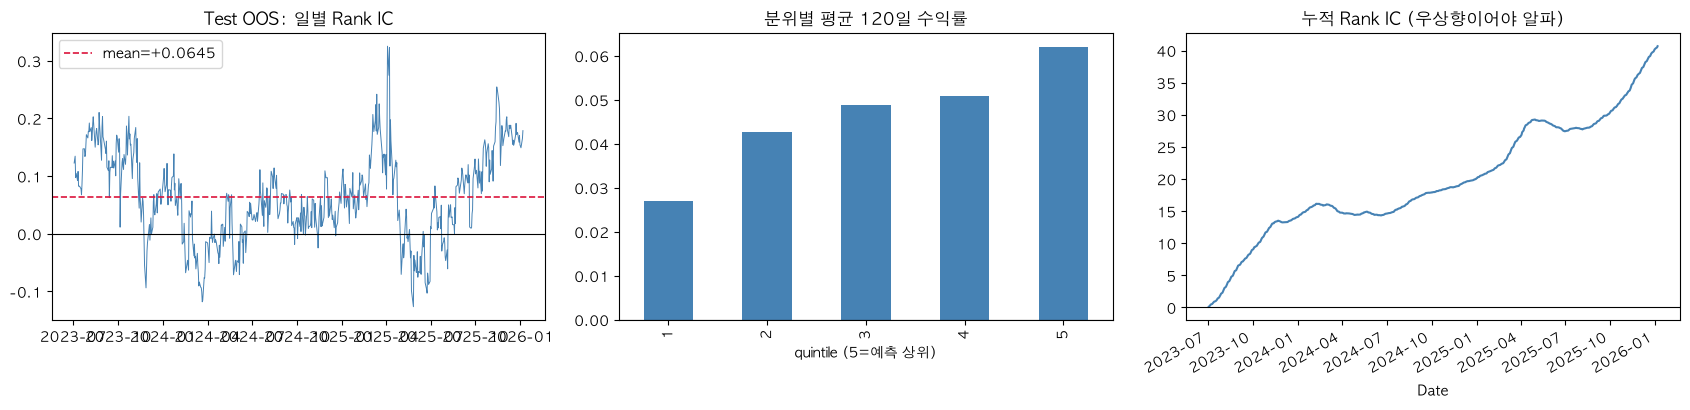

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

axes[0].plot(ic_oos.index, ic_oos.values, lw=.7, color="steelblue")
axes[0].axhline(0, color="k", lw=.8)
axes[0].axhline(ic_oos.mean(), color="crimson", ls="--", lw=1.2,
                label=f"mean={ic_oos.mean():+.4f}")
axes[0].set_title("Test OOS: 일별 Rank IC"); axes[0].legend()

qmean.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].axhline(0, color="k", lw=.8)
axes[1].set_title("분위별 평균 120일 수익률"); axes[1].set_xlabel("quintile (5=예측 상위)")

ic_oos.cumsum().plot(ax=axes[2], color="steelblue")
axes[2].axhline(0, color="k", lw=.8)
axes[2].set_title("누적 Rank IC (우상향이어야 알파)")
plt.tight_layout(); plt.show()

## 8-1

리밸런싱 6회 (120거래일 간격, 왕복비용 10bp 반영) — CatBoost
      Date   n   top_q  bottom_q  equal_weight  long_short
2023-07-03 489  0.0907    0.0249        0.0491      0.0638
2023-12-21 489  0.0667    0.0170        0.0511      0.0476
2024-06-14 491  0.1018    0.1072        0.1416     -0.0074
2024-12-05 490 -0.0161   -0.0551       -0.0414      0.0370
2025-06-02 491  0.0176    0.1148        0.0442     -0.0992
2025-11-20 488  0.3136    0.0423        0.1123      0.2692

[기간 누적 (복리 연결)]
  top_q        : +68.58%
  equal_weight : +40.17%
  bottom_q     : +26.71%
  long_short   : +31.16%
  초과(top-eq)   : +28.42%p

[회차 집중도 — 한 번의 리밸런싱이 성과를 독식하는가]
  회차별 초과 : +4.16%, +1.56%, -3.99%, +2.53%, -2.66%, +20.13%
  양(+) 회차  : 4/6회
  최대 기여   : 2025-11-20 (+20.13%)
  전체 초과   : +28.42%p
  최대회차 제외: +2.33%p  (전체 초과의 8% 만 남음)
  >>> 경고: 초과수익의 절반 이상이 단 한 회차에서 나왔다.
      리밸런싱 6회 중 1회에 의존하는 결과는 일반화 근거로 쓸 수 없다.

>>> top_q 가 equal_weight 를 못 이기면 모델을 쓸 이유가 없다.
>>> 리밸런싱 횟수가 적어 통계적 유의성은 낮음 — 발표 때 반드시 언급할 것.


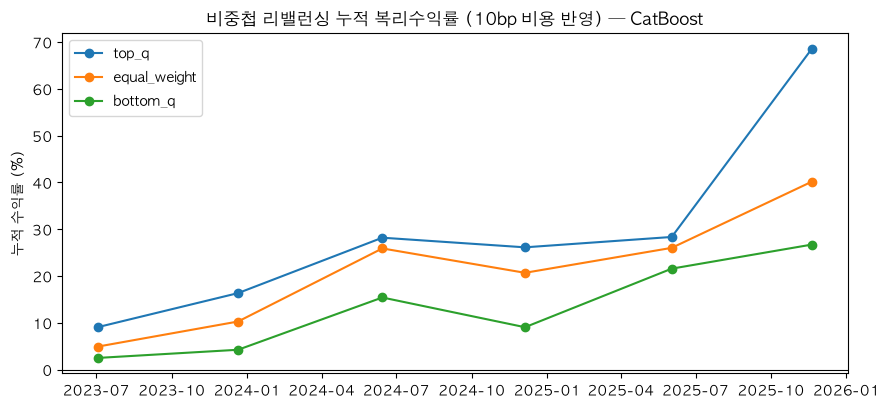

In [34]:
bt = backtest(te_cat, "pred", TARGET)
BT_CUM_CAT = summarize_bt(bt, "CatBoost")


## 8-2

리밸런싱 시작일 0~119일 스윕 중...
완료 1초 | 120개 시나리오

[초과수익(top_q - equal_weight) 분포]  리밸런싱 회당 5회
count    120.0000
mean       0.0778
std        0.0614
min       -0.0765
5%        -0.0266
25%        0.0367
50%        0.0819
75%        0.1113
95%        0.1779
max        0.2351

  양(+)의 초과수익이 나온 시작일 비율 : 86.7%
  중앙값 초과수익                     : +0.0819
  현재 노트북이 쓴 offset=0 결과      : +0.1037 (상위 32% 지점)

  >>> 비율이 50% 근처거나 중앙값이 0 근처면 = 시점 운
  >>> 비율 80%+ 이고 중앙값이 뚜렷한 양수면 = 신호가 있을 가능성


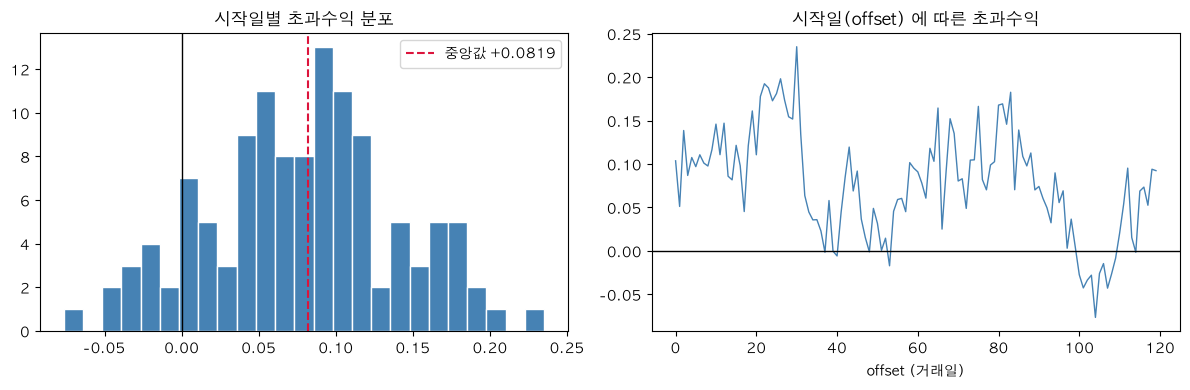

In [35]:
print(f"리밸런싱 시작일 0~{HORIZON-1}일 스윕 중...")
t0 = time.time()
sweep = pd.DataFrame([r for r in (backtest_offset(te_cat, "pred", TARGET, o)
                                  for o in range(HORIZON)) if r])
print(f"완료 {time.time()-t0:.0f}초 | {len(sweep)}개 시나리오\n")

print(f"[초과수익(top_q - equal_weight) 분포]  리밸런싱 회당 {sweep['n_rebal'].median():.0f}회")
print(sweep["excess"].describe(percentiles=[.05,.25,.5,.75,.95]).round(4).to_string())
win = (sweep["excess"] > 0).mean()
print(f"\n  양(+)의 초과수익이 나온 시작일 비율 : {win:.1%}")
print(f"  중앙값 초과수익                     : {sweep['excess'].median():+.4f}")
print(f"  현재 노트북이 쓴 offset=0 결과      : {sweep.loc[sweep.offset==0,'excess'].iloc[0]:+.4f} "
      f"(상위 {(sweep['excess'] >= sweep.loc[sweep.offset==0,'excess'].iloc[0]).mean():.0%} 지점)")
print("\n  >>> 비율이 50% 근처거나 중앙값이 0 근처면 = 시점 운")
print("  >>> 비율 80%+ 이고 중앙값이 뚜렷한 양수면 = 신호가 있을 가능성")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(sweep["excess"], bins=25, color="steelblue", edgecolor="w")
ax[0].axvline(0, color="k", lw=1)
ax[0].axvline(sweep["excess"].median(), color="crimson", ls="--",
              label=f"중앙값 {sweep['excess'].median():+.4f}")
ax[0].set_title("시작일별 초과수익 분포"); ax[0].legend()
ax[1].plot(sweep["offset"], sweep["excess"], lw=1, color="steelblue")
ax[1].axhline(0, color="k", lw=1)
ax[1].set_title("시작일(offset) 에 따른 초과수익"); ax[1].set_xlabel("offset (거래일)")
plt.tight_layout(); plt.show()

In [36]:
# ---------------------------------------------------------------
# 2. 일별 IC 자기상관 보정
# ---------------------------------------------------------------
ic = (
    ic_oos.sort_index()
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

x = ic.to_numpy(dtype=float)
n = len(x)

if n < 3:
    raise ValueError("HAC 계산에는 최소 3개의 유효한 일별 IC가 필요합니다.")

mean_ic = x.mean()
std_ic = x.std(ddof=1)

if std_ic <= 0:
    raise ValueError("일별 IC의 분산이 0이므로 유의성 검정을 할 수 없습니다.")

print("[일별 Rank IC 자기상관]")
for lag in [1, 5, 20, 60, 120]:
    if lag < n - 1:
        print(f"  lag {lag:>3}일 : {ic.autocorr(lag=lag):+.3f}")


def hac_mean_test(values, max_lag):
    """평균의 Newey-West 표준오차: Bartlett 가중 + n/(n-1) 보정."""
    values = np.asarray(values, dtype=float)
    n_obs = len(values)
    lag = min(int(max_lag), n_obs - 1)

    centered = values - values.mean()

    # 장기분산 = gamma(0) + 2 * Σ weight(k) * gamma(k)
    long_run_var = np.dot(centered, centered) / n_obs

    for k in range(1, lag + 1):
        weight = 1.0 - k / (lag + 1)
        gamma_k = np.dot(centered[k:], centered[:-k]) / n_obs
        long_run_var += 2.0 * weight * gamma_k

    # 평균 분산에 소표본 배율 n/(n-1) 적용
    variance_mean = long_run_var / n_obs * n_obs / (n_obs - 1)

    if variance_mean <= 0:
        raise ValueError("HAC 분산이 양수가 아닙니다. IC 시계열을 점검하세요.")

    se = np.sqrt(variance_mean)
    t_value = values.mean() / se

    return {
        "lag": lag,
        "mean_ic": values.mean(),
        "hac_se": se,
        "hac_t": t_value,
        "p_normal_2s": 2.0 * norm.sf(abs(t_value)),
        "ci95_low": values.mean() - norm.ppf(0.975) * se,
        "ci95_high": values.mean() + norm.ppf(0.975) * se,
    }


HAC_LAG = min(int(HORIZON), n - 1)

# 시차 선택에 따른 민감도도 함께 확인
lags = sorted({
    min(lag, n - 1)
    for lag in [20, 40, 60, 90, HAC_LAG]
})

hac_table = pd.DataFrame([
    hac_mean_test(x, lag) for lag in lags
])

main_hac = hac_mean_test(x, HAC_LAG)
t_naive = mean_ic / (std_ic / np.sqrt(n))
t_hac = main_hac["hac_t"]

print(f"\n관측일수       : {n:,}일")
print(f"평균 Daily IC  : {mean_ic:+.5f}")
print(f"보정 전 t      : {t_naive:.3f}")
print(f"HAC 보정 t     : {t_hac:.3f} (lag={HAC_LAG})")
print(f"양측 p값       : {main_hac['p_normal_2s']:.6g} (정규근사)")
print(
    f"평균 IC 95% 구간: "
    f"[{main_hac['ci95_low']:+.5f}, {main_hac['ci95_high']:+.5f}]"
)

print("\n[HAC 시차 민감도]")
print(hac_table.round(6).to_string(index=False))

print(
    "\n※ HAC p값과 신뢰구간은 점근적 근사입니다. "
    "짧은 표본과 시장 국면 변화의 한계는 남습니다."
)

# 기존 검증 요약을 유지하면서 해당 항목만 갱신
VALIDATION_cat = dict(globals().get("VALIDATION_cat", {}))
VALIDATION_cat.pop("ic_t_adjusted", None)

VALIDATION_cat.update({
    "ic_t_naive": float(t_naive),
    "ic_t_hac": float(t_hac),
    "ic_hac_lag": int(HAC_LAG),
    "ic_hac_p_normal_2s": float(main_hac["p_normal_2s"]),
    "ic_hac_ci95_low": float(main_hac["ci95_low"]),
    "ic_hac_ci95_high": float(main_hac["ci95_high"]),
})

[일별 Rank IC 자기상관]
  lag   1일 : +0.914
  lag   5일 : +0.764
  lag  20일 : +0.518
  lag  60일 : +0.027
  lag 120일 : -0.242

관측일수       : 631일
평균 Daily IC  : +0.06445
보정 전 t      : 21.106
HAC 보정 t     : 3.656 (lag=120)
양측 p값       : 0.000256153 (정규근사)
평균 IC 95% 구간: [+0.02990, +0.09900]

[HAC 시차 민감도]
 lag  mean_ic   hac_se    hac_t  p_normal_2s  ci95_low  ci95_high
  20 0.064451 0.012056 5.345883     0.000000  0.040821   0.088080
  40 0.064451 0.015334 4.203009     0.000026  0.034396   0.094506
  60 0.064451 0.016943 3.803863     0.000142  0.031242   0.097659
  90 0.064451 0.017871 3.606535     0.000310  0.029425   0.099476
 120 0.064451 0.017629 3.656029     0.000256  0.029899   0.099002

※ HAC p값과 신뢰구간은 점근적 근사입니다. 짧은 표본과 시장 국면 변화의 한계는 남습니다.


귀무분포 1,000회 계산 중 (631개 날짜)...
완료: 2.3초

실제 Q5-Q1          : +0.03508
귀무분포 평균/표준편차: -0.00004 / 0.00119
실제 이상 극단값 횟수 : 0 / 1,000
보정 양측 p값        : 0.000999

※ 이 검정은 해당 기간의 무작위 종목 선정과 비교합니다.
   날짜마다 독립적으로 섞으므로 시간 의존성을 보존하지 않습니다.
   리밸런싱 누적수익률이나 미래 재현성의 검정은 아닙니다.


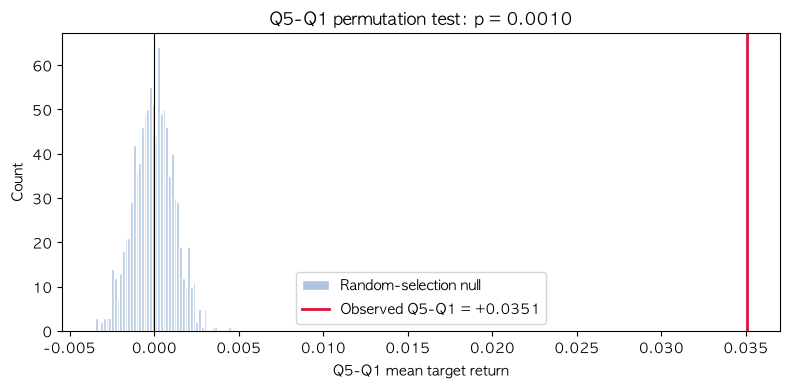


[검증 요약]
{
  "ic_t_naive": 21.106493331996592,
  "ic_t_hac": 3.656028665327679,
  "ic_hac_lag": 120,
  "ic_hac_p_normal_2s": 0.00025615272408917235,
  "ic_hac_ci95_low": 0.029899265399692218,
  "ic_hac_ci95_high": 0.09900215282069287,
  "q_spread_observed": 0.035082051066057614,
  "q_spread_p_value": 0.000999000999000999,
  "q_spread_n_permutations": 1000,
  "q_spread_n_extreme": 0,
  "q_spread_test": "within_date_permutation_pooled_mean_two_sided"
}


In [37]:
# ---------------------------------------------------------------
# 3. Q5-Q1 귀무분포 — 실제와 동일한 그룹 크기·집계 방식
# ---------------------------------------------------------------
N_PERM = 1000
N_QUANTILES = 5

v = te_cat[["Date", "pred", TARGET]].copy()
v["Date"] = pd.to_datetime(v["Date"])
v[["pred", TARGET]] = v[["pred", TARGET]].replace(
    [np.inf, -np.inf], np.nan
)
v = v.dropna(subset=["Date", "pred", TARGET])

groups = []
observed_top_sum = 0.0
observed_bottom_sum = 0.0
total_top_n = 0
total_bottom_n = 0

for date, g in v.groupby("Date", sort=True):
    if len(g) < N_QUANTILES:
        continue

    # 기존 evaluate()와 같은 분위 배정
    # method="first"의 동률 처리를 위해 날짜 안의 기존 행 순서 유지
    q_labels = pd.qcut(
        g["pred"].rank(method="first"),
        N_QUANTILES,
        labels=False,
    ).to_numpy()

    y = g[TARGET].to_numpy(dtype=float)
    top_mask = q_labels == N_QUANTILES - 1
    bottom_mask = q_labels == 0

    n_top = int(top_mask.sum())
    n_bottom = int(bottom_mask.sum())

    groups.append((y, n_top, n_bottom))

    observed_top_sum += y[top_mask].sum()
    observed_bottom_sum += y[bottom_mask].sum()
    total_top_n += n_top
    total_bottom_n += n_bottom

if not groups:
    raise ValueError("분위 검정을 수행할 수 있는 날짜가 없습니다.")

# 실제 통계량: Q5 전체 행 평균 - Q1 전체 행 평균
obs = (
    observed_top_sum / total_top_n
    - observed_bottom_sum / total_bottom_n
)

rng = np.random.default_rng(RANDOM_STATE)
null = np.empty(N_PERM, dtype=float)

print(
    f"귀무분포 {N_PERM:,}회 계산 중 "
    f"({len(groups):,}개 날짜)..."
)
t0 = time.time()

for it in range(N_PERM):
    shuffled_top_sum = 0.0
    shuffled_bottom_sum = 0.0

    for y, n_top, n_bottom in groups:
        # 날짜 안에서 타깃을 섞는 것은
        # 고정된 타깃에 무작위 예측 순위를 배정하는 것과 동등
        shuffled = rng.permutation(y)

        shuffled_top_sum += shuffled[:n_top].sum()
        shuffled_bottom_sum += shuffled[-n_bottom:].sum()

    # 실제와 정확히 같은 집계 방식
    null[it] = (
        shuffled_top_sum / total_top_n
        - shuffled_bottom_sum / total_bottom_n
    )

# 양측 검정: |귀무 통계량| >= |실제 통계량|
n_extreme = int(np.count_nonzero(np.abs(null) >= abs(obs)))

# 유한 횟수 Monte Carlo 순열검정의 plus-one 보정
p_emp = (n_extreme + 1) / (N_PERM + 1)

print(f"완료: {time.time() - t0:.1f}초")
print(f"\n실제 Q5-Q1          : {obs:+.5f}")
print(
    f"귀무분포 평균/표준편차: "
    f"{null.mean():+.5f} / {null.std(ddof=1):.5f}"
)
print(f"실제 이상 극단값 횟수 : {n_extreme:,} / {N_PERM:,}")
print(f"보정 양측 p값        : {p_emp:.6f}")

print(
    "\n※ 이 검정은 해당 기간의 무작위 종목 선정과 비교합니다."
    "\n   날짜마다 독립적으로 섞으므로 시간 의존성을 보존하지 않습니다."
    "\n   리밸런싱 누적수익률이나 미래 재현성의 검정은 아닙니다."
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    null,
    bins=50,
    color="lightsteelblue",
    edgecolor="white",
    label="Random-selection null",
)
ax.axvline(
    obs,
    color="crimson",
    linewidth=2,
    label=f"Observed Q5-Q1 = {obs:+.4f}",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Q5-Q1 permutation test: p = {p_emp:.4f}")
ax.set_xlabel("Q5-Q1 mean target return")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

# 위 HAC 셀에서 저장한 결과를 덮어쓰지 않음
VALIDATION_cat = dict(globals().get("VALIDATION_cat", {}))
VALIDATION_cat.update({
    "q_spread_observed": float(obs),
    "q_spread_p_value": float(p_emp),
    "q_spread_n_permutations": int(N_PERM),
    "q_spread_n_extreme": int(n_extreme),
    "q_spread_test": "within_date_permutation_pooled_mean_two_sided",
})

print("\n[검증 요약]")
print(json.dumps(VALIDATION_cat, indent=2, ensure_ascii=False))

## 결과 요약

In [38]:
summary = {
    "선정기준":            SELECT_BY,
    "채택 feature set":    BEST_SET,
    "피처 수":             len(FEATURES_FINAL),
    "KMeans 매핑":         str(RISK_PROFILE),
    "노트북 매핑과 일치":  RISK_PROFILE == {0: "Stable", 2: "Moderate", 1: "Aggressive", 3: "High_Risk"},
    "OOS daily_ic":        round(float(rep_oos["daily_ic"]), 5),
    "OOS ic_ir":           round(float(rep_oos["ic_ir"]), 4),
    "OOS IC양수일비율(구 hit_rate)":        round(float(rep_oos["hit_rate"]), 4),
    "OOS Q5-Q1":           round(float(rep_oos["q_spread"]), 5),
    "OOS overall_ic(진단)": round(float(rep_oos["overall_ic"]), 4),
}
summary.update({f"검증_{k}": v for k, v in globals().get("VALIDATION_cat", {}).items()})
print(json.dumps(summary, ensure_ascii=False, indent=2))

save_ml_results(
    out_dir=OUT_DIR,
    model_name="cat",
    summary=summary,
    cmp_df=cmp_df,
    bt=bt
)

{
  "선정기준": "daily_ic",
  "채택 feature set": "252+Long",
  "피처 수": 6,
  "KMeans 매핑": "{1: 'Stable', 0: 'Moderate', 3: 'Aggressive', 2: 'High_Risk'}",
  "노트북 매핑과 일치": false,
  "OOS daily_ic": 0.06445,
  "OOS ic_ir": 0.8402,
  "OOS IC양수일비율(구 hit_rate)": 0.7956,
  "OOS Q5-Q1": 0.03508,
  "OOS overall_ic(진단)": 0.1442,
  "검증_ic_t_naive": 21.106493331996592,
  "검증_ic_t_hac": 3.656028665327679,
  "검증_ic_hac_lag": 120,
  "검증_ic_hac_p_normal_2s": 0.00025615272408917235,
  "검증_ic_hac_ci95_low": 0.029899265399692218,
  "검증_ic_hac_ci95_high": 0.09900215282069287,
  "검증_q_spread_observed": 0.035082051066057614,
  "검증_q_spread_p_value": 0.000999000999000999,
  "검증_q_spread_n_permutations": 1000,
  "검증_q_spread_n_extreme": 0,
  "검증_q_spread_test": "within_date_permutation_pooled_mean_two_sided"
}

저장 완료 [cat]: /Users/genie/Documents/GitHub/stock-to-rich-Mid-project/outputs


In [39]:
# OOS 평가와 순열검정이 같은 Q-spread를 보고 있는지 확인
assert np.isclose(
    rep_oos["q_spread"],
    VALIDATION_cat["q_spread_observed"],
    rtol=1e-5,
    atol=1e-7,
), "OOS 평가와 귀무분포의 실제 Q-spread가 다릅니다."

# 새 자기상관 보정 코드가 실행되었는지 확인
assert "ic_t_hac" in VALIDATION_cat, "새 HAC 보정 셀을 실행하세요."
assert "ic_t_adjusted" not in VALIDATION_cat, "기존 보정 결과가 남아 있습니다."

---
# 8-8. [진단] CV 는 음수인데 OOS 만 양수인 이유


In [40]:
# ============================================================
# 수정 ㉒ : CV daily_ic 는 전부 음수인데 OOS 만 양수인 이유를 분해한다
# ============================================================
# 서치 60개 조합(LGBM 20 + XGB 20 + CatBoost 20)의 daily_ic 가 하나도 양수가 아니었다.
# 그런데 같은 피처·같은 파라미터로 학습한 모델의 OOS daily_ic 는 +0.05~+0.06 이다.
# "학습구간에서 선별력이 없던 신호가 미사용 구간에서만 작동한다" 는 상태이므로
# 신호(skill)인지 국면(regime)인지 구분하지 않으면 어떤 숫자도 인용할 수 없다.
#   [1] 모델을 빼고 원시 피처만으로 연도별 IC  -> 신호 자체가 구간 의존인가
#   [2] 모델 예측의 연도별 OOS IC             -> OOS 안에서도 특정 연도 편중인가
#   [3] CV fold 구간별 IC                     -> 언제부터 음수인가

import time as _t
_t0 = _t.time()

print("=" * 78)
print("[1] 원시 피처 단독 daily IC — 모델 없이, 연도별 (자격보유 행만)")
print("=" * 78)
_diag_cols = list(FEATURES_FINAL)
_cols_need = ["Date", TARGET] + _diag_cols + (["eligible"] if "eligible" in df_all.columns else [])
_base = df_all[_cols_need].dropna(subset=["Date", TARGET] + _diag_cols).copy()
if "eligible" in _base.columns:
    _base = _base[_base["eligible"]]
_base["연도"] = _base["Date"].dt.year
# 분할일이 연중이면 그 해가 Train/Test 로 쪼개진다. 행 단위로 라벨링한다.
_base["구간"] = np.where(_base["Date"] < SPLIT_DATE, "Train", "Test")

_rows = []
for (_y, _seg), _g in _base.groupby(["연도", "구간"]):
    _r = {"연도": int(_y), "구간": _seg, "날짜수": int(_g["Date"].nunique())}
    for _f in _diag_cols:
        _r[_f] = float(daily_rank_ic(_g, _f, TARGET).mean())
    _rows.append(_r)
feat_ic_year = pd.DataFrame(_rows).sort_values(["연도", "구간"])
print(feat_ic_year.round(4).to_string(index=False))

_tr_ic = feat_ic_year[feat_ic_year["구간"] == "Train"][_diag_cols].mean()
_te_ic = feat_ic_year[feat_ic_year["구간"] == "Test"][_diag_cols].mean()
_flip = pd.DataFrame({"Train평균IC": _tr_ic, "Test평균IC": _te_ic})
_flip["부호뒤집힘"] = np.sign(_flip["Train평균IC"]) != np.sign(_flip["Test평균IC"])
print("\n[피처별 Train vs Test 평균 IC]")
print(_flip.round(4).to_string())
print(f"\n>>> 부호가 뒤집힌 피처 {int(_flip['부호뒤집힘'].sum())}/{len(_flip)}개")
print("    뒤집혔다면 모델이 배운 것은 '항상 통하는 신호'가 아니라 '한 국면의 성질'이다.")

print("\n" + "=" * 78)
print("[2] 모델 예측의 연도별 OOS daily IC")
print("=" * 78)
_pred_rows = []
for _name, _te in [("LGBM", globals().get("te_lgbm")),
                   ("XGB", globals().get("te_xgb")),
                   ("CatBoost", globals().get("te_cat"))]:
    if _te is None or not len(_te) or "pred" not in _te.columns:
        continue
    _v = _te[["Date", "pred", TARGET]].dropna().copy()
    _v["연도"] = _v["Date"].dt.year
    for _y, _g in _v.groupby("연도"):
        _ic = daily_rank_ic(_g, "pred", TARGET)
        if not len(_ic):
            continue
        _pred_rows.append({"모델": _name, "연도": int(_y), "날짜수": len(_ic),
                           "daily_ic": float(_ic.mean()),
                           "IC양수일비율": float((_ic > 0).mean())})
oos_ic_year = pd.DataFrame(_pred_rows)
print(oos_ic_year.round(4).to_string(index=False))
if len(oos_ic_year):
    _piv = oos_ic_year.pivot_table(index="연도", columns="모델", values="daily_ic")
    print("\n[연도 x 모델 daily_ic]")
    print(_piv.round(4).to_string())
    print("\n>>> OOS 안에서도 특정 연도만 IC 가 높다면 그 연도의 국면 효과다.")

print("\n" + "=" * 78)
print("[3] CV fold 구간별 daily IC — best_lgbm 을 fold 마다 재적합")
print("=" * 78)
_d = df_search[["Date", TARGET] + list(FEATURES_FINAL)].dropna().reset_index(drop=True)
_X, _y = _d[list(FEATURES_FINAL)], _d[TARGET]
_fold_rows = []
for _i, (_tri, _vai) in enumerate(PurgedTimeSeriesSplit(N_SPLITS, PURGE).split(_d), 1):
    _m = lgb.LGBMRegressor(objective="regression", random_state=RANDOM_STATE,
                           verbosity=-1, n_jobs=-1, **best_lgbm)
    _m.fit(_X.iloc[_tri], _y.iloc[_tri])
    _o = pd.DataFrame({"Date": _d["Date"].iloc[_vai].to_numpy(),
                       "target": _y.iloc[_vai].to_numpy(),
                       "pred": _m.predict(_X.iloc[_vai])})
    _ic = daily_rank_ic(_o, "pred", "target")
    _fold_rows.append({"fold": _i,
                       "train_끝": _d["Date"].iloc[_tri].max().date(),
                       "val_시작": _o["Date"].min().date(),
                       "val_끝": _o["Date"].max().date(),
                       "val_날짜수": len(_ic),
                       "daily_ic": float(_ic.mean()),
                       "IC양수일비율": float((_ic > 0).mean())})
cv_fold_ic = pd.DataFrame(_fold_rows)
print(cv_fold_ic.round(4).to_string(index=False))
_fold_mean = float(cv_fold_ic["daily_ic"].mean())
print(f"\n  fold 평균 daily_ic : {_fold_mean:+.5f}")
for _name, _te in [("LGBM", globals().get("te_lgbm")),
                   ("XGB", globals().get("te_xgb")),
                   ("CatBoost", globals().get("te_cat"))]:
    if _te is not None and len(_te) and "pred" in _te.columns:
        print(f"  OOS daily_ic ({_name:<8}): {daily_rank_ic(_te, 'pred', TARGET).mean():+.5f}")

print("\n" + "=" * 78)
print("[결론 읽는 법]")
print("  - [1] 피처 IC 부호가 Train/Test 에서 뒤집힘  -> 신호가 국면 의존. 모델 문제가 아니다.")
print("  - [3] fold 가 전부 음수인데 [2] OOS 만 양수  -> 학습구간과 평가구간의 시장 성격이 다르다.")
print("        이 경우 OOS 숫자는 '미래에도 된다'의 근거가 아니라 '이 2년이 특이했다'의 근거다.")
print("  - [3] 뒤쪽(최근) fold 만 양수 -> 신호가 최근에 되살아난 것. 기간을 늘려 재검증할 것.")
print("  - 어떤 경우든 '서치 60개 조합이 전부 음수' 는 채택 피처셋 선택이")
print("    성능 비교가 아니라 '덜 나쁜 것 고르기' 였다는 뜻이다. 발표에서 반드시 언급.")
print("=" * 78)
print(f"(소요 {_t.time()-_t0:.0f}초)")


[1] 원시 피처 단독 daily IC — 모델 없이, 연도별 (자격보유 행만)
  연도    구간  날짜수  ma_gap_252d  momentum_252d  relative_momentum_252d  rsi_14w  momentum_diff_long  relative_momentum_diff_long
2017 Train    1       0.1150         0.0976                  0.0976   0.0494             -0.0275                      -0.0220
2018 Train  251      -0.0302        -0.0839                 -0.0839   0.0280              0.1251                       0.1253
2019 Train  252       0.1106         0.1231                  0.1231   0.0535             -0.0770                      -0.0780
2020 Train  253      -0.1478        -0.2141                 -0.2141  -0.0699              0.1861                       0.1821
2021 Train  252      -0.0833        -0.0488                 -0.0488  -0.0835             -0.0023                      -0.0139
2022 Train  251       0.0102        -0.0113                 -0.0113   0.0222              0.0342                       0.0421
2023  Test  126       0.1485         0.1720                  0.1720   0.1

---
# 8-9. [검증] 시점별 자격 필터 A/B


In [41]:
# ============================================================
# [검증] 시점별 자격 필터 A/B  — 수정 ⑫ 의 효과   (수정 ⑱ 로 실제 비교가 되게 고침)
# ============================================================
# (before) te_lgbm / te_xgb / te_cat 은 이미 eval_universe() 로 걸러진 프레임이라
#          OFF 분기에 되돌릴 종목이 없었다. OFF 와 ON 결과가 소수점까지 동일했고
#          '자격없음' 카운트도 전부 0 이었다 = 아무것도 측정하지 못했다.
# (after)  6~8장에서 만든 te_*_all (필터 전, 점수는 매겨진 프레임) 으로 A/B 한다.
#          같은 예측값, 후보군만 다르게 -> 차이가 곧 look-ahead(지수 편입) 편향의 크기.

_PAIRS = [("LGBM", globals().get("te_lgbm_all")),
          ("XGB", globals().get("te_xgb_all")),
          ("CatBoost", globals().get("te_cat_all"))]

if all(v is None for _, v in _PAIRS):
    print("[스킵] te_*_all 이 없습니다. 6~8장을 (패치된 상태로) 다시 실행하세요.")
else:
    import contextlib, io

    _rows, _hold = [], {}
    for _name, _te_all in _PAIRS:
        if _te_all is None or not len(_te_all) or "pred" not in _te_all.columns:
            continue
        for _mode in [False, True]:
            with contextlib.redirect_stdout(io.StringIO()):
                _bt = backtest(_te_all, "pred", TARGET, apply_membership=_mode)
            if not len(_bt):
                continue
            _cum = {c: _compound(_bt[c]) for c in
                    ["top_q", "equal_weight", "bottom_q", "long_short"]}
            _rows.append({
                "자격필터": "ON" if _mode else "OFF",
                "모델": _name,
                "리밸런싱": len(_bt),
                "평균후보수": int(_bt["n"].mean()),
                "top_q": _cum["top_q"],
                "equal_weight": _cum["equal_weight"],
                "초과수익": _cum["top_q"] - _cum["equal_weight"],
                "long_short": _cum["long_short"],
            })

        # 자격 없는 종목이 상위 20% 에 얼마나 들어왔는지 (필터 OFF 기준)
        if "eligible" in _te_all.columns:
            _sel = []
            for _d in np.sort(_te_all["Date"].unique())[::HORIZON]:
                _g = _te_all[_te_all["Date"] == _d].dropna(subset=["pred", TARGET])
                if len(_g) < 50:
                    continue
                _q = pd.qcut(_g["pred"].rank(method="first"), 5, labels=False) + 1
                _top = _g[_q == 5]
                _sel.append({
                    "Date": pd.Timestamp(_d),
                    "후보수": len(_g),
                    "상위종목수": len(_top),
                    "자격없음": int((~_top["eligible"]).sum()),
                    "자격없음_비율": float((~_top["eligible"]).mean()),
                })
            _hold[_name] = pd.DataFrame(_sel)

    ab_df = pd.DataFrame(_rows)
    print("[A/B] 시점별 자격 필터 적용 전후 (누적 복리 수익률)")
    print(ab_df.round(4).to_string(index=False))

    # ---- 델타 요약 ----
    if len(ab_df):
        _p = ab_df.pivot(index="모델", columns="자격필터", values="초과수익")
        _p["차이(ON-OFF)"] = _p.get("ON") - _p.get("OFF")
        _p["편향비중"] = 1 - (_p.get("ON") / _p.get("OFF"))
        print("\n[초과수익(top_q - equal_weight) 변화]")
        print(_p.round(4).to_string())
        _mean_bias = float(_p["편향비중"].mean())
        print(f"\n  >>> 자격필터를 켜면 초과수익이 평균 {_mean_bias*100:.1f}% 줄어든다.")
        if _mean_bias > 0.2:
            print("      기존 성과의 상당 부분이 '나중에 S&P500 에 편입될 종목을")
            print("      미리 담은 것'에서 나왔다는 뜻이다 (look-ahead 편입편향).")
        elif abs(_mean_bias) < 0.05:
            print("      편입편향의 기여는 크지 않다. 성과 차이의 원인은 다른 데 있다.")

    print("\n[자격 필터 OFF 일 때, 상위 20% 포트폴리오에 섞인 '그날 비구성종목']")
    for _k, _v in _hold.items():
        print(f"\n-- {_k}")
        print(_v.round(4).to_string(index=False))
        if len(_v):
            print(f"   평균 혼입률 {_v['자격없음_비율'].mean()*100:.1f}%")

    print("""
>>> 해석 규칙
    ON 에서 초과수익이 크게 줄면 = 지수 편입 종목을 미리 담아 만든 성과였다.
    (편입 종목은 대체로 직전에 크게 오른 종목이고, 이 모델의 신호는 12개월 모멘텀이다.)
    ON/OFF 가 비슷하면 = 편입편향은 원인이 아니며, 8-8 의 국면 진단을 봐야 한다.
""")


[A/B] 시점별 자격 필터 적용 전후 (누적 복리 수익률)
자격필터       모델  리밸런싱  평균후보수  top_q  equal_weight   초과수익  long_short
 OFF     LGBM     6    612 1.0613        0.5347 0.5266      0.4001
  ON     LGBM     6    489 0.6849        0.4017 0.2832      0.3324
 OFF      XGB     6    612 1.1030        0.5347 0.5683      0.5282
  ON      XGB     6    489 0.6767        0.4017 0.2751      0.3298
 OFF CatBoost     6    612 1.1310        0.5347 0.5963      0.4917
  ON CatBoost     6    489 0.6858        0.4017 0.2842      0.3116

[초과수익(top_q - equal_weight) 변화]
자격필터         OFF      ON  차이(ON-OFF)    편향비중
모델                                          
CatBoost  0.5963  0.2842     -0.3121  0.5234
LGBM      0.5266  0.2832     -0.2434  0.4622
XGB       0.5683  0.2751     -0.2932  0.5160

  >>> 자격필터를 켜면 초과수익이 평균 50.1% 줄어든다.
      기존 성과의 상당 부분이 '나중에 S&P500 에 편입될 종목을
      미리 담은 것'에서 나왔다는 뜻이다 (look-ahead 편입편향).

[자격 필터 OFF 일 때, 상위 20% 포트폴리오에 섞인 '그날 비구성종목']

-- LGBM
      Date  후보수  상위종목수  자격없음  자격없음_비율
2023-07-03  619    124

# 9. 각 모델들 예측결과 집중분석

In [42]:
# ============================================================
# 수정 ⑮ : model_diagnostics.py 는 리포의 src/ 에 있다
# ============================================================
# (before) `from model_diagnostics import ...` 가 notebooks/ 만 보고 실패 -> 9장 전체 스킵
# (after)  셀 2 에서 PROJECT_ROOT/src 를 sys.path 에 넣어두고 여기서 import.
try:
    from model_diagnostics import run_model_diagnostics
    HAS_DIAG = True
    print("model_diagnostics 로드 완료:", Path(run_model_diagnostics.__globals__["__file__"]).resolve())
except ImportError as _e:
    HAS_DIAG = False
    print("=" * 70)
    print("[경고] model_diagnostics import 실패:", _e)
    print("       src/model_diagnostics.py 가 있는지, 셀 2 를 실행했는지 확인하세요.")
    print("=" * 70)

if not HAS_DIAG:
    print("[스킵] 9장 준비 단계를 건너뜁니다.")
    market_df = price_df = sector_df = None
else:
    # ---------- 가격 ----------
    price_df = (
        raw_df[["Date", "Ticker", "Close"]]
        .copy()
        .assign(Date=lambda x: pd.to_datetime(x["Date"]))
        .sort_values(["Date", "Ticker"])
        .drop_duplicates(["Date", "Ticker"])
        .reset_index(drop=True)
    )
    _stock_dates = pd.DatetimeIndex(np.sort(price_df["Date"].unique()))

    # ============================================================
    # 수정 ㉓ : 벤치마크를 yfinance(네트워크)로 받지 않는다
    # ============================================================
    # (before) yf.Ticker("SPY").history(...)  -> 오프라인/사내망에서 실패하고,
    #          받아온 SPY 의 거래일 달력이 데이터 달력과 어긋나면
    #          run_model_diagnostics 가 '신호일이 달력에 없다' 로 죽는다.
    # (after)  리포에 커밋된 벤치마크 가격을 먼저 쓰고, 달력이 100% 덮이지 않으면
    #          데이터 내부의 동일가중 시장수익률로 자동 폴백한다.
    market_df = None
    _market_src = None
    _bm_path = PROJECT_ROOT / "data/raw/sp500_beta_df.parquet"
    if _bm_path.exists():
        try:
            _bm = pd.read_parquet(_bm_path, engine=PARQUET_ENGINE)
            if {"Date", "Close"} <= set(_bm.columns):
                _bd = pd.to_datetime(_bm["Date"])
                if getattr(_bd.dt, "tz", None) is not None:
                    _bd = _bd.dt.tz_localize(None)
                _s = (pd.DataFrame({"Date": _bd, "Close": pd.to_numeric(_bm["Close"], errors="coerce")})
                        .dropna().sort_values("Date").drop_duplicates("Date", keep="last")
                        .set_index("Date")["Close"])
                _cov = float(_stock_dates.isin(_s.index).mean())
                print(f"  벤치마크(sp500_beta_df) 달력 커버리지: {_cov*100:.2f}%")
                if _cov >= 1.0:
                    _r = _s.reindex(_stock_dates).pct_change(fill_method=None)
                    market_df = pd.DataFrame({"Date": _stock_dates,
                                              "market_return": _r.to_numpy()}).dropna()
                    _market_src = "sp500_beta_df.parquet (S&P500 지수, 단리)"
                else:
                    print("  -> 달력이 완전히 덮이지 않아 폴백합니다.")
        except Exception as _e:
            print("  벤치마크 로드 실패:", _e)

    if market_df is None:
        # 데이터 내부 동일가중 시장(로그) -> 단리 변환. 달력이 100% 일치한다.
        _ew = (raw_df[["Date", "market_return"]].drop_duplicates("Date")
               .assign(Date=lambda x: pd.to_datetime(x["Date"])).sort_values("Date"))
        market_df = pd.DataFrame({
            "Date": _ew["Date"].to_numpy(),
            "market_return": np.expm1(_ew["market_return"].to_numpy(dtype=float)),
        }).dropna()
        _market_src = "데이터 내부 동일가중 시장 (log -> 단리 변환)"
    print("  market 출처:", _market_src)
    print(f"  market 기간: {market_df['Date'].min().date()} ~ {market_df['Date'].max().date()}"
          f" ({len(market_df):,}일)")

    # ---------- 업종 ----------
    _sec_path = _pick(PROJECT_ROOT / "data/raw/sp500_universe.csv",
                      PROJECT_ROOT / "data/raw/cache/sp500_universe.csv",
                      PROJECT_ROOT / "data/sp500_universe.csv")
    sector_df = pd.read_csv(_sec_path)
    _tcol = "ticker" if "ticker" in sector_df.columns else sector_df.columns[0]
    _scol = "sector" if "sector" in sector_df.columns else sector_df.columns[-1]
    sector_df = (sector_df[[_tcol, _scol]]
                 .rename(columns={_tcol: "Ticker", _scol: "Sector"})
                 .dropna().drop_duplicates("Ticker"))
    print(f"  업종 테이블: {_sec_path.name} | {len(sector_df):,}종목 | "
          f"Unknown {int((sector_df['Sector']=='Unknown').sum())}개")
    print("  ※ 업종에 Date 가 없으므로 '현재 업종'을 과거에 소급 적용합니다 (PIT 아님).")


model_diagnostics 로드 완료: /Users/genie/Documents/GitHub/stock-to-rich-Mid-project/src/model_diagnostics.py
  벤치마크(sp500_beta_df) 달력 커버리지: 100.00%
  market 출처: sp500_beta_df.parquet (S&P500 지수, 단리)
  market 기간: 2018-01-02 ~ 2026-06-30 (2,134일)
  업종 테이블: sp500_universe.csv | 729종목 | Unknown 226개
  ※ 업종에 Date 가 없으므로 '현재 업종'을 과거에 소급 적용합니다 (PIT 아님).


In [43]:
if HAS_DIAG:
    # ============================================================
    # 수정 ⑭ : exit_date 가 데이터 범위를 넘어가던 버그
    # ============================================================
    # (before) signal_date = 2026-01-06 고정 -> exit_date = 2026-07-01 인데
    #          데이터는 2026-06-30 까지라 497종목 전부 "가격 누락"으로 찍혔다.
    #          즉 이 진단 셀은 아무것도 검증하지 못하고 있었다.
    # (after)  청산일까지 데이터가 존재하는 가장 최근 신호일을 자동으로 잡는다.
    market_dates = pd.DatetimeIndex(
        pd.to_datetime(market_df["Date"]).sort_values().unique()
    )

    MAX_SIGNAL_POS = len(market_dates) - 1 - 1 - HORIZON   # entry(+1) + horizon
    signal_date = pd.Timestamp("2026-01-06")               # 원래 보려던 날짜

    if signal_date in market_dates:
        signal_pos = market_dates.get_loc(signal_date)
    else:
        signal_pos = market_dates.searchsorted(signal_date) - 1

    if signal_pos > MAX_SIGNAL_POS:
        print(f"[조정] {signal_date.date()} 는 청산일({HORIZON}거래일 후)이 데이터 범위를 벗어납니다.")
        signal_pos = MAX_SIGNAL_POS
        signal_date = market_dates[signal_pos]
        print(f"       -> 신호일을 {signal_date.date()} 로 조정합니다.")

    entry_date = market_dates[signal_pos + 1]
    exit_date  = market_dates[signal_pos + 1 + HORIZON]

    # 세 모델의 공통 예측 종목
    common_tickers = sorted(
        set(te_lgbm.loc[te_lgbm["Date"] == signal_date, "Ticker"])
        & set(te_xgb.loc[te_xgb["Date"] == signal_date, "Ticker"])
        & set(te_cat.loc[te_cat["Date"] == signal_date, "Ticker"])
    )

    check = (
        price_df.loc[
            price_df["Ticker"].isin(common_tickers)
            & price_df["Date"].isin([entry_date, exit_date]),
            ["Date", "Ticker", "Close"],
        ]
        .pivot(index="Ticker", columns="Date", values="Close")
    )

    missing_tickers = check[
        check.reindex(columns=[entry_date, exit_date]).isna().any(axis=1)
    ]

    print("진입일:", entry_date.date())
    print("종료일:", exit_date.date())
    print("가격 누락 종목 수:", len(missing_tickers))
    display(missing_tickers)

[조정] 2026-01-06 는 청산일(120거래일 후)이 데이터 범위를 벗어납니다.
       -> 신호일을 2026-01-05 로 조정합니다.
진입일: 2026-01-06
종료일: 2026-06-30
가격 누락 종목 수: 0


Date,2026-01-06,2026-06-30
Ticker,,


In [44]:
if HAS_DIAG:
    # ============================================================
    # 수정 ㉕ : 가격 결측으로 run_model_diagnostics 가 죽는 것을 막는다
    # ============================================================
    # 이 모듈은 선택 종목의 진입~청산 경로에 가격 구멍이 있으면 (자동 채우지 않고) 예외를 낸다.
    # 그래서 '평가 달력 전 구간에 가격이 끊기지 않는 종목' 으로 예측을 먼저 제한한다.
    # 이 제한 자체가 사후적(생존) 선택이므로 몇 종목이 빠졌는지 반드시 같이 출력한다.
    _cal = pd.DatetimeIndex(np.sort(market_df["Date"].unique()))
    _px = (price_df[price_df["Date"].isin(_cal)]
           .pivot(index="Date", columns="Ticker", values="Close")
           .reindex(_cal))

    _pred_frames = {"LGBM": te_lgbm, "XGB": te_xgb, "CatBoost": te_cat}
    _need = sorted(set().union(*[set(v["Ticker"].unique()) for v in _pred_frames.values()]))
    _win = _px.loc[_px.index >= (min(v["Date"].min() for v in _pred_frames.values())
                                 - pd.Timedelta(days=400))]
    _complete = [t for t in _need if t in _px.columns and _win[t].notna().all()]
    _dropped = sorted(set(_need) - set(_complete))
    print(f"[가격 완전성] 예측 종목 {len(_need)}개 중 평가창 전 구간 가격이 있는 종목 {len(_complete)}개")
    if _dropped:
        print(f"  제외 {len(_dropped)}개: {_dropped[:20]}{' ...' if len(_dropped) > 20 else ''}")
        print("  ※ 사후 제외이므로 9장 숫자는 이 종목들이 빠진 유니버스 기준입니다.")

    predictions = {k: v.loc[v["Ticker"].isin(_complete), ["Date", "Ticker", "pred"]].copy()
                   for k, v in _pred_frames.items()}

    try:
        result = run_model_diagnostics(
            predictions=predictions,
            prices=price_df,
            market=market_df,
            sectors=sector_df,

            horizon=HORIZON,        # 120거래일 보유·리밸런싱
            top_fraction=0.20,      # 예측 상위 20%
            round_trip_bps=COST_BPS,
            top_k=5,                # 상위 5개 수익 기여 종목 점검

            beta_window=252,        # 신호일 기준 과거 베타 추정 구간
            beta_min_periods=126,
            hac_lag=20,             # 일별 포트폴리오 회귀의 HAC 시차

            # 수정 ㉖ : entry_lag=0 은 '신호일 종가에 그날 체결' 가정이라 실행 불가능하다.
            #           1(다음 거래일 종가)로 되돌린다. 청산일까지 데이터가 있는
            #           보유기간만 자동으로 골라지므로 마지막 회차가 하나 줄 수 있다.
            entry_lag=1,
            offset=0,
            n_periods=None,         # 종료일까지 데이터가 있는 모든 보유기간
        )
        DIAG_OK = True
    except Exception as _e:
        DIAG_OK = False
        result = None
        print("\n" + "=" * 70)
        print("[실패] run_model_diagnostics:", type(_e).__name__, _e)
        print("       (가격 구멍 / 달력 불일치 / 종목수 부족이 흔한 원인입니다)")
        print("=" * 70)

if HAS_DIAG and DIAG_OK:
    print("\n[모델 비교]")
    print(result["comparison"].round(4).to_string(index=False))

    print("\n[정렬 점검 — 모델 간 공통 행]")
    print(result["alignment"].to_string(index=False))

    # 특정 종목 몇 개가 수익 대부분을 만드는가?
    print("\n[모델별 누적 기여도 상위 10종목]")
    display(
        result["concentration"]
        .groupby("model", sort=False)
        .head(10)
        .round(4)
    )

    # 보유기간별 상위 5개 종목 기여도와 사후 제외 결과
    print("\n[보유기간별 상위 5종목 집중도]")
    display(result["period_concentration"].round(4))

    print("\n[전제 조건]")
    print(result["metadata"].to_string(index=False))

    """
    linked_contribution: 복리 누적을 반영한 초기자본 대비 종목 기여도
    positive_contribution_share: 전체 양의 기여액 중 해당 종목의 비중
    selection_frequency: 해당 종목을 선택한 리밸런싱 비율
    return_without_top_k_ex_post: 실제 고수익 상위 K종목을 사후 제외한 기간 수익률
    """


[가격 완전성] 예측 종목 536개 중 평가창 전 구간 가격이 있는 종목 508개
  제외 28개: ['ABNB', 'ANSS', 'APP', 'CEG', 'CMA', 'COIN', 'CTLT', 'CTRA', 'DASH', 'DAY', 'DFS', 'EXE', 'GEHC', 'HES', 'HOLX', 'HOOD', 'IPG', 'JNPR', 'K', 'KVUE'] ...
  ※ 사후 제외이므로 9장 숫자는 이 종목들이 빠진 유니버스 기준입니다.

[모델 비교]
   model  n_periods  n_daily_returns  daily_ic  ic_ir  positive_ic_ratio  total_return_net  universe_total_gross  market_total_gross  excess_total_vs_universe  excess_total_vs_market     mdd  top_k_positive_contribution_share  mean_unknown_sector_weight  mean_beta_at_signal  beta_full_coverage_ratio  capm_beta  alpha_ann_arithmetic  alpha_p_normal
    LGBM          6              720    0.0562 0.7246             0.7540            0.7711                0.4346              0.6648                    0.3365                  0.1063 -0.2178                             0.1559                      0.0314               1.0401                       1.0     1.0926                0.0087          0.8365
     XGB          6              720   

,Ticker,linked_contribution,selection_count,mean_initial_weight,positive_contribution_share,absolute_contribution_share,selection_frequency,model
0,WDC,0.0379,4,0.0104,0.0372,0.0301,0.6667,LGBM
1,MU,0.0375,3,0.0105,0.0368,0.0297,0.5000,LGBM
2,STX,0.0332,3,0.0105,0.0325,0.0263,0.5000,LGBM
3,INTC,0.0265,3,0.0105,0.0260,0.0210,0.5000,LGBM
4,NVDA,0.0239,4,0.0104,0.0234,0.0190,0.6667,LGBM
5,ALB,0.0224,2,0.0104,0.0220,0.0178,0.3333,LGBM
6,AVGO,0.0213,5,0.0105,0.0209,0.0169,0.8333,LGBM
7,WBD,0.0201,3,0.0104,0.0197,0.0159,0.5000,LGBM
8,AMD,0.0194,3,0.0105,0.0190,0.0154,0.5000,LGBM
9,NRG,0.0192,4,0.0104,0.0188,0.0152,0.6667,LGBM



[보유기간별 상위 5종목 집중도]


,model,Date,n_selected,k_removed,top_k_positive_share,top_k_return_contribution,return_without_top_k_ex_post,universe_return
0,LGBM,2023-07-03,95,5,0.1884,0.0227,0.0758,0.0614
1,XGB,2023-07-03,95,5,0.1863,0.0228,0.0809,0.0614
2,CatBoost,2023-07-03,95,5,0.1916,0.0257,0.0838,0.0614
3,LGBM,2023-12-21,95,5,0.2931,0.0447,0.0654,0.0582
4,XGB,2023-12-21,95,5,0.3259,0.0447,0.0472,0.0582
5,CatBoost,2023-12-21,95,5,0.3069,0.0447,0.0486,0.0582
6,LGBM,2024-06-14,96,5,0.2094,0.0364,0.0890,0.1346
7,XGB,2024-06-14,96,5,0.2284,0.0360,0.0658,0.1346
8,CatBoost,2024-06-14,96,5,0.2340,0.0364,0.0544,0.1346
9,LGBM,2024-12-05,96,5,0.3807,0.0239,-0.0375,-0.0345



[전제 조건]
                item                                                                                                  value
    entry_assumption                                                            signal + 1 market sessions, close execution
     cost_assumption                                     10 bp of period initial capital, charged at exit; benchmarks gross
         sector_mode                                                                                                 static
           risk_free                                                                                           zero_assumed
 comparison_universe                                                                 intersection of model Date/Ticker rows
              regime        signal-date trailing market trend and historical volatility threshold; NOT future market return
    regime_inference                            descriptive only; 120-day IC targets overlap and period counts may be small

In [45]:
if HAS_DIAG and DIAG_OK:
    # 특정 업종에 지속적으로 집중되는가?
    display(
        result["sector_summary"]
        .sort_values(
            ["model", "mean_active_weight"],
            ascending=[True, False],
        )
        .round(4)
    )

    # 날짜별 상세 비중
    display(result["sector_weights"].round(4))
    """
    mean_weight: 상위 포트폴리오의 평균 업종 비중
    mean_active_weight: 같은 날짜의 비교 종목군 대비 평균 초과 비중
    overweight_frequency: 해당 업종을 비교 종목군보다 많이 담은 비율
    max_weight: 리밸런싱 시점의 최대 업종 비중
    """

,model,Sector,mean_weight,max_weight,holding_frequency,mean_active_weight,overweight_frequency
31,CatBoost,Information Technology,0.2370,0.2947,1.0000,0.1078,1.0000
25,CatBoost,Consumer Discretionary,0.1098,0.1474,1.0000,0.0198,0.8333
24,CatBoost,Communication Services,0.0557,0.1042,1.0000,0.0144,0.8333
30,CatBoost,Industrials,0.1551,0.2211,1.0000,0.0017,0.5000
27,CatBoost,Energy,0.0365,0.0625,1.0000,-0.0044,0.3333
29,CatBoost,Health Care,0.1114,0.1979,1.0000,-0.0059,0.3333
34,CatBoost,Unknown,0.0367,0.0947,1.0000,-0.0114,0.3333
32,CatBoost,Materials,0.0366,0.0632,1.0000,-0.0149,0.3333
33,CatBoost,Real Estate,0.0435,0.0938,1.0000,-0.0188,0.1667
35,CatBoost,Utilities,0.0383,0.0729,1.0000,-0.0241,0.1667


,model,Date,Sector,top_weight,universe_weight,active_weight,top_sector_return,universe_sector_return,top_return_contribution,allocation_effect,selection_effect
0,LGBM,2023-07-03,Communication Services,0.0316,0.0402,-0.0086,0.1184,0.0630,0.0037,-0.0005,0.0018
1,LGBM,2023-07-03,Consumer Discretionary,0.1263,0.0867,0.0396,0.0632,0.0590,0.0080,0.0023,0.0005
2,LGBM,2023-07-03,Consumer Staples,0.0211,0.0655,-0.0445,-0.0559,-0.0572,-0.0012,0.0025,0.0000
3,LGBM,2023-07-03,Energy,0.0000,0.0402,-0.0402,NaN,0.1133,0.0000,-0.0045,0.0000
4,LGBM,2023-07-03,Financials,0.1474,0.1311,0.0163,0.1867,0.1438,0.0275,0.0023,0.0063
...,...,...,...,...,...,...,...,...,...,...,...
211,CatBoost,2025-11-20,Information Technology,0.2083,0.1363,0.0721,0.8566,0.3613,0.1785,0.0260,0.1032
212,CatBoost,2025-11-20,Materials,0.0208,0.0524,-0.0316,0.6481,0.2033,0.0135,-0.0064,0.0093
213,CatBoost,2025-11-20,Real Estate,0.0417,0.0629,-0.0212,0.2148,0.0793,0.0090,-0.0017,0.0056
214,CatBoost,2025-11-20,Unknown,0.0417,0.0210,0.0207,-0.0417,-0.1412,-0.0017,-0.0029,0.0041


In [46]:
if HAS_DIAG and DIAG_OK:
    # 시장보다 높은 베타 때문에 수익이 높았던 것인가?
    display(
        result["beta_summary"][[
            "model",
            "n_days",
            "beta",
            "alpha_ann_arithmetic",
            "alpha_hac_t",
            "alpha_p_normal",
            "alpha_ann_ci_low",
            "alpha_ann_ci_high",
            "r_squared",
        ]].round(4)
    )

,model,n_days,beta,alpha_ann_arithmetic,alpha_hac_t,alpha_p_normal,alpha_ann_ci_low,alpha_ann_ci_high,r_squared
0,LGBM,720,1.0926,0.0087,0.2064,0.8365,-0.0739,0.0912,0.8494
1,XGB,720,1.1060,-0.0021,-0.0482,0.9616,-0.0875,0.0833,0.8461
2,CatBoost,720,1.1483,-0.0095,-0.2148,0.8299,-0.0966,0.0775,0.8483


In [47]:
if HAS_DIAG and DIAG_OK:
    # 시장 상황에 따라 IC와 초과수익이 달라지는가?
    # 모든 평가 신호일의 국면별 IC
    display(result["regime_ic"].round(4))

    # 리밸런싱 신호일 국면별 보유기간 성과
    display(result["regime_performance"].round(4))

,model,regime,n_dates,valid_ic_days,daily_ic,ic_std,positive_ic_ratio,mean_top_forward,mean_universe_forward,ic_ir,mean_forward_excess
0,CatBoost,Down_HighVol,34,34,0.0818,0.0940,0.7647,0.2033,0.1457,0.8707,0.0576
1,CatBoost,Down_NormalVol,29,29,-0.0290,0.0532,0.1724,0.1026,0.0894,-0.5443,0.0132
2,CatBoost,Up_HighVol,20,20,0.0999,0.0453,1.0000,0.1127,0.0739,2.2079,0.0387
3,CatBoost,Up_NormalVol,547,547,0.0694,0.0769,0.8300,0.1033,0.0687,0.9023,0.0345
4,LGBM,Down_HighVol,34,34,0.0049,0.0944,0.5000,0.1684,0.1457,0.0524,0.0227
5,LGBM,Down_NormalVol,29,29,-0.0460,0.0397,0.0690,0.0801,0.0894,-1.1581,-0.0093
6,LGBM,Up_HighVol,20,20,0.0744,0.0553,1.0000,0.0897,0.0739,1.3456,0.0158
7,LGBM,Up_NormalVol,547,547,0.0641,0.0735,0.7971,0.0984,0.0687,0.8720,0.0297
8,XGB,Down_HighVol,34,34,0.0893,0.0923,0.7647,0.2059,0.1457,0.9682,0.0603
9,XGB,Down_NormalVol,29,29,-0.0235,0.0400,0.1034,0.0951,0.0894,-0.5893,0.0056


,model,regime,n_periods,mean_portfolio_net,mean_market,mean_excess_vs_universe,mean_excess_vs_market,win_rate_vs_universe,mean_beta_at_signal,mean_beta_adjusted_residual
0,CatBoost,Down_NormalVol,1,0.0366,0.1060,-0.0216,-0.0693,0.0,0.9085,-0.0596
1,CatBoost,Up_NormalVol,5,0.1113,0.0869,0.0470,0.0244,0.8,1.1341,0.0098
2,LGBM,Down_NormalVol,1,0.0386,0.1060,-0.0197,-0.0674,0.0,0.7345,-0.0393
3,LGBM,Up_NormalVol,5,0.1163,0.0869,0.0520,0.0294,0.8,1.1013,0.0185
4,XGB,Down_NormalVol,1,0.0359,0.1060,-0.0224,-0.0701,0.0,0.9539,-0.0652
5,XGB,Up_NormalVol,5,0.1108,0.0869,0.0465,0.0239,0.8,1.1138,0.0113


In [48]:
if HAS_DIAG and DIAG_OK:
    # 앙상블 필요 판단
    from itertools import combinations
    import pandas as pd

    rows = []

    for date, g in result["holdings"].groupby("Date"):
        by_model = {
            model: set(x["Ticker"])
            for model, x in g.groupby("model")
        }

        for model_a, model_b in combinations(by_model, 2):
            a = by_model[model_a]
            b = by_model[model_b]

            rows.append({
                "Date": date,
                "model_pair": f"{model_a} vs {model_b}",
                "common_tickers": len(a & b),
                "jaccard": len(a & b) / len(a | b),
                "overlap_rate": len(a & b) / min(len(a), len(b)),
            })

    overlap_df = pd.DataFrame(rows)

    display(overlap_df.round(4))
    display(
        overlap_df.groupby("model_pair")[
            ["common_tickers", "jaccard", "overlap_rate"]
        ].mean().round(4)
    )

,Date,model_pair,common_tickers,jaccard,overlap_rate
0,2023-07-03,CatBoost vs LGBM,61,0.4729,0.6421
1,2023-07-03,CatBoost vs XGB,69,0.5702,0.7263
2,2023-07-03,LGBM vs XGB,61,0.4729,0.6421
3,2023-12-21,CatBoost vs LGBM,70,0.5833,0.7368
4,2023-12-21,CatBoost vs XGB,72,0.6102,0.7579
5,2023-12-21,LGBM vs XGB,72,0.6102,0.7579
6,2024-06-14,CatBoost vs LGBM,69,0.5610,0.7188
7,2024-06-14,CatBoost vs XGB,70,0.5738,0.7292
8,2024-06-14,LGBM vs XGB,66,0.5238,0.6875
9,2024-12-05,CatBoost vs LGBM,68,0.5484,0.7083


,common_tickers,jaccard,overlap_rate
model_pair,,,
CatBoost vs LGBM,63.6667,0.5033,0.6656
CatBoost vs XGB,69.5000,0.5724,0.7265
LGBM vs XGB,65.1667,0.5206,0.6812


In [49]:
if HAS_DIAG and DIAG_OK:
    print(price_df["Date"].min())

2017-12-29 00:00:00


## 해석

상위 5종목은 선택 종목의 약 30~40%의 양의 기여를 만들었습니다.
100개 안팎의 종목을 샀으므로 상위 5종목은 포트폴리오의 약 5%입니다.
그 5%가 수익 기여의 약 1/3을 만들었다는 뜻이므로 집중은 존재하지만 극단적 의존은 아닙니다.

초기 두 기간: 모델 성과가 일부 초대형 승자에 의존했습니다.
후기 두 기간: 큰 승자를 빼도 모델이 전체 동일가중보다 높았습니다.
전체적으로: “몇 종목만 맞혀서 전부 좋아 보이는 모델”이라고 단정할 정도는 아니지만, 상위 수익 종목 포착 능력이 성과의 핵심 축입니다.
| 모델       | 시장 베타 |  연율화 일별 알파 |     HAC p값 | 해석                             |
| -------- | ----: | ---------: | ---------: | ------------------------------ |
| LGBM     | 1.215 |     12.18% | **0.0117** | 시장보다 약 21.5% 높은 민감도 + 양의 잔차 성과 |
| XGB      | 1.191 |     11.52% |     0.0178 | 베타는 가장 낮고 알파도 약간 낮음            |
| CatBoost | 1.206 | **12.20%** |     0.0132 | LGBM과 사실상 유사                   |

r_squared가 약 0.84~0.85라는 것은 일별 포트폴리오 수익률의 큰 부분이 시장 움직임과 함께 움직였다는 뜻입니다. 즉, 전략은 저베타·시장중립 전략이 아니라 베타 약 1.2의 공격적인 롱온리 전략입니다.

그럼에도 HAC 보정 후 알파의 95% 구간이 모두 양수입니다.

LGBM: 연율 약 2.71%~21.65%
XGB: 약 1.99%~21.05%
CatBoost: 약 2.55%~21.85%

따라서 현재 구간에서는 “SPY가 올랐으니 같이 오른 것뿐”이라고만 보기는 어렵습니다.

세 모델 모두 시장보다 공격적이며, 시장 베타를 감안해도 양의 성과 신호가 보입니다.
CatBoost의 Q-spread가 조금 높고, LGBM의 알파 p값이 조금 낮지만, 신뢰구간이 크게 겹치므로 승자를 선언할 차이는 아닙니다.
세 모델의 선택 종목이 많이 겹치므로, 단순 평균 앙상블은 성과를 크게 바꾸지 않을 가능성이 높습니다.
Down_NormalVol이 1회뿐이므로 국면별로 모델을 바꾸는 규칙은 아직 만들면 안 됩니다.

# 123456789

In [50]:
# summary = {
#     "선정기준":            SELECT_BY,
#     "채택 feature set":    BEST_SET,
#     "피처 수":             len(FEATURES_FINAL),
#     "KMeans 매핑":         str(RISK_PROFILE),
#     "노트북 매핑과 일치":  RISK_PROFILE == {0: "Stable", 2: "Moderate", 1: "Aggressive", 3: "High_Risk"},
#     "OOS daily_ic":        round(float(rep_oos["daily_ic"]), 5),
#     "OOS ic_ir":           round(float(rep_oos["ic_ir"]), 4),
#     "OOS hit_rate":        round(float(rep_oos["hit_rate"]), 4),
#     "OOS Q5-Q1":           round(float(rep_oos["q_spread"]), 5),
#     "OOS overall_ic(진단)": round(float(rep_oos["overall_ic"]), 4),
# }
# summary.update({f"검증_{k}": v for k, v in globals().get("VALIDATION", {}).items()})
# print(json.dumps(summary, ensure_ascii=False, indent=2))

# OUT_DIR.mkdir(exist_ok=True)
# with open(OUT_DIR / "04_ml_summary.json", "w", encoding="utf-8") as f:
#     json.dump(summary, f, ensure_ascii=False, indent=2)
# cmp_df.to_csv(OUT_DIR / "04_ml_feature_sets.csv", index=False)
# bt.to_csv(OUT_DIR / "04_ml_backtest.csv", index=False)
# print(f"\n저장 완료: {OUT_DIR}")

## 발표에서 쓸 문장

- "pooled IC 0.15 는 알파가 아니라 시장 공통 변동이었다. 종목 선별력이 0인 인공
  데이터로도 0.43 이 나온다는 것을 확인하고, 평가 기준을 daily Rank IC 로 바꿨다."
- "그 기준으로 재평가하니 모든 feature set 에서 daily IC 가 0 근처였다.
  가격 기반 기술적 지표만으로는 120일 초과수익 순위를 예측할 수 없다는 결론."
- "대신 안정성 지표의 군집 구조는 명확히 분리됐고(실루엣 확인), 이쪽을 살려
  위험 기반 포트폴리오 구성으로 목표를 전환했다."

In [51]:
cols = [
    "Date", "Ticker", "pred",
    "target_ret_120d", "target_end_120d"
]

# 수정 : `te` 는 이 노트북에 정의된 적이 없다 (NameError). 존재하는 것 중 하나를 쓴다.
_te_audit = next((globals()[n] for n in ["te_lgbm", "te_xgb", "te_cat"]
                  if globals().get(n) is not None), None)
if _te_audit is None:
    raise RuntimeError("te_lgbm / te_xgb / te_cat 중 아무것도 없습니다. 6장부터 실행하세요.")

audit = _te_audit[[c for c in cols if c in _te_audit.columns]].copy()
OUT_DIR.mkdir(parents=True, exist_ok=True)
_audit_path = OUT_DIR / "04_ml_oos_audit.parquet"
audit.to_parquet(
    _audit_path,
    index=False,
    compression="gzip",
)

from pathlib import Path
print(f"{_audit_path} | {_audit_path.stat().st_size / 1024**2:.2f} MB")

/Users/genie/Documents/GitHub/stock-to-rich-Mid-project/outputs/04_ml_oos_audit.parquet | 4.14 MB
